# Transformer — construindo um LLM do zero

O objetivo deste notebook é desenvolver, desde o início e passo a passo, um **transformer**: a arquitetura por trás
dos modelos de linguagem do tipo GPT. Partimos de texto puro e chegamos a um modelo que gera texto, classifica
mensagens e segue instruções.

| Parte | O que se constrói |
|---|---|
| 1 | Tokenização do texto, embeddings e o carregador de dados |
| 2 | O mecanismo de **atenção**: self-attention, máscara causal e multi-head |
| 3 | A arquitetura **GPT** completa: LayerNorm, GELU, bloco transformer e o modelo |
| 4 | **Pré-treinamento**, avaliação e carregamento dos pesos oficiais do GPT-2 |
| 5 | **Fine-tuning** para classificar mensagens como spam |
| 6 | **Fine-tuning com instruções**, transformando o modelo em um assistente |

Antes de cada célula de código há uma nota em português (🇧🇷) dizendo, em poucas palavras, o que ela faz.

## 0. Como rodar este notebook

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pasteurjr/notebookvideoaulas/blob/main/04_transformer_llm_do_zero/notebook/Transformer.ipynb)

O curso tem duas partes, com a **mesma estrutura de pastas** (uma pasta por aula):

| O quê | Onde |
|---|---|
| **Código**: os notebooks e os arquivos que eles usam | GitHub: **https://github.com/pasteurjr/notebookvideoaulas** |
| **Dados, vídeos e roteiros** de cada aula | Google Drive: **[pasta notebooksvideos](https://drive.google.com/drive/folders/1mMRjinjohj_jyMsJzO7rxgYKm6unVKze?usp=sharing)** |

**Antes de começar, leia o [README.md da pasta do Google Drive](https://drive.google.com/drive/folders/1mMRjinjohj_jyMsJzO7rxgYKm6unVKze?usp=sharing)**: ele explica como baixar e organizar os dados de todas as aulas.

**Esta aula (`04_transformer_llm_do_zero`) usa:** a pasta **`dados/`** do Google Drive: pesos do GPT-2, o texto de treino, a base de SMS e o dataset de instruções (~1,8 GB); **GPU** (no Colab, a T4 gratuita é suficiente); nenhuma chave de API.

### Opção A: Google Colab (recomendado)

1. **Deixe os dados desta aula no seu Google Drive**, no caminho **`MyDrive/notebooksvideos/04_transformer_llm_do_zero/notebook/dados`** (é de lá que a célula de preparação copia). Duas formas:
   - **atalho (recomendado, não baixa nada):** abra a [pasta notebooksvideos](https://drive.google.com/drive/folders/1mMRjinjohj_jyMsJzO7rxgYKm6unVKze?usp=sharing) do curso, clique com o botão direito no nome dela → **Organizar → Adicionar atalho** → **Meu Drive**. Vale para todas as aulas;
   - **baixar e subir só o necessário:** baixe da pasta do curso apenas **`04_transformer_llm_do_zero/notebook/dados`** e faça o upload para o seu Meu Drive dentro de pastas com esses mesmos nomes: `notebooksvideos/04_transformer_llm_do_zero/notebook/dados`. Não precisa baixar a pasta inteira, que tem os vídeos e os modelos de todas as aulas.
2. **Abra este notebook no Colab** pelo botão **Abrir no Colab** acima (ele abre direto do GitHub).
3. **Ative a GPU gratuita:** **Ambiente de execução → Alterar o tipo de ambiente de execução → GPU T4**.
4. **Rode a célula de preparação logo abaixo.** Ela clona o repositório do GitHub para o Colab, monta o seu Google Drive (autorize o acesso), copia os dados desta aula e instala só as bibliotecas que faltarem.
5. Depois: **Ambiente de execução → Executar tudo**.

**Se aparecer erro de biblioteca** (`ModuleNotFoundError`, `ImportError` ou erro de versão): crie uma célula nova, rode o comando abaixo, depois vá em **Ambiente de execução → Reiniciar sessão** e rode a célula de preparação de novo.

```
!pip install torch tiktoken tensorflow pandas matplotlib tqdm requests psutil
```

### Opção B: no seu computador

Basta baixar. Pré-requisito: [Miniconda](https://docs.conda.io/en/latest/miniconda.html) (ou Anaconda) e Git. No terminal:

```bash
git clone https://github.com/pasteurjr/notebookvideoaulas.git
cd notebookvideoaulas
conda create -n notecursos python=3.12 -y
conda activate notecursos
pip install -r requirements.txt
cd 04_transformer_llm_do_zero/notebook
jupyter notebook Transformer.ipynb
```

**Dados:** baixe da [pasta notebooksvideos](https://drive.google.com/drive/folders/1mMRjinjohj_jyMsJzO7rxgYKm6unVKze?usp=sharing) a pasta **`04_transformer_llm_do_zero/notebook/dados`** e coloque em `notebookvideoaulas/04_transformer_llm_do_zero/notebook/dados`.

No computador local, a célula de preparação detecta que não está no Colab e não faz nada.

### Dica: peça ajuda a um assistente de IA

Um assistente de programação, como o **Claude Code** ou o **Codex**, faz toda essa preparação sozinho. Abra o assistente numa pasta vazia e peça, por exemplo:

> Clone https://github.com/pasteurjr/notebookvideoaulas. Crie o ambiente conda `notecursos` com Python 3.12 e instale: `pip install -r requirements.txt`. Baixe da pasta notebooksvideos do Google Drive (https://drive.google.com/drive/folders/1mMRjinjohj_jyMsJzO7rxgYKm6unVKze?usp=sharing) a pasta `04_transformer_llm_do_zero/notebook/dados` e coloque em `04_transformer_llm_do_zero/notebook/dados`. Por fim, abra `04_transformer_llm_do_zero/notebook/Transformer.ipynb` no Jupyter.


In [ ]:
# PREPARAÇÃO DO AMBIENTE NO GOOGLE COLAB (igual em todos os notebooks do curso; no computador local não faz nada)
AULA = "04_transformer_llm_do_zero/notebook"                           # pasta desta aula no repositório
USA_DADOS_DO_DRIVE = True                                     # copia os dados da pasta "notebooksvideos" do Drive
PACOTES = {"torch": "torch", "tiktoken": "tiktoken", "tensorflow": "tensorflow", "pandas": "pandas", "matplotlib": "matplotlib", "tqdm": "tqdm", "requests": "requests", "psutil": "psutil"}   # módulo: pacote pip
SECRETS = []                                   # chaves lidas dos Secrets do Colab (ícone 🔑)

import os, sys, shutil, subprocess, importlib.util

if "google.colab" in sys.modules:
    # 1) Código: clona o repositório do GitHub para o Colab
    if not os.path.exists("/content/notebookvideoaulas"):
        subprocess.run(["git", "clone", "-q", "https://github.com/pasteurjr/notebookvideoaulas.git",
                        "/content/notebookvideoaulas"], check=True)
    os.chdir(f"/content/notebookvideoaulas/{AULA}")

    # 2) Dados: copia da pasta "notebooksvideos" (atalho no Meu Drive) para a pasta da aula
    if USA_DADOS_DO_DRIVE and not os.path.exists("dados"):
        from google.colab import drive
        drive.mount("/content/drive")
        origem = f"/content/drive/MyDrive/notebooksvideos/{AULA}/dados"
        if not os.path.exists(origem):
            raise FileNotFoundError(f"Não encontrei {origem}. Coloque a pasta notebooksvideos do curso no seu Meu Drive "
                                    "(veja o README.md da pasta do Google Drive) e rode esta célula de novo.")
        shutil.copytree(origem, "dados")

    # 3) Bibliotecas: instala só as que a sessão do Colab ainda não tem
    faltando = [pip for modulo, pip in PACOTES.items() if importlib.util.find_spec(modulo) is None]
    if faltando:
        print("Instalando:", ", ".join(faltando))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *faltando], check=True)
        print("Pronto. Se o Colab pedir 'Reiniciar sessão', reinicie e rode esta célula de novo.")
    else:
        print("Todas as bibliotecas já estão instaladas no Colab.")

    # 4) Chaves de API: vêm dos Secrets do Colab (nunca escreva a chave no notebook)
    if SECRETS:
        from google.colab import userdata
        for chave in SECRETS:
            os.environ[chave] = userdata.get(chave)

    print("Pasta da aula:", os.getcwd())
    print("Conteúdo:", sorted(os.listdir(".")))
else:
    print("Ambiente local detectado: usando a pasta atual.")

### Os dados desta aula

A pasta `dados/` (copiada do Google Drive pela célula acima) traz tudo o que as partes leem. Se ela não estiver
no Drive, ou faltar algum arquivo, a célula abaixo baixa o que faltar das fontes originais:

| Arquivo ou pasta em `dados/` | Usado no | Origem | Tamanho |
|---|---|---|---|
| `the-verdict.txt` | partes 1 e 4 | [repositório LLMs-from-scratch](https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt) | 20 KB |
| `sms_spam_collection/` | parte 5 | [UCI Machine Learning Repository](https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip) | 500 KB |
| `instruction-data.json` | parte 6 | [repositório LLMs-from-scratch](https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch07/01_main-chapter-code/instruction-data.json) | 200 KB |
| `gpt2/124M/` | partes 4 e 5 | [pesos oficiais do GPT-2 (OpenAI)](https://openaipublic.blob.core.windows.net/gpt-2/models/124M/checkpoint) | 477 MB |
| `gpt2/355M/` | parte 6 | [pesos oficiais do GPT-2 (OpenAI)](https://openaipublic.blob.core.windows.net/gpt-2/models/355M/checkpoint) | 1,4 GB |

Os modelos treinados (`*.pth`, até 1,9 GB cada) e os gráficos são gravados na pasta da aula durante a execução.

**Observações**
- **Seção 7.8 (avaliação com o Llama 3):** precisa do [Ollama](https://ollama.com) instalado e rodando no computador
  local. No Colab essas células não funcionam; pule-as.
- **Saídas que já aparecem nas células:** vêm de uma execução completa numa GPU NVIDIA RTX 3060. Ao executar de novo,
  os números podem variar um pouco.
- **Se a sessão do Colab cair:** rode de novo a célula de preparação e esta célula e recomece do início da parte em
  que parou. Cada parte pode ser executado sem os anteriores, porque importa da pasta `suporte/` o que precisa.

> 🇧🇷 **O que esta célula faz:** Confere a pasta `dados/` e baixa da internet o que faltar (arquivos que já existem são pulados).

In [ ]:
import os
import urllib.request
import zipfile


def baixar(url, destino):
    if os.path.exists(destino) and os.path.getsize(destino) > 0:
        return
    os.makedirs(os.path.dirname(destino), exist_ok=True)
    print("baixando:", destino)
    urllib.request.urlretrieve(url, destino + ".parcial")   # grava com outro nome até terminar
    os.replace(destino + ".parcial", destino)


# Partes 1 e 4: o conto usado no treino
baixar("https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt", "dados/the-verdict.txt")

# Parte 5: mensagens SMS rotuladas como spam / não spam
if not os.path.exists("dados/sms_spam_collection/SMSSpamCollection.tsv"):
    baixar("https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip", "dados/sms_spam_collection.zip")
    with zipfile.ZipFile("dados/sms_spam_collection.zip") as z:
        z.extractall("dados/sms_spam_collection")
    os.replace("dados/sms_spam_collection/SMSSpamCollection", "dados/sms_spam_collection/SMSSpamCollection.tsv")

# Parte 6: exemplos de instruções e respostas
baixar("https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch07/01_main-chapter-code/instruction-data.json", "dados/instruction-data.json")

# Partes 4, 5 e 6: pesos oficiais do GPT-2 (124M e 355M)
for tamanho in ["124M", "355M"]:
    for nome in ["checkpoint", "encoder.json", "hparams.json", "model.ckpt.data-00000-of-00001",
                 "model.ckpt.index", "model.ckpt.meta", "vocab.bpe"]:
        baixar(f"https://openaipublic.blob.core.windows.net/gpt-2/models/{tamanho}/{nome}", f"dados/gpt2/{tamanho}/{nome}")

print("Dados prontos em", os.path.abspath("dados"))

# Parte 1 — Trabalhando com dados de texto

Nesta parte damos o primeiro passo concreto na construção do nosso LLM: preparar os dados de texto. Vamos transformar texto bruto em **tokens**, converter esses tokens em **IDs** numéricos, usar o tokenizer **byte pair encoding** (BPE) do GPT-2 e montar um **dataloader** com janela deslizante que gera pares de entrada e alvo para a previsão da próxima palavra.
Por fim, convertemos os IDs em vetores contínuos com **embeddings de tokens** e **embeddings de posição**. O resultado é exatamente a entrada que o mecanismo de atenção (parte 2) e o modelo GPT (parte 3) vão consumir.

Pacotes usados neste notebook:

> 🇧🇷 **O que esta célula faz:** Instala a biblioteca tiktoken, que fornece o tokenizer usado pelo GPT-2.

In [1]:

!pip install tiktoken

/bin/bash: /home/pasteurjr/anaconda3/envs/tfcuda11/lib/libtinfo.so.6: no version information available (required by /bin/bash)
  Using cached tiktoken-0.7.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.6 kB)
Using cached tiktoken-0.7.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (1.1 MB)


> 🇧🇷 **O que esta célula faz:** Importa as bibliotecas principais e mostra as versões instaladas do PyTorch e do tiktoken.

In [2]:
from importlib.metadata import version

import tiktoken
import torch

print("torch version:", version("torch"))
print("tiktoken version:", version("tiktoken"))

torch version: 2.3.1
tiktoken version: 0.7.0


- Esta parte trata da preparação e da amostragem dos dados, para deixar os dados de entrada "prontos" para o LLM

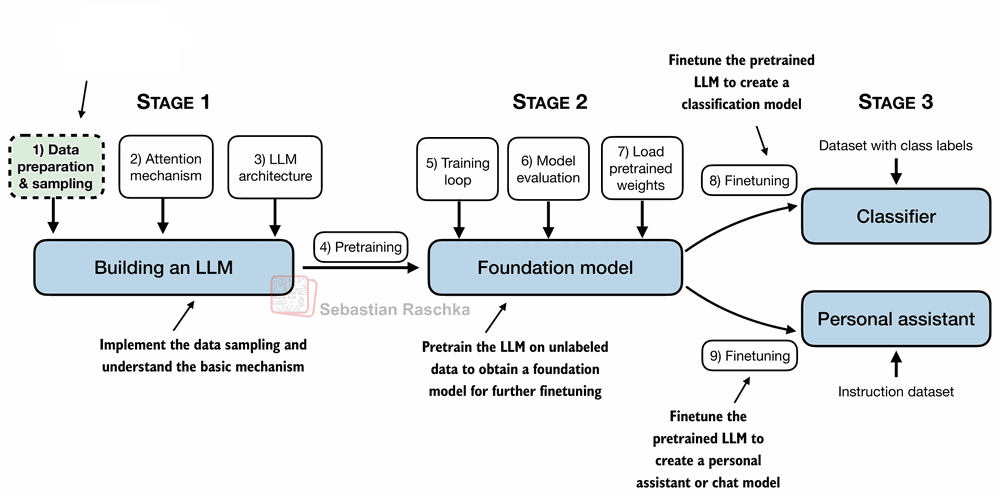

## 1.1 Entendendo word embeddings

- Não há código nesta seção

- Existem muitas formas de embeddings (representações vetoriais); neste notebook, focamos em embeddings de texto

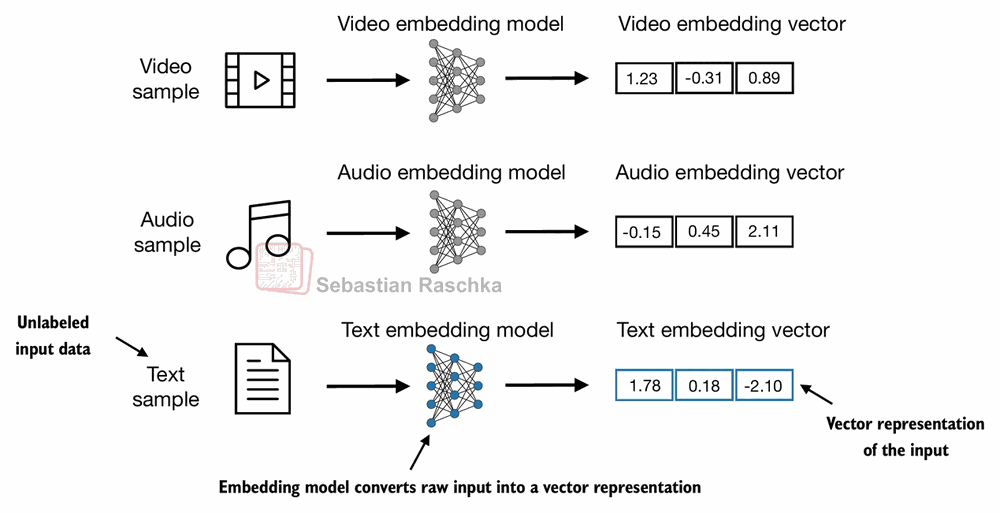

- LLMs trabalham com embeddings em espaços de alta dimensão (isto é, milhares de dimensões)
- Como não conseguimos visualizar espaços com tantas dimensões (nós, humanos, pensamos em 1, 2 ou 3 dimensões), a figura abaixo ilustra um espaço de embeddings bidimensional

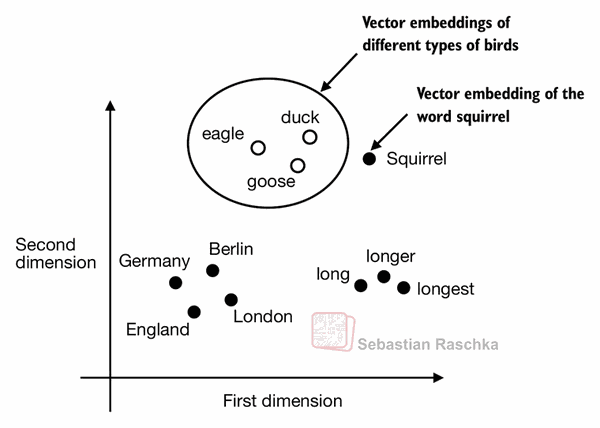

## 1.2 Tokenizando o texto

- Nesta seção, vamos tokenizar o texto, ou seja, quebrá-lo em unidades menores, como palavras individuais e caracteres de pontuação

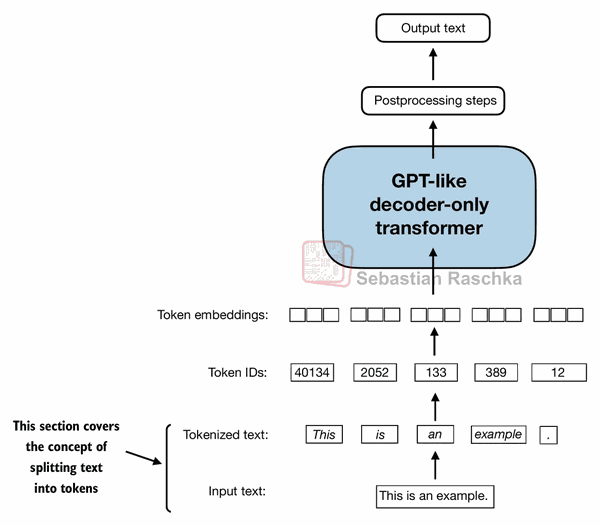

- Carregamos o texto bruto com o qual queremos trabalhar
- [The Verdict, de Edith Wharton](https://en.wikisource.org/wiki/The_Verdict), é um conto em domínio público

> 🇧🇷 **O que esta célula faz:** Carrega o conto de exemplo e mostra quantos caracteres ele tem, além do seu trecho inicial.

In [3]:
with open("dados/the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()
    
print("Total number of character:", len(raw_text))
print(raw_text[:99])

Total number of character: 20479
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


- O objetivo é tokenizar e gerar embeddings deste texto para um LLM
- Vamos desenvolver um tokenizer simples a partir de um pequeno texto de exemplo, que depois poderemos aplicar ao texto acima
- A expressão regular a seguir divide o texto nos espaços em branco

> 🇧🇷 **O que esta célula faz:** Divide uma frase de teste nos espaços em branco; a pontuação ainda fica grudada nas palavras.

In [4]:
import re

text = "Hello, world. This, is a test."
result = re.split(r'(\s)', text)

print(result)

['Hello,', ' ', 'world.', ' ', 'This,', ' ', 'is', ' ', 'a', ' ', 'test.']


- Não queremos dividir apenas nos espaços em branco, mas também nas vírgulas e nos pontos; então vamos modificar a expressão regular para fazer isso também

> 🇧🇷 **O que esta célula faz:** Divide a frase também em vírgulas e pontos; a saída ainda contém espaços e strings vazias.

In [5]:
result = re.split(r'([,.]|\s)', text)

print(result)

['Hello', ',', '', ' ', 'world', '.', '', ' ', 'This', ',', '', ' ', 'is', ' ', 'a', ' ', 'test', '.', '']


> 🇧🇷 **O que esta célula faz:** Remove os espaços e as strings vazias, deixando apenas palavras e pontuação.

In [6]:
# Strip whitespace from each item and then filter out any empty strings.
result = [item for item in result if item.strip()]
print(result)

['Hello', ',', 'world', '.', 'This', ',', 'is', 'a', 'test', '.']


- Como podemos ver, isso gera strings vazias; vamos removê-las

- Isso já está muito bom, mas vamos também tratar outros tipos de pontuação, como pontos, pontos de interrogação e assim por diante

> 🇧🇷 **O que esta célula faz:** Aplica uma divisão mais completa, que reconhece vários sinais de pontuação, e mostra os tokens resultantes.

In [7]:
text = "Hello, world. Is this-- a test?"

result = re.split(r'([,.:;?_!"()\']|--|\s)', text)
result = [item.strip() for item in result if item.strip()]
print(result)

['Hello', ',', 'world', '.', 'Is', 'this', '--', 'a', 'test', '?']


- Isso está muito bom, e agora estamos prontos para aplicar essa tokenização ao texto bruto

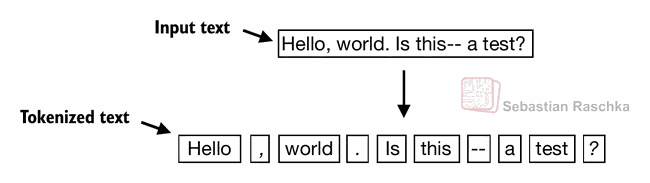

> 🇧🇷 **O que esta célula faz:** Tokeniza o conto inteiro e mostra os 30 primeiros tokens obtidos.

In [8]:
preprocessed = re.split(r'([,.?_!"()\']|--|\s)', raw_text)
preprocessed = [item.strip() for item in preprocessed if item.strip()]
print(preprocessed[:30])

['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow', 'enough', '--', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',', 'in']


- Vamos calcular o número total de tokens

> 🇧🇷 **O que esta célula faz:** Mostra o número total de tokens do texto.

In [9]:
print(len(preprocessed))

4649


## 1.3 Convertendo tokens em token IDs

- Em seguida, convertemos os tokens de texto em token IDs (identificadores numéricos), que depois poderemos processar por meio de camadas de embedding

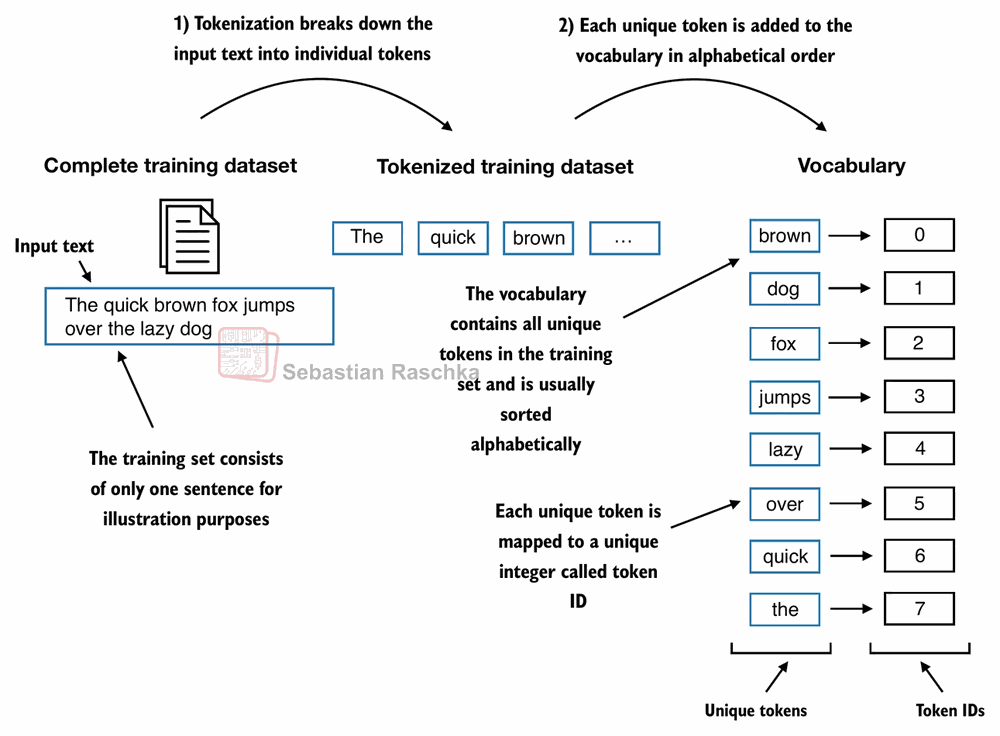

- A partir desses tokens, podemos agora construir um vocabulário formado por todos os tokens únicos

> 🇧🇷 **O que esta célula faz:** Reúne os tokens únicos em ordem alfabética e mostra o tamanho do vocabulário.

In [10]:
all_words = sorted(list(set(preprocessed)))
vocab_size = len(all_words)

print(vocab_size)

1159


> 🇧🇷 **O que esta célula faz:** Cria o vocabulário, associando cada token a um número inteiro.

In [11]:
vocab = {token:integer for integer,token in enumerate(all_words)}

- Abaixo estão as primeiras 50 entradas deste vocabulário:

> 🇧🇷 **O que esta célula faz:** Mostra as primeiras entradas do vocabulário: cada token com seu ID.

In [12]:
for i, item in enumerate(vocab.items()):
    print(item)
    if i >= 50:
        break

('!', 0)
('"', 1)
("'", 2)
('(', 3)
(')', 4)
(',', 5)
('--', 6)
('.', 7)
(':', 8)
(';', 9)
('?', 10)
('A', 11)
('Ah', 12)
('Among', 13)
('And', 14)
('Are', 15)
('Arrt', 16)
('As', 17)
('At', 18)
('Be', 19)
('Begin', 20)
('Burlington', 21)
('But', 22)
('By', 23)
('Carlo', 24)
('Carlo;', 25)
('Chicago', 26)
('Claude', 27)
('Come', 28)
('Croft', 29)
('Destroyed', 30)
('Devonshire', 31)
('Don', 32)
('Dubarry', 33)
('Emperors', 34)
('Florence', 35)
('For', 36)
('Gallery', 37)
('Gideon', 38)
('Gisburn', 39)
('Gisburns', 40)
('Grafton', 41)
('Greek', 42)
('Grindle', 43)
('Grindle:', 44)
('Grindles', 45)
('HAD', 46)
('Had', 47)
('Hang', 48)
('Has', 49)
('He', 50)


- A seguir, ilustramos a tokenização de um pequeno texto de exemplo usando um vocabulário reduzido:

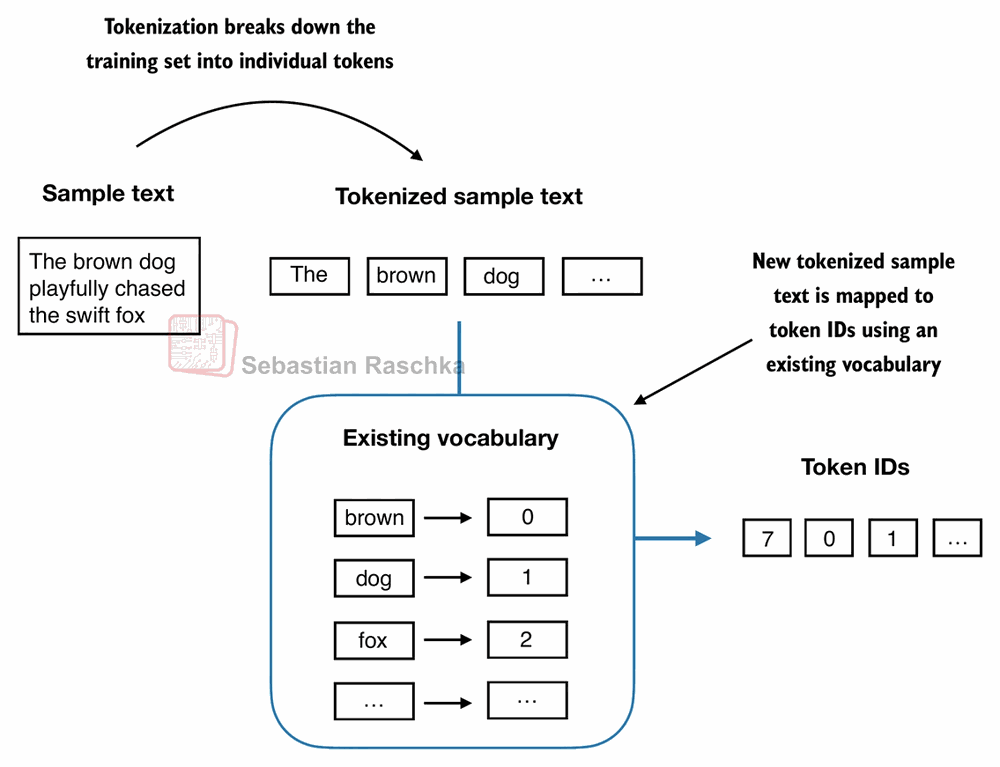

- Juntando tudo agora em uma classe de tokenizer

> 🇧🇷 **O que esta célula faz:** Define um tokenizer simples, capaz de converter texto em IDs e IDs de volta em texto.

In [13]:
class SimpleTokenizerV1:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {i:s for s,i in vocab.items()}
    
    def encode(self, text):
        preprocessed = re.split(r'([,.?_!"()\']|--|\s)', text)
        preprocessed = [item.strip() for item in preprocessed if item.strip()]
        ids = [self.str_to_int[s] for s in preprocessed]
        return ids
        
    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        # Replace spaces before the specified punctuations
        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
        return text

- A função `encode` transforma texto em token IDs
- A função `decode` transforma token IDs de volta em texto

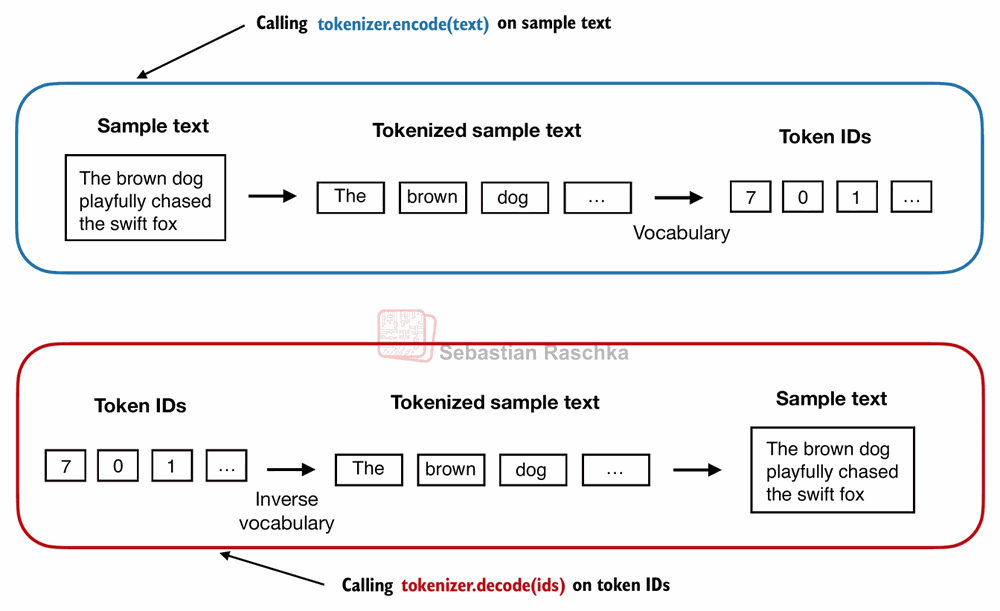

- Podemos usar o tokenizer para codificar (isto é, tokenizar) textos em números inteiros
- Esses inteiros poderão então (mais adiante) ser convertidos em embeddings e usados como entrada do LLM

> 🇧🇷 **O que esta célula faz:** Usa o tokenizer para converter uma frase do conto em uma lista de token IDs.

In [14]:
tokenizer = SimpleTokenizerV1(vocab)

text = """"It's the last he painted, you know," Mrs. Gisburn said with pardonable pride."""
ids = tokenizer.encode(text)
print(ids)

[1, 58, 2, 872, 1013, 615, 541, 763, 5, 1155, 608, 5, 1, 69, 7, 39, 873, 1136, 773, 812, 7]


- Podemos decodificar os inteiros de volta em texto

> 🇧🇷 **O que esta célula faz:** Converte os IDs de volta em texto, recuperando a frase original.

In [15]:
tokenizer.decode(ids)

'" It\' s the last he painted, you know," Mrs. Gisburn said with pardonable pride.'

> 🇧🇷 **O que esta célula faz:** Codifica e decodifica o texto em sequência, mostrando que o processo é reversível.

In [16]:
tokenizer.decode(tokenizer.encode(text))

'" It\' s the last he painted, you know," Mrs. Gisburn said with pardonable pride.'

## 1.4 Adicionando tokens especiais de contexto

- É útil adicionar alguns tokens "especiais" para palavras desconhecidas e para indicar o fim de um texto

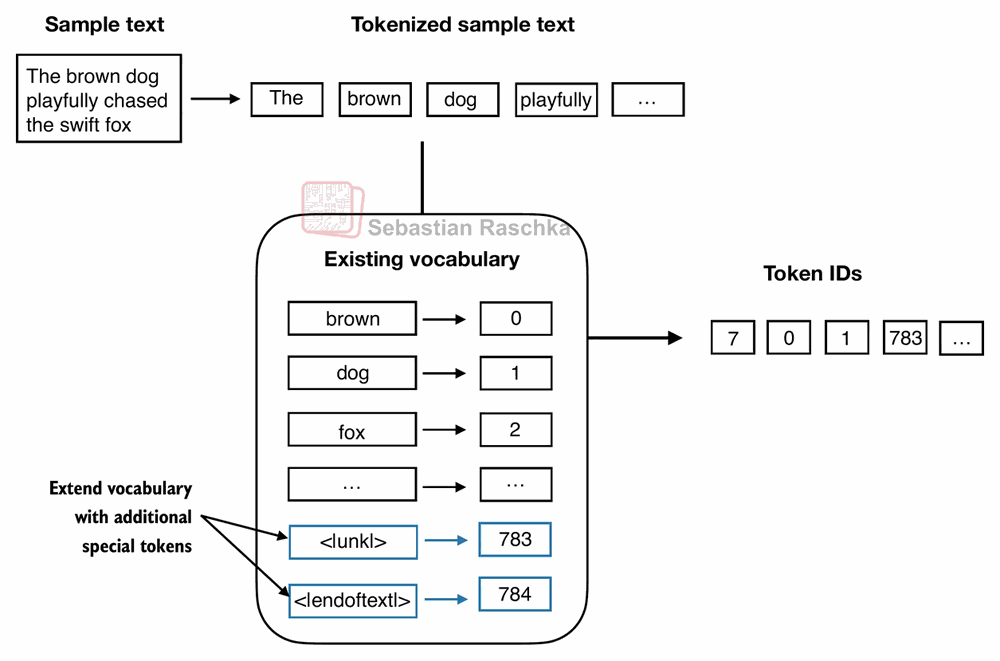

- Alguns tokenizers usam tokens especiais para fornecer contexto adicional ao LLM
- Alguns desses tokens especiais são
  - `[BOS]` (beginning of sequence, início da sequência) marca o início do texto
  - `[EOS]` (end of sequence, fim da sequência) marca onde o texto termina (geralmente é usado para concatenar vários textos não relacionados, por exemplo, dois artigos diferentes da Wikipédia, dois livros diferentes e assim por diante)
  - `[PAD]` (padding, preenchimento) se treinarmos LLMs com um batch size (tamanho de lote) maior que 1 (podemos incluir vários textos de comprimentos diferentes; com o token de padding, completamos os textos mais curtos até o comprimento do mais longo, para que todos tenham o mesmo tamanho)
- `[UNK]` para representar palavras que não estão incluídas no vocabulário

- Observe que o GPT-2 não precisa de nenhum dos tokens mencionados acima, usando apenas um token `<|endoftext|>` para reduzir a complexidade
- O `<|endoftext|>` é análogo ao token `[EOS]` mencionado acima
- O GPT também usa o `<|endoftext|>` para padding (como normalmente usamos uma máscara ao treinar com entradas em batches, os tokens de preenchimento não recebem atenção de qualquer forma, então não importa quais tokens sejam esses)
- O GPT-2 não usa um token `<UNK>` para palavras fora do vocabulário; em vez disso, o GPT-2 usa um tokenizer de byte pair encoding (BPE), que quebra as palavras em unidades de subpalavras, que discutiremos em uma seção posterior



- Usamos os tokens `<|endoftext|>` entre duas fontes de texto independentes:

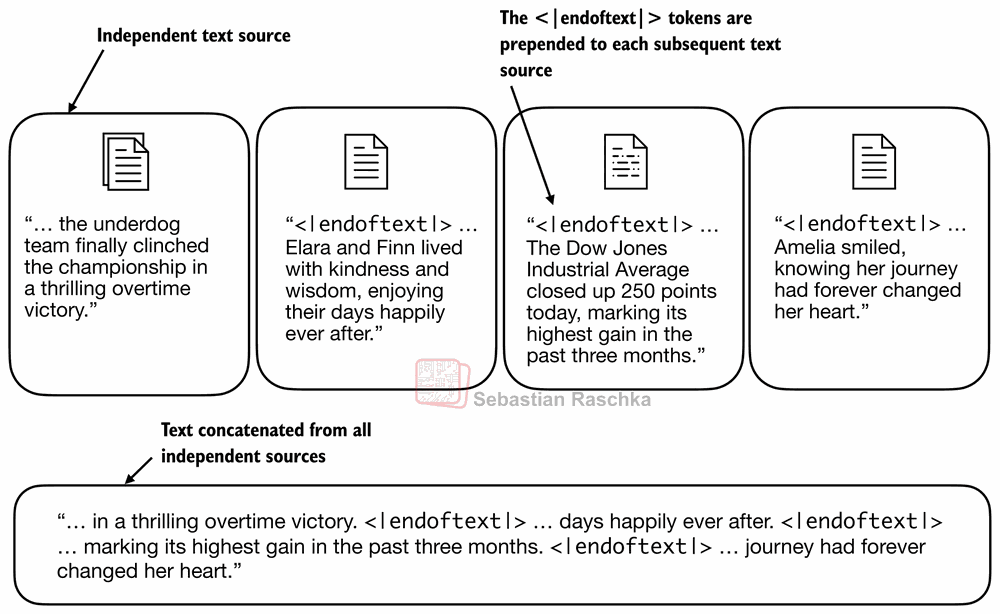

- Vejamos o que acontece se tokenizarmos o texto a seguir:

> 🇧🇷 **O que esta célula faz:** Tenta tokenizar uma frase com palavras fora do vocabulário, o que gera um erro.

In [17]:
tokenizer = SimpleTokenizerV1(vocab)

text = "Hello, do you like tea. Is this-- a test?"

tokenizer.encode(text)

KeyError: 'Hello'

- O código acima produz um erro porque a palavra "Hello" não está contida no vocabulário
- Para lidar com esses casos, podemos adicionar ao vocabulário tokens especiais como `"<|unk|>"`, para representar palavras desconhecidas
- Já que estamos ampliando o vocabulário, vamos adicionar outro token, chamado `"<|endoftext|>"`, que é usado no treinamento do GPT-2 para indicar o fim de um texto (e também é usado entre textos concatenados, por exemplo, quando nosso conjunto de dados de treinamento é formado por vários artigos, livros etc.)

> 🇧🇷 **O que esta célula faz:** Reconstrói o vocabulário acrescentando os tokens especiais de fim de texto e de palavra desconhecida.

In [18]:
preprocessed = re.split(r'([,.?_!"()\']|--|\s)', raw_text)
preprocessed = [item.strip() for item in preprocessed if item.strip()]

all_tokens = sorted(list(set(preprocessed)))
all_tokens.extend(["<|endoftext|>", "<|unk|>"])

vocab = {token:integer for integer,token in enumerate(all_tokens)}

> 🇧🇷 **O que esta célula faz:** Mostra o novo tamanho do vocabulário, agora com dois tokens a mais.

In [19]:
len(vocab.items())

1161

> 🇧🇷 **O que esta célula faz:** Mostra as últimas entradas do vocabulário, onde aparecem os dois tokens especiais.

In [20]:
for i, item in enumerate(list(vocab.items())[-5:]):
    print(item)

('younger', 1156)
('your', 1157)
('yourself', 1158)
('<|endoftext|>', 1159)
('<|unk|>', 1160)


- Também precisamos ajustar o tokenizer para que ele saiba quando e como usar o novo token `<unk>`

> 🇧🇷 **O que esta célula faz:** Define uma nova versão do tokenizer que substitui palavras desconhecidas por um token especial.

In [21]:
class SimpleTokenizerV2:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = { i:s for s,i in vocab.items()}
    
    def encode(self, text):
        preprocessed = re.split(r'([,.?_!"()\']|--|\s)', text)
        preprocessed = [item.strip() for item in preprocessed if item.strip()]
        preprocessed = [item if item in self.str_to_int 
                        else "<|unk|>" for item in preprocessed]

        ids = [self.str_to_int[s] for s in preprocessed]
        return ids
        
    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        # Replace spaces before the specified punctuations
        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
        return text

Vamos tentar tokenizar um texto com o tokenizer modificado:

> 🇧🇷 **O que esta célula faz:** Junta duas frases independentes, separadas pelo token de fim de texto, e mostra o resultado.

In [22]:
tokenizer = SimpleTokenizerV2(vocab)

text1 = "Hello, do you like tea?"
text2 = "In the sunlit terraces of the palace."

text = " <|endoftext|> ".join((text1, text2))

print(text)

Hello, do you like tea? <|endoftext|> In the sunlit terraces of the palace.


> 🇧🇷 **O que esta célula faz:** Converte o texto combinado em token IDs; palavras desconhecidas recebem o ID do token especial.

In [23]:
tokenizer.encode(text)

[1160,
 5,
 362,
 1155,
 642,
 1000,
 10,
 1159,
 57,
 1013,
 981,
 1009,
 738,
 1013,
 1160,
 7]

> 🇧🇷 **O que esta célula faz:** Decodifica os IDs de volta em texto: as palavras desconhecidas aparecem como o token especial.

In [24]:
tokenizer.decode(tokenizer.encode(text))

'<|unk|>, do you like tea? <|endoftext|> In the sunlit terraces of the <|unk|>.'

## 1.5 Byte pair encoding

- O GPT-2 usou o byte pair encoding (BPE, codificação por pares de bytes) como tokenizer
- Ele permite que o modelo quebre palavras que não estão em seu vocabulário predefinido em unidades menores de subpalavras ou até em caracteres individuais, o que lhe permite lidar com palavras fora do vocabulário
- Por exemplo, se o vocabulário do GPT-2 não tiver a palavra "unfamiliarword", ele pode tokenizá-la como ["unfam", "iliar", "word"] ou alguma outra divisão em subpalavras, dependendo das fusões (merges) de BPE aprendidas no treinamento
- O tokenizer BPE original pode ser encontrado aqui: [https://github.com/openai/gpt-2/blob/master/src/encoder.py](https://github.com/openai/gpt-2/blob/master/src/encoder.py)
- Nesta parte, usamos o tokenizer BPE da biblioteca de código aberto [tiktoken](https://github.com/openai/tiktoken), da OpenAI, que implementa seus algoritmos principais em Rust para melhorar o desempenho computacional
- Criei um notebook em [./bytepair_encoder](../02_bonus_bytepair-encoder) que compara essas duas implementações lado a lado (o tiktoken foi cerca de 5x mais rápido no texto de exemplo)

> 🇧🇷 **O que esta célula faz:** Comentário lembrando como instalar o tiktoken; não executa nada.

In [25]:
# pip install tiktoken

> 🇧🇷 **O que esta célula faz:** Importa o tiktoken e mostra a versão instalada.

In [26]:
import importlib
import tiktoken

print("tiktoken version:", importlib.metadata.version("tiktoken"))

tiktoken version: 0.7.0


> 🇧🇷 **O que esta célula faz:** Carrega o tokenizer BPE usado pelo GPT-2.

In [27]:
tokenizer = tiktoken.get_encoding("gpt2")

> 🇧🇷 **O que esta célula faz:** Codifica um texto com o tokenizer BPE; até uma palavra inventada é convertida em IDs, sem erro.

In [28]:
text = "Hello, do you like tea? <|endoftext|> In the sunlit terraces of someunknownPlace."

integers = tokenizer.encode(text, allowed_special={"<|endoftext|>"})

print(integers)

[15496, 11, 466, 345, 588, 8887, 30, 220, 50256, 554, 262, 4252, 18250, 8812, 2114, 286, 617, 34680, 27271, 13]


> 🇧🇷 **O que esta célula faz:** Decodifica os IDs e recupera exatamente o texto original.

In [29]:
strings = tokenizer.decode(integers)

print(strings)

Hello, do you like tea? <|endoftext|> In the sunlit terraces of someunknownPlace.


- Tokenizers BPE quebram palavras desconhecidas em subpalavras e caracteres individuais:

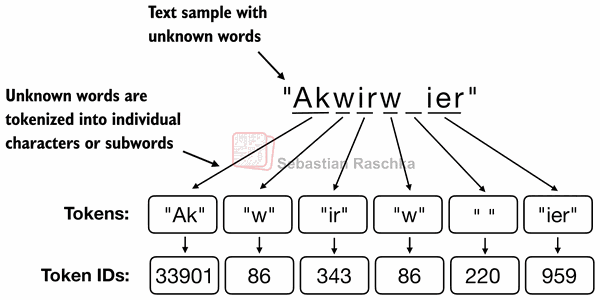

## 1.6 Amostragem de dados com janela deslizante

- Treinamos LLMs para gerar uma palavra por vez; por isso, queremos preparar os dados de treinamento de modo que a próxima palavra de uma sequência represente o alvo a ser previsto:

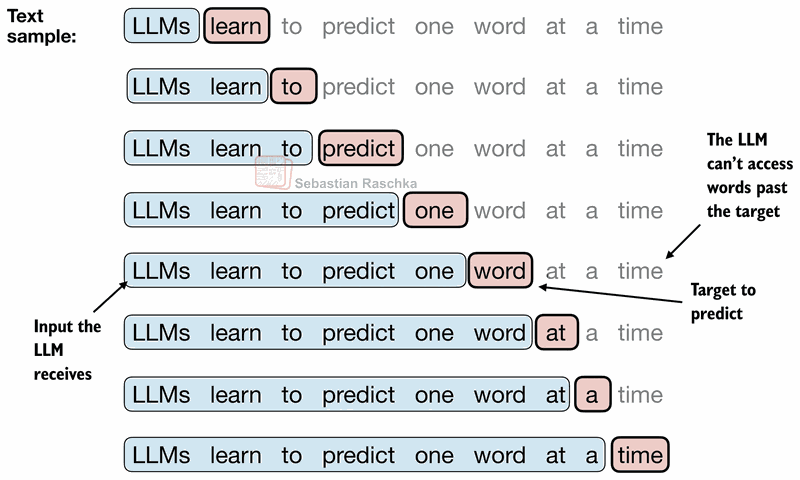

> 🇧🇷 **O que esta célula faz:** Tokeniza o conto inteiro com o BPE e mostra quantos tokens ele gera.

In [30]:
with open("dados/the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

enc_text = tokenizer.encode(raw_text)
print(len(enc_text))

5145


- Para cada trecho de texto, queremos as entradas e os alvos
- Como queremos que o modelo preveja a próxima palavra, os alvos são as entradas deslocadas uma posição para a direita

> 🇧🇷 **O que esta célula faz:** Separa uma amostra do texto tokenizado, a partir da posição 50.

In [31]:
enc_sample = enc_text[50:]

> 🇧🇷 **O que esta célula faz:** Monta um par de entrada e alvo, em que o alvo é a entrada deslocada uma posição.

In [32]:
context_size = 4

x = enc_sample[:context_size]
y = enc_sample[1:context_size+1]

print(f"x: {x}")
print(f"y:      {y}")

x: [290, 4920, 2241, 287]
y:      [4920, 2241, 287, 257]


- Passo a passo, a previsão ficaria assim:

> 🇧🇷 **O que esta célula faz:** Mostra, passo a passo, qual token o modelo deve prever a partir de cada contexto.

In [33]:
for i in range(1, context_size+1):
    context = enc_sample[:i]
    desired = enc_sample[i]

    print(context, "---->", desired)

[290] ----> 4920
[290, 4920] ----> 2241
[290, 4920, 2241] ----> 287
[290, 4920, 2241, 287] ----> 257


> 🇧🇷 **O que esta célula faz:** Repete a demonstração anterior, agora mostrando os tokens como texto legível.

In [34]:
for i in range(1, context_size+1):
    context = enc_sample[:i]
    desired = enc_sample[i]

    print(tokenizer.decode(context), "---->", tokenizer.decode([desired]))

 and ---->  established
 and established ---->  himself
 and established himself ---->  in
 and established himself in ---->  a


- Cuidaremos da previsão da próxima palavra em uma parte posterior, depois de estudarmos o mecanismo de atenção
- Por enquanto, implementamos um data loader simples, que percorre o conjunto de dados de entrada e retorna as entradas e os alvos deslocados em uma posição

- Instale e importe o PyTorch (veja o Apêndice A para dicas de instalação)

> 🇧🇷 **O que esta célula faz:** Importa o PyTorch e mostra sua versão.

In [35]:
import torch
print("PyTorch version:", torch.__version__)

PyTorch version: 2.3.1+cu121


- Usamos uma abordagem de janela deslizante, avançando a posição em +1:

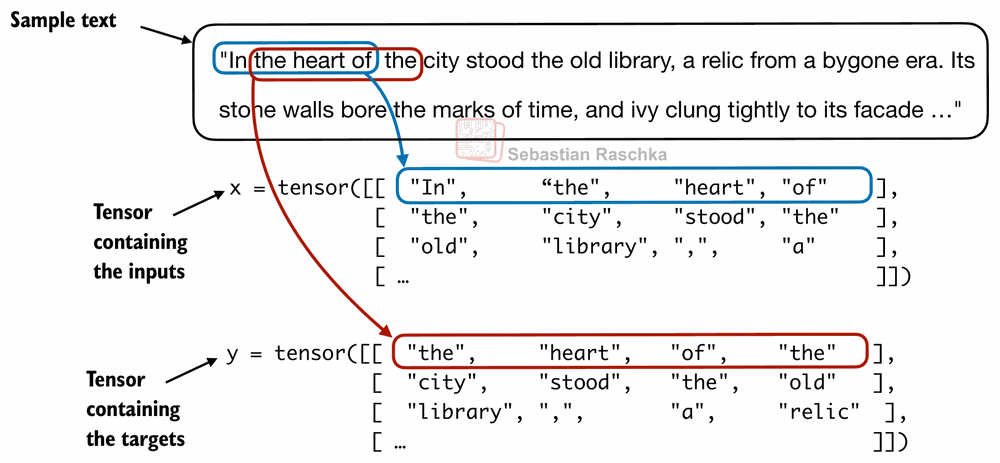

- Criamos um dataset e um dataloader que extraem trechos do conjunto de dados de texto de entrada

> 🇧🇷 **O que esta célula faz:** Define um dataset que percorre o texto com uma janela deslizante, gerando pares de entrada e alvo.

In [36]:
from torch.utils.data import Dataset, DataLoader


class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        # Tokenize the entire text
        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

        # Use a sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

> 🇧🇷 **O que esta célula faz:** Define uma função que cria um dataloader a partir do texto, com tamanho de batch, contexto e stride configuráveis.

In [37]:
def create_dataloader_v1(txt, batch_size=4, max_length=256, stride=128, shuffle=True, drop_last=True, num_workers=0):

    # Initialize the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Create dataloader
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=0
    )

    return dataloader

- Vamos testar o dataloader com um batch size de 1 para um LLM com tamanho de contexto 4:

> 🇧🇷 **O que esta célula faz:** Carrega novamente o texto do conto.

In [38]:
with open("dados/the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

> 🇧🇷 **O que esta célula faz:** Cria um dataloader com contexto 4 e stride 1 e mostra o primeiro batch: entradas e alvos.

In [39]:
dataloader = create_dataloader_v1(raw_text, batch_size=1, max_length=4, stride=1, shuffle=False)

data_iter = iter(dataloader)
first_batch = next(data_iter)
print(first_batch)

[tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]


> 🇧🇷 **O que esta célula faz:** Mostra o segundo batch: a janela avançou uma posição.

In [40]:
second_batch = next(data_iter)
print(second_batch)

[tensor([[ 367, 2885, 1464, 1807]]), tensor([[2885, 1464, 1807, 3619]])]


- Um exemplo usando stride (passo) igual ao comprimento do contexto (aqui: 4) é mostrado abaixo:

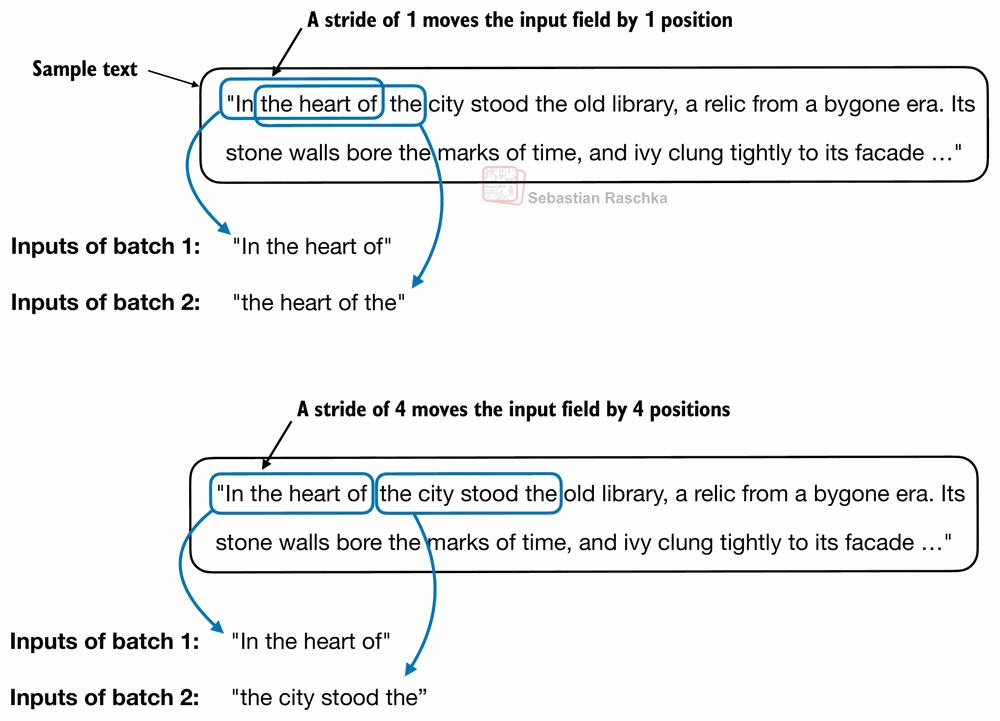

- Também podemos criar saídas em batches
- Observe que aqui aumentamos o stride para que não haja sobreposição entre os batches, já que mais sobreposição poderia levar a um overfitting (sobreajuste) maior

> 🇧🇷 **O que esta célula faz:** Cria batches de 8 exemplos sem sobreposição e mostra as entradas e os alvos correspondentes.

In [41]:
dataloader = create_dataloader_v1(raw_text, batch_size=8, max_length=4, stride=4, shuffle=False)

data_iter = iter(dataloader)
inputs, targets = next(data_iter)
print("Inputs:\n", inputs)
print("\nTargets:\n", targets)

Inputs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Targets:
 tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])


## 1.7 Criando embeddings de tokens

- Os dados já estão quase prontos para um LLM
- Mas, por último, vamos converter os tokens em uma representação vetorial contínua usando uma camada de embedding
- Normalmente, essas camadas de embedding fazem parte do próprio LLM e são atualizadas (treinadas) durante o treinamento do modelo

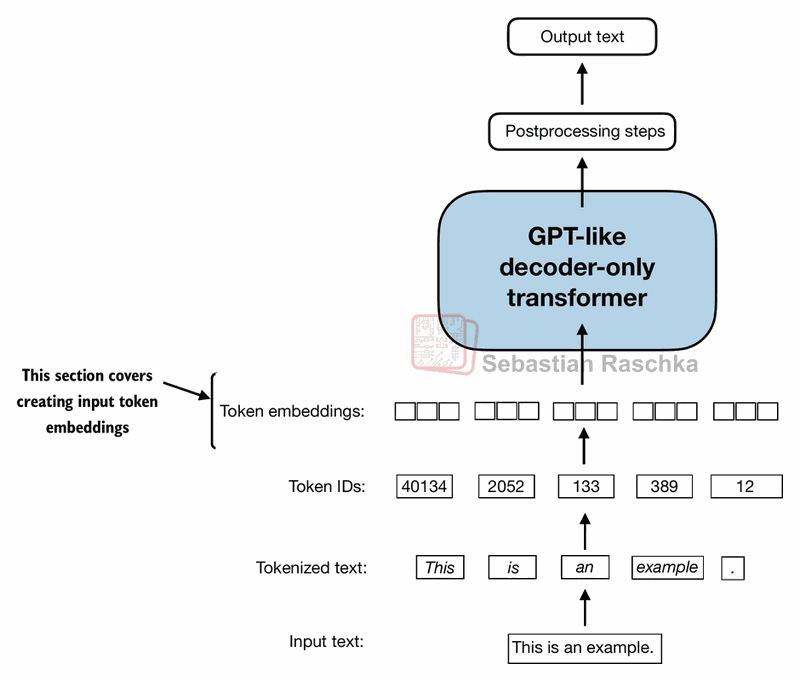

- Suponha que temos os quatro exemplos de entrada a seguir, com IDs de entrada 5, 1, 3 e 2 (após a tokenização):

> 🇧🇷 **O que esta célula faz:** Define quatro token IDs de exemplo.

In [42]:
input_ids = torch.tensor([2, 3, 5, 1])

- Para simplificar, suponha que temos um vocabulário pequeno, com apenas 6 palavras, e queremos criar embeddings de tamanho 3:

> 🇧🇷 **O que esta célula faz:** Cria uma camada de embedding para um vocabulário de 6 tokens, com vetores de 3 dimensões.

In [43]:
vocab_size = 6
output_dim = 3

torch.manual_seed(123)
embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

- Isso resultaria em uma matriz de pesos de 6x3:

> 🇧🇷 **O que esta célula faz:** Mostra a matriz de pesos da camada de embedding, inicializada aleatoriamente.

In [44]:
print(embedding_layer.weight)

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


- Para quem conhece one-hot encoding, a abordagem da camada de embedding acima é basicamente apenas uma forma mais eficiente de implementar one-hot encoding seguido de uma multiplicação de matrizes em uma camada totalmente conectada, como descrito no código complementar em [./embedding_vs_matmul](../03_bonus_embedding-vs-matmul)
- Como a camada de embedding é apenas uma implementação mais eficiente, equivalente à abordagem de one-hot encoding com multiplicação de matrizes, ela pode ser vista como uma camada de rede neural que pode ser otimizada via backpropagation (retropropagação)

- Para converter um token com ID 3 em um vetor de 3 dimensões, fazemos o seguinte:

> 🇧🇷 **O que esta célula faz:** Obtém o vetor de embedding do token de ID 3, que é uma linha da matriz de pesos.

In [45]:
print(embedding_layer(torch.tensor([3])))

tensor([[-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)


- Observe que o resultado acima é a 4ª linha da matriz de pesos da `embedding_layer`
- Para gerar os embeddings dos quatro valores de `input_ids` acima, fazemos

> 🇧🇷 **O que esta célula faz:** Obtém os vetores de embedding dos quatro IDs de exemplo de uma só vez.

In [46]:
print(embedding_layer(input_ids))

tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)


- Uma camada de embedding é, essencialmente, uma operação de consulta (look-up):

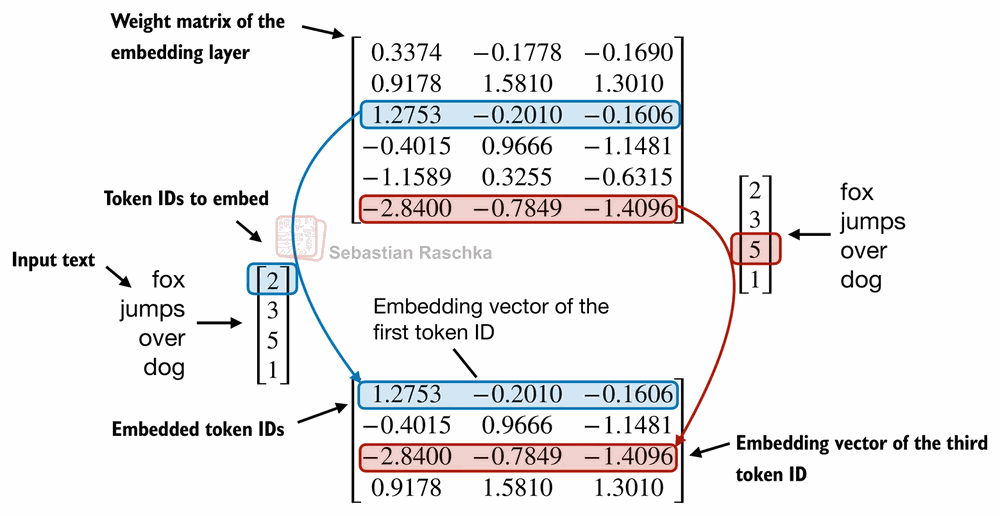

- **Talvez você se interesse pelo conteúdo bônus que compara camadas de embedding com camadas lineares comuns: [../03_bonus_embedding-vs-matmul](../03_bonus_embedding-vs-matmul)**

## 1.8 Codificando as posições das palavras

- A camada de embedding converte IDs em representações vetoriais idênticas, independentemente de onde eles estejam na sequência de entrada:

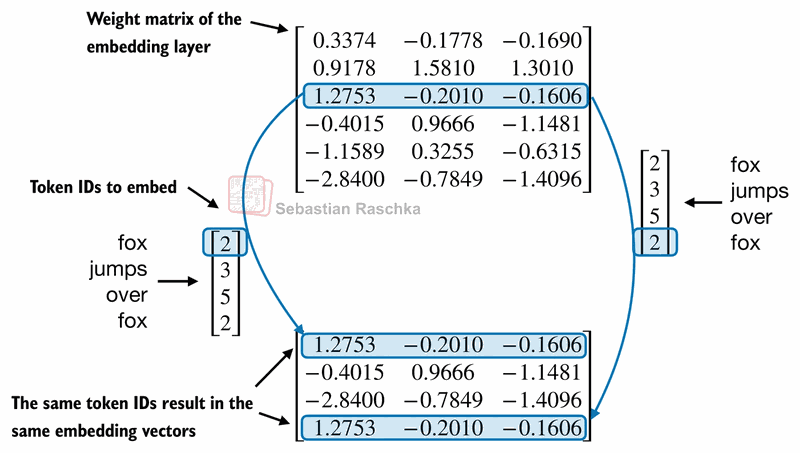

- Os embeddings de posição são combinados com o vetor de embedding do token para formar os embeddings de entrada de um modelo de linguagem de grande porte:

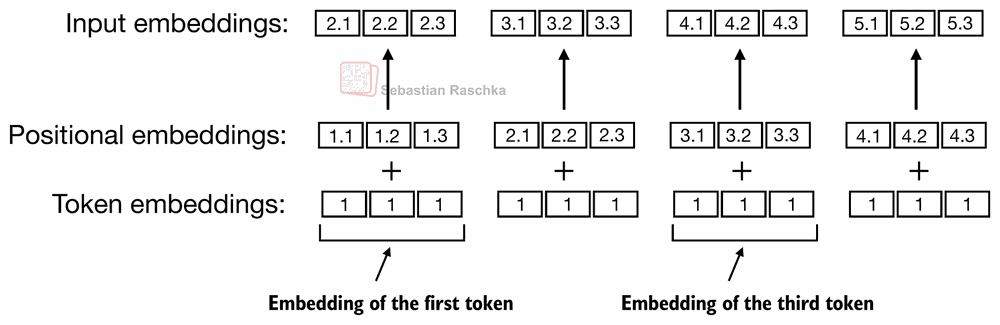

- O codificador BytePair tem um vocabulário de 50.257 tokens:
- Suponha que queremos codificar os tokens de entrada em uma representação vetorial de 256 dimensões:

> 🇧🇷 **O que esta célula faz:** Cria a camada de embedding de tokens com o vocabulário do GPT-2 e vetores de 256 dimensões.

In [47]:
vocab_size = 50257
output_dim = 256

token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

- Se amostrarmos dados do dataloader, convertemos os tokens de cada batch em vetores de 256 dimensões
- Se tivermos um batch size de 8, com 4 tokens cada, isso resulta em um tensor de 8 x 4 x 256:

> 🇧🇷 **O que esta célula faz:** Cria um dataloader com batches de 8 sequências de 4 tokens e extrai o primeiro batch.

In [48]:
max_length = 4
dataloader = create_dataloader_v1(raw_text, batch_size=8, max_length=max_length, stride=max_length, shuffle=False)
data_iter = iter(dataloader)
inputs, targets = next(data_iter)

> 🇧🇷 **O que esta célula faz:** Mostra os token IDs do batch e o formato do tensor de entrada.

In [49]:
print("Token IDs:\n", inputs)
print("\nInputs shape:\n", inputs.shape)

Token IDs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Inputs shape:
 torch.Size([8, 4])


> 🇧🇷 **O que esta célula faz:** Converte os IDs do batch em embeddings e mostra o formato resultante: 8 x 4 x 256.

In [50]:
token_embeddings = token_embedding_layer(inputs)
print(token_embeddings.shape)

torch.Size([8, 4, 256])


- O GPT-2 usa embeddings de posição absolutos, então basta criarmos outra camada de embedding:

> 🇧🇷 **O que esta célula faz:** Cria a camada de embeddings de posição, com uma posição para cada token do contexto.

In [51]:
context_length = max_length
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)

> 🇧🇷 **O que esta célula faz:** Gera os embeddings das 4 posições e mostra seu formato.

In [52]:
pos_embeddings = pos_embedding_layer(torch.arange(max_length))
print(pos_embeddings.shape)

torch.Size([4, 256])


- Para criar os embeddings de entrada usados em um LLM, simplesmente somamos os embeddings de token e os de posição:

> 🇧🇷 **O que esta célula faz:** Soma os embeddings de token e de posição, obtendo os embeddings de entrada do LLM.

In [53]:
input_embeddings = token_embeddings + pos_embeddings
print(input_embeddings.shape)

torch.Size([8, 4, 256])


- Na fase inicial do fluxo de processamento da entrada, o texto de entrada é segmentado em tokens separados
- Após essa segmentação, esses tokens são transformados em token IDs com base em um vocabulário predefinido:

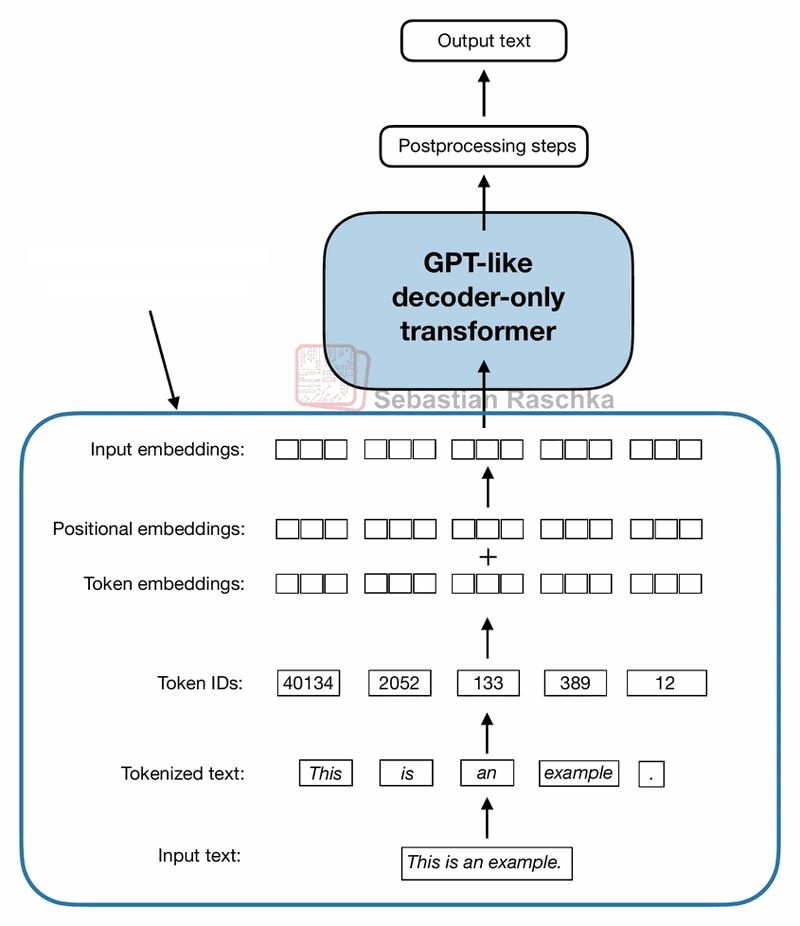

# Resumo e principais lições

**Veja o notebook [./dataloader.ipynb](./dataloader.ipynb)**, que é uma versão concisa do data loader que implementamos nesta parte e do qual vamos precisar para treinar o modelo GPT nas próximas partes.

**Veja [./exercise-solutions.ipynb](./exercise-solutions.ipynb) para as soluções dos exercícios.**

# Parte 2 — Implementando mecanismos de atenção

Nesta parte, construímos o **mecanismo de atenção**, o coração dos LLMs. Partimos de uma versão simples de self-attention (autoatenção), sem pesos treináveis, para entender a ideia de vetores de contexto. Em seguida, adicionamos as matrizes treináveis de query, key e value, aplicamos a máscara causal (para que o modelo não "veja o futuro") e o dropout e, por fim, combinamos várias cabeças em uma **multi-head attention**.

Na parte anterior, transformamos texto em embeddings; aqui, ensinamos o modelo a relacionar esses tokens entre si. O módulo `MultiHeadAttention` construído no final será uma peça central da arquitetura GPT que montaremos na próxima parte.

Pacotes usados neste notebook:

> 🇧🇷 **O que esta célula faz:** Mostra a versão do PyTorch instalada no ambiente.

In [54]:
from importlib.metadata import version

print("torch version:", version("torch"))

torch version: 2.3.1


- Esta parte trata dos mecanismos de atenção, o motor dos LLMs:

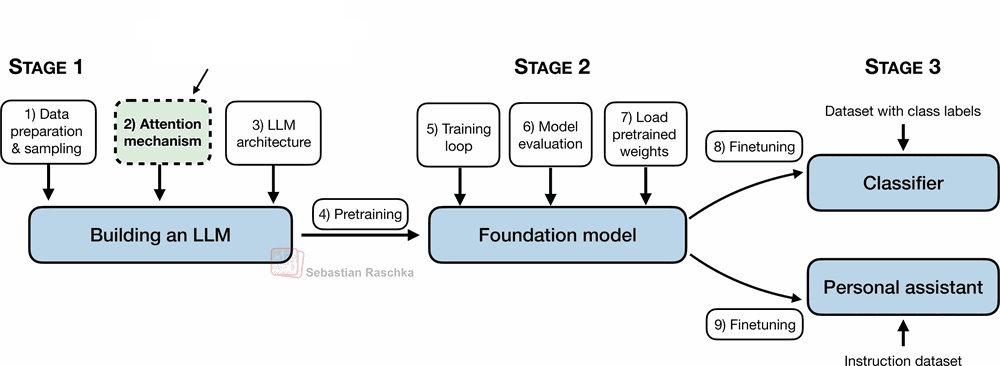

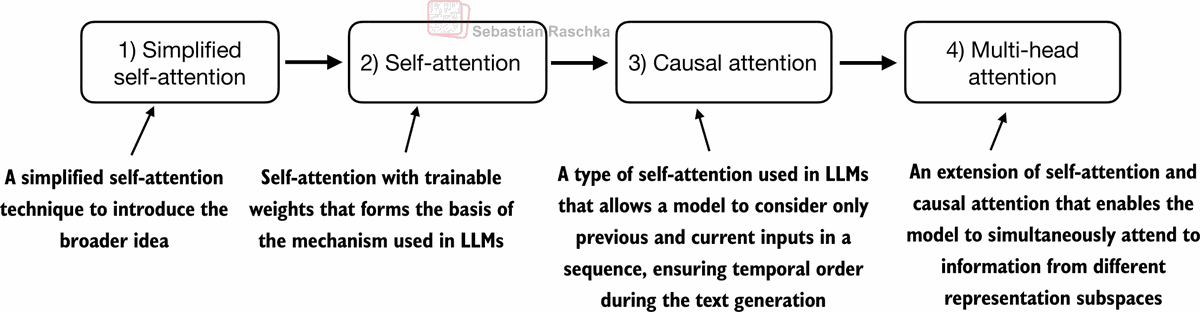

## 2.1 O problema de modelar sequências longas

- Não há código nesta seção
- Traduzir um texto palavra por palavra não é viável, por causa das diferenças entre as estruturas gramaticais do idioma de origem e do idioma de destino:

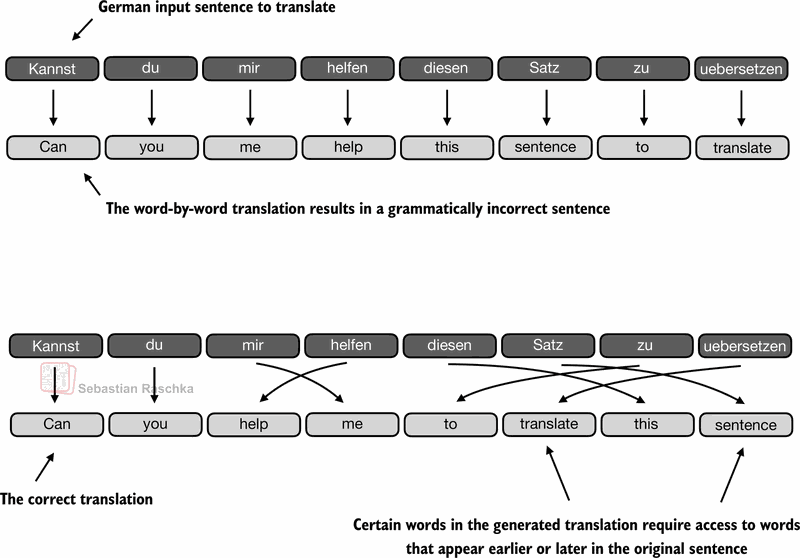

- Antes da introdução dos modelos transformer, RNNs (redes neurais recorrentes) do tipo encoder-decoder eram muito usadas em tarefas de tradução automática
- Nessa configuração, o encoder processa uma sequência de tokens do idioma de origem, usando um estado oculto (hidden state) — uma espécie de camada intermediária dentro da rede neural — para gerar uma representação condensada de toda a sequência de entrada:

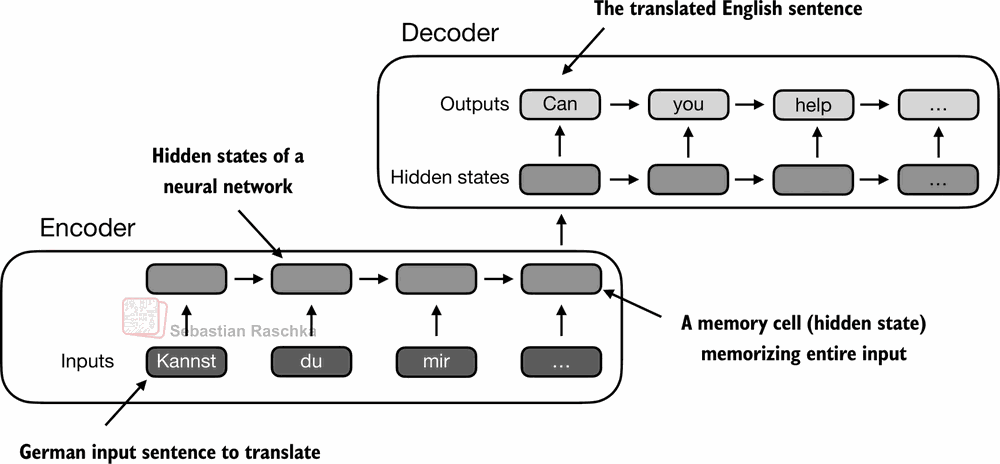

## 2.2 Capturando dependências nos dados com mecanismos de atenção

- Não há código nesta seção
- Por meio de um mecanismo de atenção, a parte decoder da rede, que gera o texto, consegue acessar seletivamente todos os tokens de entrada, o que significa que alguns tokens de entrada têm mais importância do que outros na geração de um determinado token de saída:

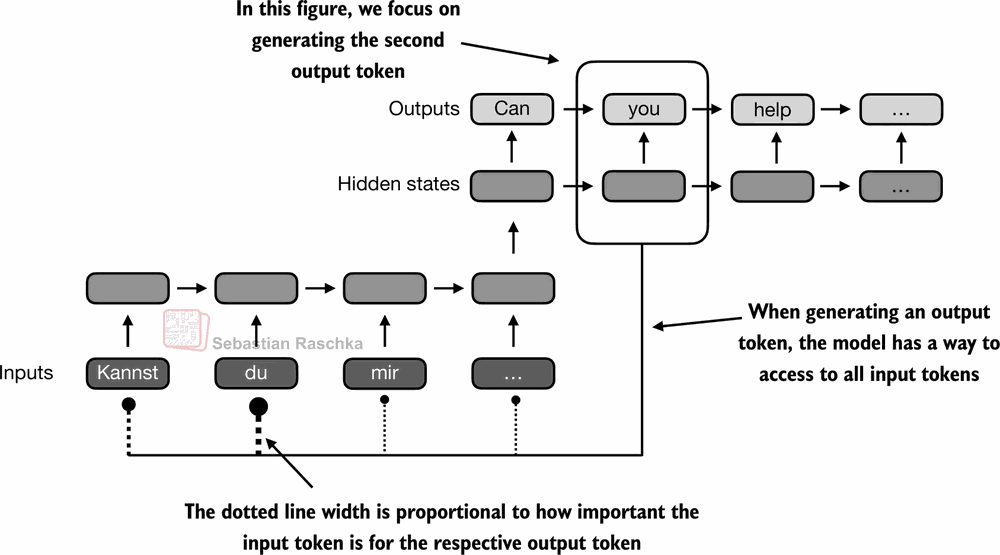

- A self-attention (autoatenção) nos transformers é uma técnica criada para enriquecer as representações da entrada, permitindo que cada posição de uma sequência interaja com todas as outras posições da mesma sequência e determine a relevância de cada uma delas

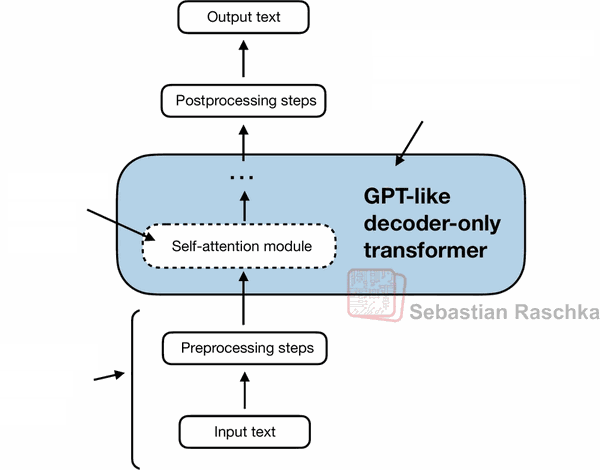

## 2.3 Prestando atenção a diferentes partes da entrada com self-attention

### 2.3.1 Um mecanismo simples de self-attention sem pesos treináveis

- Esta seção explica uma variante bem simplificada de self-attention, que não contém nenhum peso treinável
- Ela serve apenas para ilustração e NÃO é o mecanismo de atenção usado nos transformers
- A próxima seção, 3.3.2, vai estender esse mecanismo de atenção simples para implementar o mecanismo de self-attention de verdade
- Suponha que recebemos uma sequência de entrada de $x^{(1)}$ a $x^{(T)}$
  - A entrada é um texto (por exemplo, uma frase como "Your journey starts with one step", isto é, "Sua jornada começa com um passo") que já foi convertido em token embeddings (vetores que representam os tokens), como descrito na parte 1
  - Por exemplo, $x^{(1)}$ é um vetor de dimensão d que representa a palavra "Your", e assim por diante
- **Objetivo:** calcular context vectors (vetores de contexto) $z^{(i)}$ para cada elemento $x^{(i)}$ da sequência de entrada $x^{(1)}$ a $x^{(T)}$ (onde $z$ e $x$ têm a mesma dimensão)
    - Um context vector $z^{(i)}$ é uma soma ponderada das entradas $x^{(1)}$ a $x^{(T)}$
    - O context vector é específico do "contexto" de uma determinada entrada
      - Em vez de usar $x^{(i)}$ como representante de um token de entrada qualquer, vamos considerar a segunda entrada, $x^{(2)}$
      - E, para continuar com um exemplo concreto, em vez do genérico $z^{(i)}$, consideramos o segundo context vector de saída, $z^{(2)}$
      - O segundo context vector, $z^{(2)}$, é uma soma ponderada de todas as entradas $x^{(1)}$ a $x^{(T)}$, com pesos definidos em relação ao segundo elemento de entrada, $x^{(2)}$
      - Os pesos de atenção (attention weights) são os pesos que determinam quanto cada elemento de entrada contribui para a soma ponderada ao calcular $z^{(2)}$
      - Em resumo, pense em $z^{(2)}$ como uma versão modificada de $x^{(2)}$ que também incorpora informações sobre todos os outros elementos de entrada relevantes para a tarefa em questão

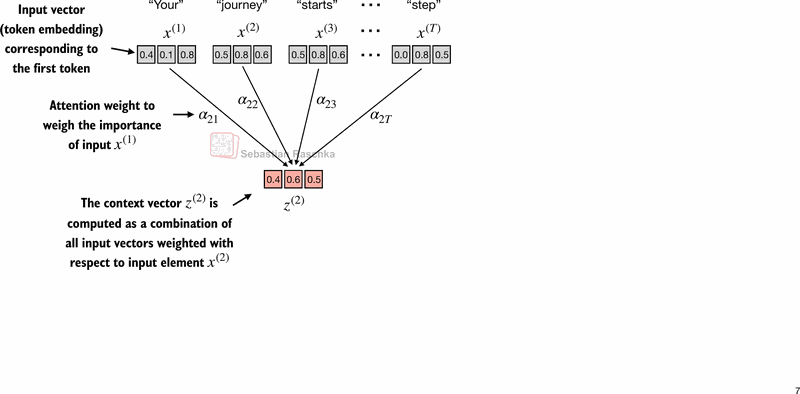

- Por convenção, os pesos de atenção não normalizados são chamados de **"attention scores"** (pontuações de atenção), enquanto as pontuações de atenção normalizadas, que somam 1, são chamadas de **"attention weights"** (pesos de atenção)


- O código abaixo percorre a figura acima passo a passo

<br>

- **Passo 1:** calcular as pontuações de atenção não normalizadas $\omega$
- Suponha que usamos o segundo token de entrada como query (consulta), ou seja, $q^{(2)} = x^{(2)}$; calculamos as pontuações de atenção não normalizadas por meio de produtos escalares (dot products):
    - $\omega_{21} = x^{(1)} q^{(2)\top}$
    - $\omega_{22} = x^{(2)} q^{(2)\top}$
    - $\omega_{23} = x^{(3)} q^{(2)\top}$
    - ...
    - $\omega_{2T} = x^{(T)} q^{(2)\top}$
- Acima, $\omega$ é a letra grega "ômega", usada para simbolizar as pontuações de atenção não normalizadas
    - O índice "21" em $\omega_{21}$ significa que o elemento 2 da sequência de entrada foi usado como query em relação ao elemento 1 da sequência de entrada

- Suponha que temos a seguinte frase de entrada, que já foi convertida em embeddings de 3 dimensões, como descrito na parte 1 (usamos aqui uma dimensão de embedding bem pequena para fins de ilustração, para que caiba na página sem quebras de linha):

> 🇧🇷 **O que esta célula faz:** Cria um pequeno tensor com a frase de exemplo: seis tokens, cada um representado por um embedding de 3 dimensões.

In [55]:
import torch

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

- O objetivo principal desta seção é demonstrar como o context vector $z^{(2)}$
  é calculado usando a segunda entrada da sequência, $x^{(2)}$, como query

- A figura mostra o passo inicial desse processo, que consiste em calcular as pontuações de atenção ω entre $x^{(2)}$
  e todos os outros elementos de entrada por meio de uma operação de produto escalar.

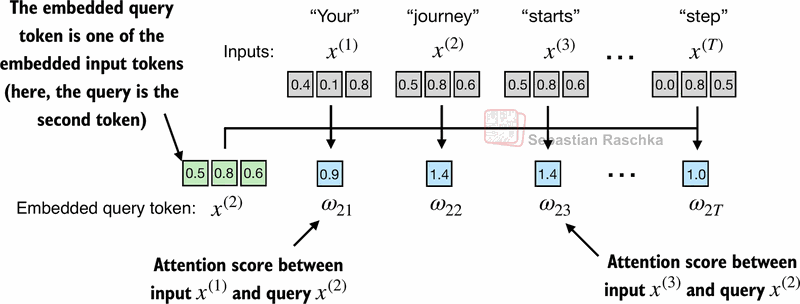

- Usamos o elemento 2 da sequência de entrada, $x^{(2)}$, como exemplo para calcular o context vector $z^{(2)}$; mais adiante nesta seção, vamos generalizar isso para calcular todos os context vectors.
- O primeiro passo é calcular as pontuações de atenção não normalizadas, fazendo o produto escalar entre a query $x^{(2)}$ e todos os outros tokens de entrada:

> 🇧🇷 **O que esta célula faz:** Usa o segundo token como query e calcula sua pontuação de atenção em relação a cada um dos seis tokens por meio de produtos escalares.

In [56]:
query = inputs[1]  # 2nd input token is the query

attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    attn_scores_2[i] = torch.dot(x_i, query) # dot product (transpose not necessary here since they are 1-dim vectors)

print(attn_scores_2)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


- Observação: um produto escalar é basicamente uma forma abreviada de multiplicar dois vetores elemento a elemento e somar os produtos resultantes:

> 🇧🇷 **O que esta célula faz:** Refaz um produto escalar manualmente, multiplicando e somando elemento a elemento, e confirma que o resultado é igual ao de torch.dot.

In [57]:
res = 0.

for idx, element in enumerate(inputs[0]):
    res += inputs[0][idx] * query[idx]

print(res)
print(torch.dot(inputs[0], query))

tensor(0.9544)
tensor(0.9544)


- **Passo 2:** normalizar as pontuações de atenção não normalizadas ("ômegas", $\omega$) para que somem 1
- Veja uma forma simples de normalizar as pontuações de atenção para que somem 1 (uma convenção útil para a interpretação e importante para a estabilidade do treinamento):

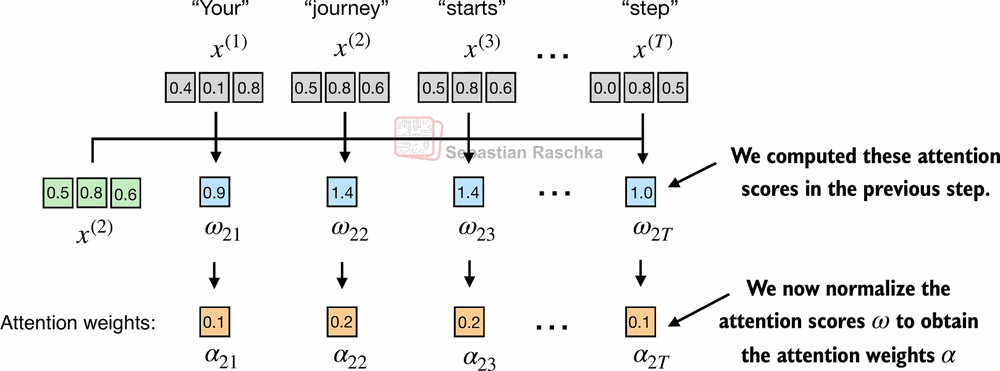

> 🇧🇷 **O que esta célula faz:** Normaliza as pontuações dividindo-as pela soma total; os pesos resultantes somam 1.

In [58]:
attn_weights_2_tmp = attn_scores_2 / attn_scores_2.sum()

print("Attention weights:", attn_weights_2_tmp)
print("Sum:", attn_weights_2_tmp.sum())

Attention weights: tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum: tensor(1.0000)


- Na prática, porém, o comum e recomendado é usar a função softmax para a normalização, pois ela lida melhor com valores extremos e tem propriedades de gradiente mais desejáveis durante o treinamento.
- Aqui está uma implementação ingênua da função softmax para fazer esse escalonamento, que também normaliza os elementos do vetor para que somem 1:

> 🇧🇷 **O que esta célula faz:** Implementa uma softmax simples à mão e a aplica às pontuações; os pesos obtidos também somam 1.

In [59]:
def softmax_naive(x):
    return torch.exp(x) / torch.exp(x).sum(dim=0)

attn_weights_2_naive = softmax_naive(attn_scores_2)

print("Attention weights:", attn_weights_2_naive)
print("Sum:", attn_weights_2_naive.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


- A implementação ingênua acima pode sofrer de instabilidade numérica com valores de entrada muito grandes ou muito pequenos, por causa de problemas de overflow e underflow
- Por isso, na prática, recomenda-se usar a implementação de softmax do PyTorch, que foi altamente otimizada para desempenho:

> 🇧🇷 **O que esta célula faz:** Aplica a softmax do PyTorch às pontuações e obtém os mesmos pesos de atenção da versão manual, somando 1.

In [60]:
attn_weights_2 = torch.softmax(attn_scores_2, dim=0)

print("Attention weights:", attn_weights_2)
print("Sum:", attn_weights_2.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


- **Passo 3**: calcular o context vector $z^{(2)}$ multiplicando os tokens de entrada (já em forma de embedding), $x^{(i)}$, pelos pesos de atenção e somando os vetores resultantes:

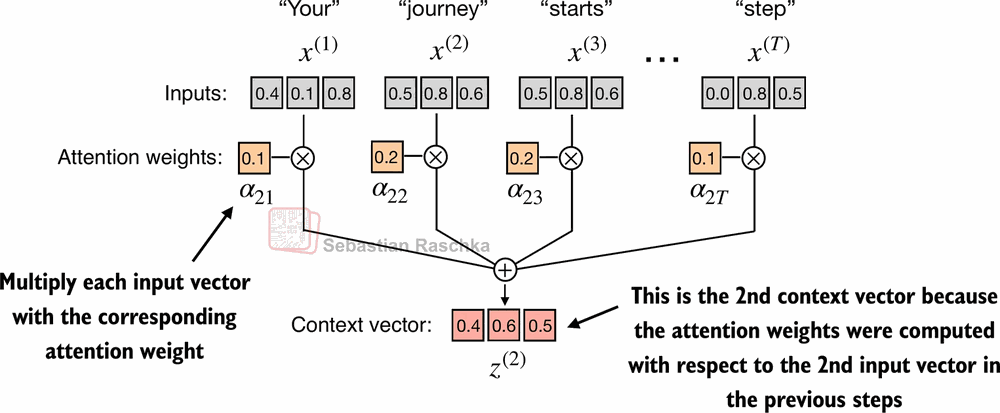

> 🇧🇷 **O que esta célula faz:** Calcula o context vector do segundo token como a soma de todas as entradas ponderadas pelos pesos de atenção. Prints extras mostram o objeto enumerate e, a cada passo, o vetor de entrada e o peso usado.

In [61]:
query = inputs[1] # 2nd input token is the query
print(enumerate(inputs))
context_vec_2 = torch.zeros(query.shape)
for i,x_i in enumerate(inputs):
    print(x_i)
    print(attn_weights_2[i])
    context_vec_2 += attn_weights_2[i]*x_i

print(context_vec_2)

tensor([0.4300, 0.1500, 0.8900])
tensor(0.1385)
tensor([0.5500, 0.8700, 0.6600])
tensor(0.2379)
tensor([0.5700, 0.8500, 0.6400])
tensor(0.2333)
tensor([0.2200, 0.5800, 0.3300])
tensor(0.1240)
tensor([0.7700, 0.2500, 0.1000])
tensor(0.1082)
tensor([0.0500, 0.8000, 0.5500])
tensor(0.1581)
tensor([0.4419, 0.6515, 0.5683])


### 2.3.2 Calculando os pesos de atenção para todos os tokens de entrada

#### Generalizando para todos os tokens da sequência de entrada:

- Acima, calculamos os pesos de atenção e o context vector para a entrada 2 (como ilustrado na linha destacada da figura abaixo)
- A seguir, vamos generalizar esse cálculo para obter todos os pesos de atenção e todos os context vectors

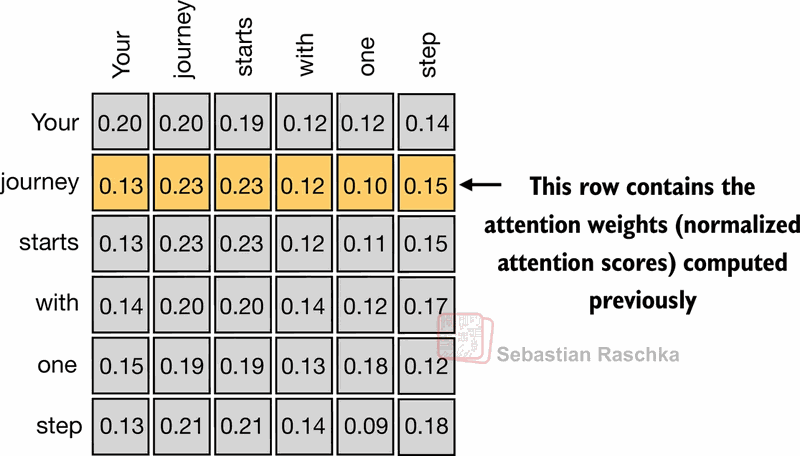

- Na self-attention, o processo começa com o cálculo das pontuações de atenção, que depois são normalizadas para gerar pesos de atenção que somam 1
- Esses pesos de atenção são então usados para gerar os context vectors por meio de uma soma ponderada das entradas

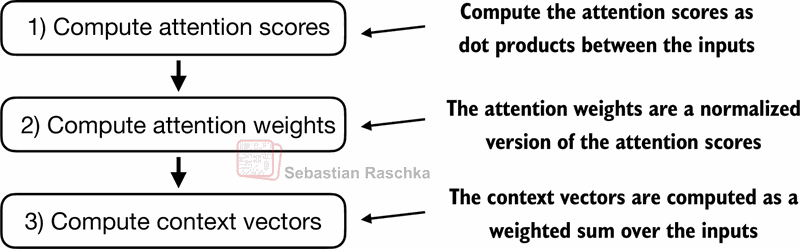

- Aplique o **passo 1** anterior a todos os pares de elementos para calcular a matriz de pontuações de atenção não normalizadas:

> 🇧🇷 **O que esta célula faz:** Calcula, com laços, as pontuações de atenção entre todos os pares de tokens, formando uma matriz 6x6.

In [62]:
attn_scores = torch.empty(6, 6)

for i, x_i in enumerate(inputs):
    for j, x_j in enumerate(inputs):
        attn_scores[i, j] = torch.dot(x_i, x_j)

print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


- Podemos obter o mesmo resultado de forma mais eficiente por meio de multiplicação de matrizes:

> 🇧🇷 **O que esta célula faz:** Obtém a mesma matriz de pontuações de forma muito mais eficiente, com uma única multiplicação de matrizes.

In [63]:
attn_scores = inputs @ inputs.T
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


- De forma semelhante ao **passo 2** anterior, normalizamos cada linha para que os valores de cada linha somem 1:

> 🇧🇷 **O que esta célula faz:** Aplica a softmax em cada linha da matriz, transformando as pontuações em pesos de atenção.

In [64]:
attn_weights = torch.softmax(attn_scores, dim=-1)
print(attn_weights)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


- Uma verificação rápida de que os valores de cada linha realmente somam 1:

> 🇧🇷 **O que esta célula faz:** Confere que cada linha da matriz de pesos de atenção soma 1.

In [65]:
row_2_sum = sum([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
print("Row 2 sum:", row_2_sum)

print("All row sums:", attn_weights.sum(dim=-1))

Row 2 sum: 1.0
All row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


- Aplique o **passo 3** anterior para calcular todos os context vectors:

> 🇧🇷 **O que esta célula faz:** Calcula de uma só vez os context vectors de todos os tokens, multiplicando a matriz de pesos pelas entradas.

In [66]:
all_context_vecs = attn_weights @ inputs
print(all_context_vecs)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


- Como verificação, o context vector calculado anteriormente, $z^{(2)} = [0.4419, 0.6515, 0.5683]$, aparece na 2ª linha do resultado acima: 

> 🇧🇷 **O que esta célula faz:** Mostra o context vector calculado antes para o segundo token, que coincide com a segunda linha do resultado anterior.

In [67]:
print("Previous 2nd context vector:", context_vec_2)

Previous 2nd context vector: tensor([0.4419, 0.6515, 0.5683])


## 2.4 Implementando self-attention com pesos treináveis

- Um esquema conceitual que ilustra como o mecanismo de self-attention desenvolvido nesta seção se integra à narrativa e à estrutura geral deste notebook e desta parte

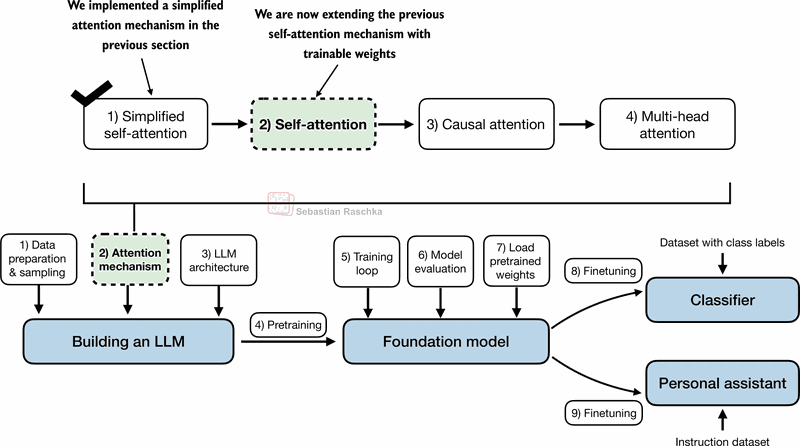

### 2.4.1 Calculando os pesos de atenção passo a passo

- Nesta seção, vamos implementar o mecanismo de self-attention usado na arquitetura transformer original, nos modelos GPT e na maioria dos outros LLMs populares
- Esse mecanismo de self-attention também é chamado de "scaled dot-product attention" (atenção por produto escalar escalonado)
- A ideia geral é parecida com a anterior:
  - Queremos calcular context vectors como somas ponderadas dos vetores de entrada, específicas para um determinado elemento de entrada
  - Para isso, precisamos de pesos de atenção
- Como você verá, há apenas pequenas diferenças em relação ao mecanismo de atenção básico apresentado antes:
  - A diferença mais notável é a introdução de matrizes de pesos que são atualizadas durante o treinamento do modelo
  - Essas matrizes de pesos treináveis são essenciais para que o modelo (mais especificamente, o módulo de atenção dentro do modelo) consiga aprender a produzir context vectors "bons"

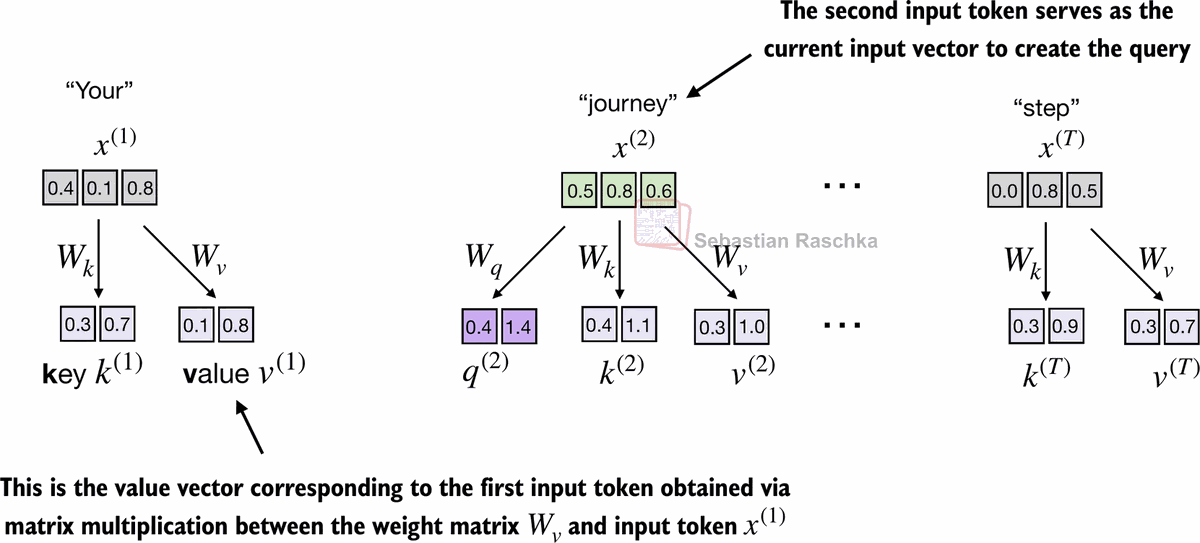

- Implementando o mecanismo de self-attention passo a passo, começaremos apresentando as três matrizes de pesos de treinamento $W_q$, $W_k$ e $W_v$
- Essas três matrizes são usadas para projetar os tokens de entrada (já em forma de embedding), $x^{(i)}$, em vetores query, key e value por meio de multiplicação de matrizes:

  - Vetor query: $q^{(i)} = W_q \,x^{(i)}$
  - Vetor key: $k^{(i)} = W_k \,x^{(i)}$
  - Vetor value: $v^{(i)} = W_v \,x^{(i)}$


- As dimensões de embedding da entrada $x$ e do vetor query $q$ podem ser iguais ou diferentes, dependendo do projeto do modelo e da implementação específica
- Nos modelos GPT, as dimensões de entrada e de saída costumam ser iguais, mas, para fins de ilustração e para acompanhar melhor o cálculo, escolhemos aqui dimensões de entrada e de saída diferentes:

> 🇧🇷 **O que esta célula faz:** Define o segundo token como exemplo e as dimensões de entrada (3) e de saída (2) das projeções.

In [68]:
x_2 = inputs[1] # second input element
d_in = inputs.shape[1] # the input embedding size, d=3
d_out = 2 # the output embedding size, d=2

- Abaixo, inicializamos as três matrizes de pesos; observe que definimos `requires_grad=False` para deixar as saídas mais limpas nesta ilustração, mas, se fôssemos usar as matrizes de pesos para treinar o modelo, definiríamos `requires_grad=True` para que essas matrizes fossem atualizadas durante o treinamento

> 🇧🇷 **O que esta célula faz:** Inicializa aleatoriamente, com semente fixa, as três matrizes de pesos de query, key e value.

In [69]:
torch.manual_seed(123)

W_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_key   = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)

- Em seguida, calculamos os vetores query, key e value:

> 🇧🇷 **O que esta célula faz:** Projeta o segundo token nos vetores query, key e value e mostra o vetor query resultante, de 2 dimensões.

In [70]:
query_2 = x_2 @ W_query # _2 because it's with respect to the 2nd input element
key_2 = x_2 @ W_key 
value_2 = x_2 @ W_value

print(query_2)

tensor([0.4306, 1.4551])


- Como vemos abaixo, projetamos com sucesso os 6 tokens de entrada de um espaço de embedding 3D para um espaço 2D:

> 🇧🇷 **O que esta célula faz:** Calcula keys e values para todos os tokens; os formatos mostram 6 tokens projetados em 2 dimensões.

In [71]:
keys = inputs @ W_key 
values = inputs @ W_value

print("keys.shape:", keys.shape)
print("values.shape:", values.shape)

keys.shape: torch.Size([6, 2])
values.shape: torch.Size([6, 2])


- No próximo passo, o **passo 2**, calculamos as pontuações de atenção não normalizadas, fazendo o produto escalar entre a query e cada vetor key:

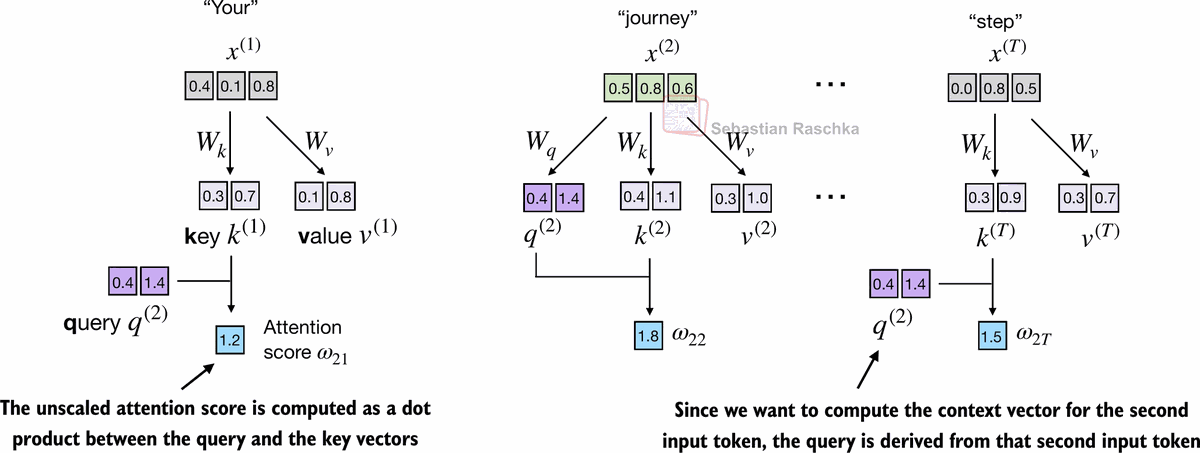

> 🇧🇷 **O que esta célula faz:** Calcula a pontuação de atenção entre a query do segundo token e a sua própria key.

In [72]:
keys_2 = keys[1] # Python starts index at 0
attn_score_22 = query_2.dot(keys_2)
print(attn_score_22)

tensor(1.8524)


- Como temos 6 entradas, temos 6 pontuações de atenção para o vetor query em questão:

> 🇧🇷 **O que esta célula faz:** Calcula de uma vez as seis pontuações de atenção da query do segundo token em relação a todas as keys.

In [73]:
attn_scores_2 = query_2 @ keys.T # All attention scores for given query
print(attn_scores_2)

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])


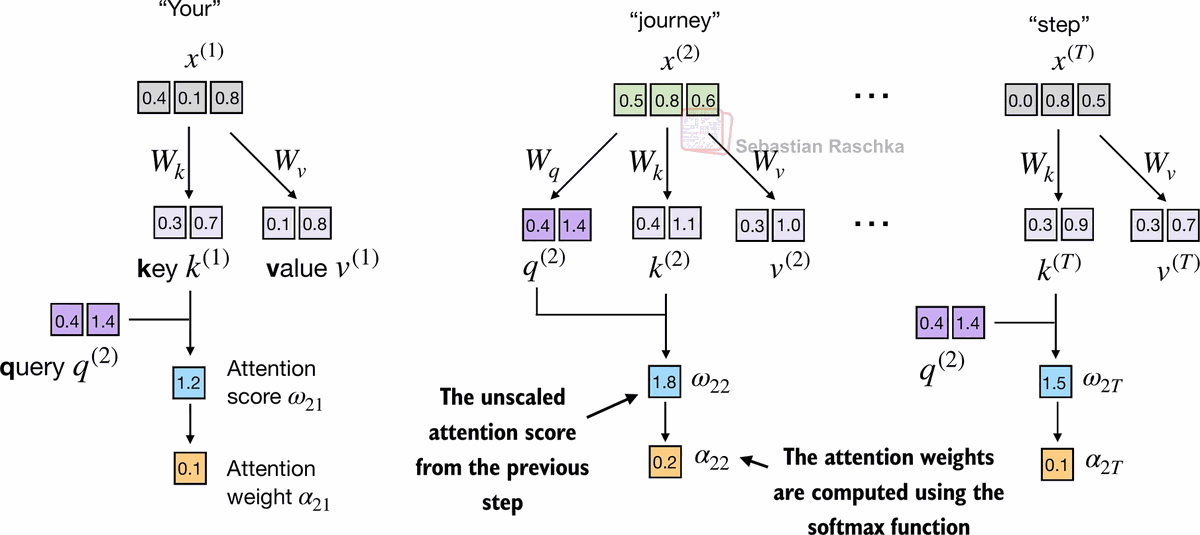

- Em seguida, no **passo 3**, calculamos os pesos de atenção (pontuações de atenção normalizadas que somam 1) usando a função softmax que já usamos antes
- A diferença em relação a antes é que agora escalonamos as pontuações de atenção, dividindo-as pela raiz quadrada da dimensão de embedding, $\sqrt{d_k}$ (ou seja, `d_k**0.5`):

> 🇧🇷 **O que esta célula faz:** Escalona as pontuações pela raiz quadrada da dimensão das keys e aplica a softmax, obtendo os pesos de atenção.

In [74]:
d_k = keys.shape[1]
attn_weights_2 = torch.softmax(attn_scores_2 / d_k**0.5, dim=-1)
print(attn_weights_2)

tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])


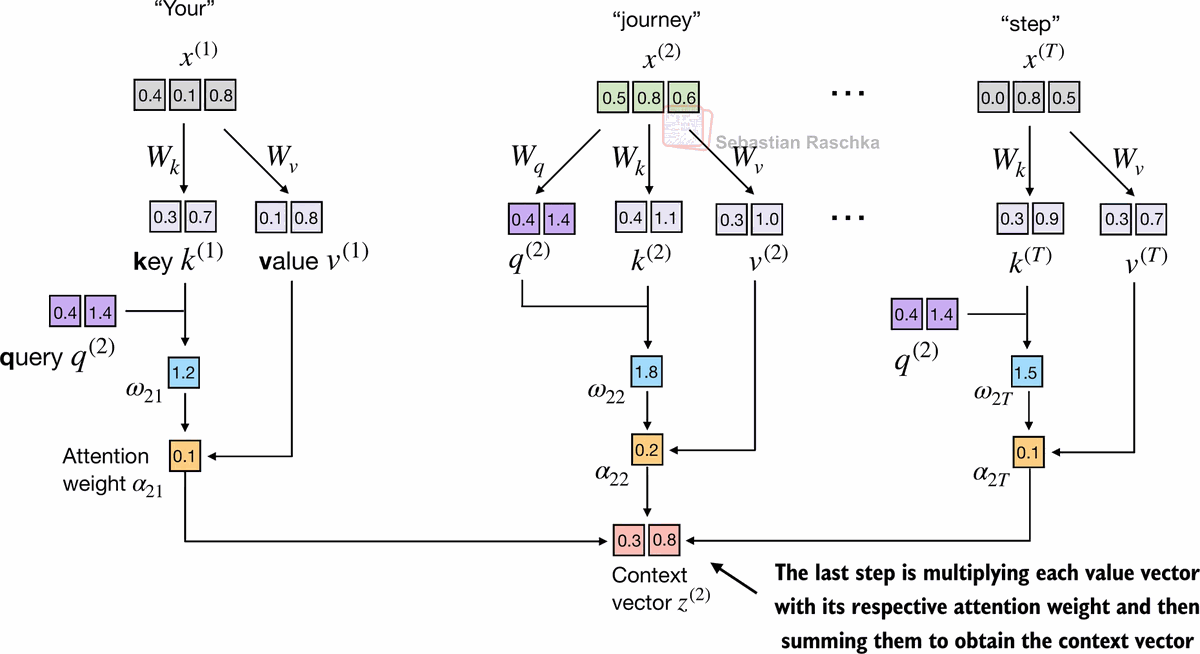

- No **passo 4**, calculamos agora o context vector para o vetor query de entrada 2:

> 🇧🇷 **O que esta célula faz:** Calcula o context vector do segundo token como a soma dos vetores value ponderada pelos pesos de atenção.

In [75]:
context_vec_2 = attn_weights_2 @ values
print(context_vec_2)

tensor([0.3061, 0.8210])


### 2.4.2 Implementando uma classe SelfAttention compacta

- Juntando tudo, podemos implementar o mecanismo de self-attention da seguinte forma:

> 🇧🇷 **O que esta célula faz:** Reúne todos os passos em uma classe de self-attention com pesos treináveis e mostra os context vectors dos seis tokens.

In [76]:
import torch.nn as nn

class SelfAttention_v1(nn.Module):

    def __init__(self, d_in, d_out):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Parameter(torch.rand(d_in, d_out))
        self.W_key   = nn.Parameter(torch.rand(d_in, d_out))
        self.W_value = nn.Parameter(torch.rand(d_in, d_out))

    def forward(self, x):
        keys = x @ self.W_key
        queries = x @ self.W_query
        values = x @ self.W_value
        
        attn_scores = queries @ keys.T # omega
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)

        context_vec = attn_weights @ values
        return context_vec

torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in, d_out)
print(sa_v1(inputs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


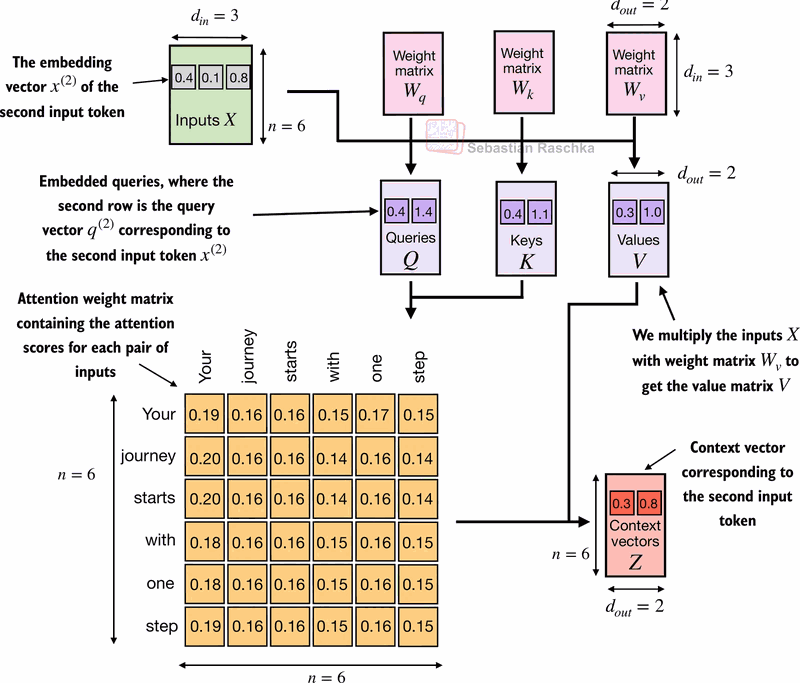

- Podemos simplificar a implementação acima usando as camadas Linear do PyTorch, que equivalem a uma multiplicação de matrizes quando desativamos as unidades de bias (viés)
- Outra grande vantagem de usar `nn.Linear` em vez da nossa abordagem manual com `nn.Parameter(torch.rand(...)` é que `nn.Linear` tem um esquema preferencial de inicialização de pesos, o que leva a um treinamento do modelo mais estável

> 🇧🇷 **O que esta célula faz:** Reescreve a classe usando camadas lineares do PyTorch, que têm uma inicialização de pesos melhor; por isso, os resultados diferem da versão anterior.

In [77]:
class SelfAttention_v2(nn.Module):

    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)
        
        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)

        context_vec = attn_weights @ values
        return context_vec

torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in, d_out)
print(sa_v2(inputs))

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


- Observe que `SelfAttention_v1` e `SelfAttention_v2` produzem saídas diferentes porque usam pesos iniciais diferentes nas matrizes de pesos

## 2.5 Escondendo palavras futuras com atenção causal

- Na atenção causal (causal attention), os pesos de atenção acima da diagonal são mascarados, garantindo que, para qualquer entrada, o LLM não consiga usar tokens futuros ao calcular os context vectors com os pesos de atenção

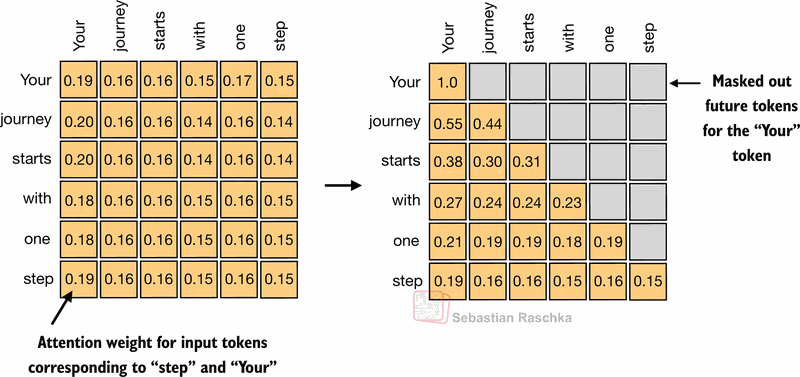

### 2.5.1 Aplicando uma máscara de atenção causal

- Nesta seção, vamos converter o mecanismo de self-attention anterior em um mecanismo de self-attention causal
- A self-attention causal garante que a previsão do modelo para uma determinada posição da sequência dependa apenas das saídas conhecidas nas posições anteriores, e não das posições futuras
- Em palavras mais simples, isso garante que a previsão de cada próxima palavra dependa somente das palavras anteriores
- Para isso, para cada token, mascaramos os tokens futuros (aqueles que vêm depois do token atual no texto de entrada):

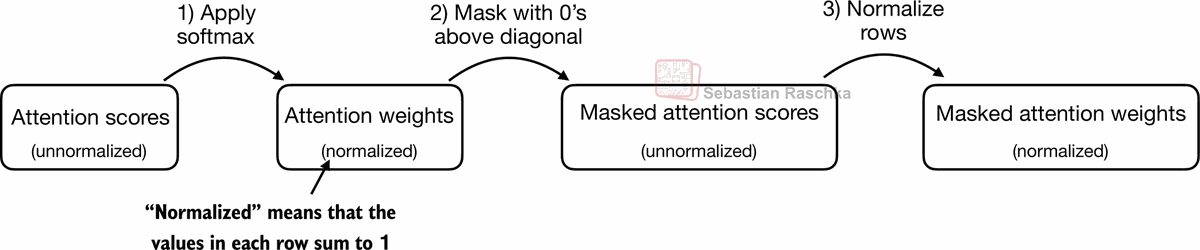

- Para ilustrar e implementar a self-attention causal, vamos trabalhar com as pontuações e os pesos de atenção da seção anterior: 

> 🇧🇷 **O que esta célula faz:** Recalcula os pesos de atenção dos seis tokens reaproveitando as matrizes do objeto da seção anterior.

In [78]:
# Reuse the query and key weight matrices of the
# SelfAttention_v2 object from the previous section for convenience
queries = sa_v2.W_query(inputs)
keys = sa_v2.W_key(inputs) 
attn_scores = queries @ keys.T

attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
print(attn_weights)

tensor([[0.1921, 0.1646, 0.1652, 0.1550, 0.1721, 0.1510],
        [0.2041, 0.1659, 0.1662, 0.1496, 0.1665, 0.1477],
        [0.2036, 0.1659, 0.1662, 0.1498, 0.1664, 0.1480],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.1661, 0.1564],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.1585],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


- A forma mais simples de mascarar os pesos de atenção futuros é criar uma máscara com a função tril do PyTorch, com os elementos abaixo da diagonal principal (incluindo a própria diagonal) iguais a 1 e os elementos acima da diagonal principal iguais a 0:

> 🇧🇷 **O que esta célula faz:** Cria uma máscara triangular inferior de uns e zeros, que marca quais tokens cada posição pode enxergar.

In [79]:
context_length = attn_scores.shape[0]
mask_simple = torch.tril(torch.ones(context_length, context_length))
print(mask_simple)

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


- Em seguida, podemos multiplicar os pesos de atenção por essa máscara para zerar as pontuações de atenção acima da diagonal:

> 🇧🇷 **O que esta célula faz:** Multiplica os pesos de atenção pela máscara, zerando os valores acima da diagonal (os tokens futuros).

In [80]:
masked_simple = attn_weights*mask_simple
print(masked_simple)

tensor([[0.1921, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2041, 0.1659, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2036, 0.1659, 0.1662, 0.0000, 0.0000, 0.0000],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.0000, 0.0000],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<MulBackward0>)


- No entanto, se a máscara fosse aplicada depois da softmax, como acima, ela desfaria a distribuição de probabilidade criada pela softmax
- A softmax garante que todos os valores de saída somem 1
- Mascarar depois da softmax exigiria renormalizar as saídas para que voltassem a somar 1, o que complica o processo e pode causar efeitos indesejados

- Para garantir que as linhas somem 1, podemos normalizar os pesos de atenção da seguinte forma:

> 🇧🇷 **O que esta célula faz:** Renormaliza cada linha dos pesos mascarados para que ela volte a somar 1.

In [81]:
row_sums = masked_simple.sum(dim=1, keepdim=True)
masked_simple_norm = masked_simple / row_sums
print(masked_simple_norm)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<DivBackward0>)


- Embora, tecnicamente, já tenhamos terminado de programar o mecanismo de atenção causal, vamos ver rapidamente uma abordagem mais eficiente para obter o mesmo resultado
- Assim, em vez de zerar os pesos de atenção acima da diagonal e renormalizar os resultados, podemos mascarar as pontuações de atenção não normalizadas acima da diagonal com menos infinito antes que elas entrem na função softmax:

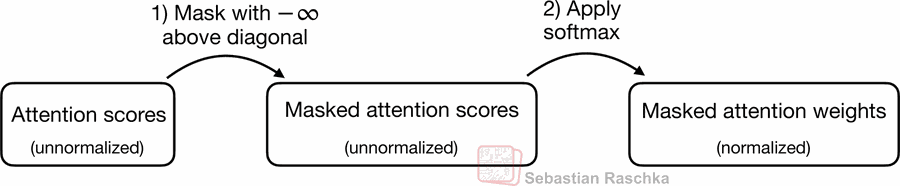

> 🇧🇷 **O que esta célula faz:** Preenche as pontuações acima da diagonal com menos infinito, uma forma mais eficiente de aplicar a máscara causal.

In [82]:
mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)
print(masked)

tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594, 0.1703, 0.1731,   -inf,   -inf,   -inf],
        [0.2642, 0.1024, 0.1036, 0.0186,   -inf,   -inf],
        [0.2183, 0.0874, 0.0882, 0.0177, 0.0786,   -inf],
        [0.3408, 0.1270, 0.1290, 0.0198, 0.1290, 0.0078]],
       grad_fn=<MaskedFillBackward0>)


- Como vemos abaixo, agora os pesos de atenção de cada linha voltam a somar 1 corretamente:

> 🇧🇷 **O que esta célula faz:** Aplica a softmax às pontuações mascaradas; os valores futuros viram zero e cada linha já soma 1, sem renormalização.

In [83]:
attn_weights = torch.softmax(masked / keys.shape[-1]**0.5, dim=-1)
print(attn_weights)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


### 2.5.2 Mascarando pesos de atenção adicionais com dropout

- Além disso, também aplicamos dropout (desligamento aleatório de valores) para reduzir o overfitting durante o treinamento
- O dropout pode ser aplicado em vários lugares:
  - por exemplo, depois de calcular os pesos de atenção;
  - ou depois de multiplicar os pesos de atenção pelos vetores value
- Aqui, vamos aplicar a máscara de dropout depois de calcular os pesos de atenção, porque essa é a forma mais comum

- Além disso, neste exemplo específico, usamos uma taxa de dropout de 50%, o que significa mascarar aleatoriamente metade dos pesos de atenção. (Quando treinarmos o modelo GPT mais adiante, usaremos uma taxa de dropout menor, como 0.1 ou 0.2

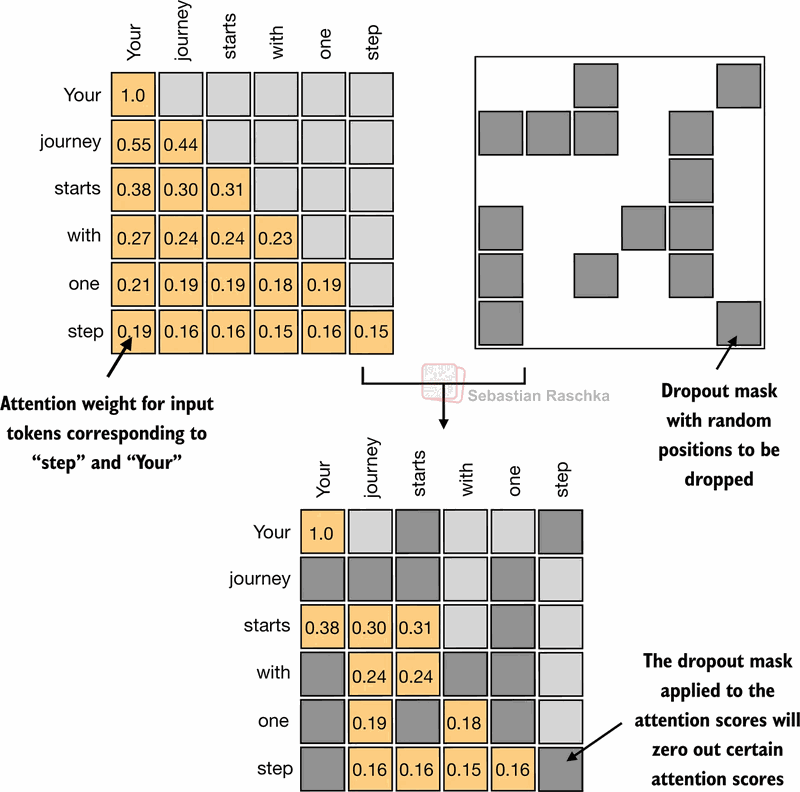

- Se aplicarmos uma taxa de dropout de 0.5 (50%), os valores não descartados serão escalonados de forma correspondente, por um fator de 1/0.5 = 2.

> 🇧🇷 **O que esta célula faz:** Aplica dropout de 50% a uma matriz de uns: cerca de metade dos valores é zerada e os restantes são multiplicados por 2.

In [84]:
torch.manual_seed(123)
dropout = torch.nn.Dropout(0.5) # dropout rate of 50%
example = torch.ones(6, 6) # create a matrix of ones

print(dropout(example))

tensor([[2., 2., 2., 2., 2., 2.],
        [0., 2., 0., 0., 0., 0.],
        [0., 0., 2., 0., 2., 0.],
        [2., 2., 0., 0., 0., 2.],
        [2., 0., 0., 0., 0., 2.],
        [0., 2., 0., 0., 0., 0.]])


> 🇧🇷 **O que esta célula faz:** Aplica o mesmo dropout aos pesos de atenção causais, zerando aleatoriamente parte deles.

In [85]:
torch.manual_seed(123)
print(dropout(attn_weights))

tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.8966, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.6206, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4921, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4350, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3327, 0.0000, 0.0000, 0.0000, 0.0000]],
       grad_fn=<MulBackward0>)


- Observe que as saídas do dropout podem ser diferentes dependendo do seu sistema operacional; você pode ler mais sobre essa inconsistência [aqui, no issue tracker do PyTorch](https://github.com/pytorch/pytorch/issues/121595)

### 2.5.3 Implementando uma classe compacta de self-attention causal

- Agora estamos prontos para fazer uma implementação funcional de self-attention, incluindo as máscaras causal e de dropout
- Falta mais uma coisa: implementar o código para lidar com lotes (batches) formados por mais de uma entrada, para que nossa classe `CausalAttention` aceite os lotes produzidos pelo data loader que implementamos na parte 1
- Para simplificar, e simular essa entrada em lote, duplicamos o exemplo de texto de entrada:

> 🇧🇷 **O que esta célula faz:** Simula um lote empilhando duas cópias da entrada; o formato mostra 2 exemplos com 6 tokens de 3 dimensões.

In [86]:
batch = torch.stack((inputs, inputs), dim=0)
print(batch.shape) # 2 inputs with 6 tokens each, and each token has embedding dimension 3

torch.Size([2, 6, 3])


> 🇧🇷 **O que esta célula faz:** Define uma classe de atenção causal com máscara e dropout que aceita lotes, e mostra os context vectors e o formato da saída.

In [87]:
class CausalAttention(nn.Module):

    def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout) # New
        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1)) # New

    def forward(self, x):
        b, num_tokens, d_in = x.shape # New batch dimension b
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        attn_scores = queries @ keys.transpose(1, 2) # Changed transpose
        attn_scores.masked_fill_(  # New, _ ops are in-place
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf) 
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights) # New

        context_vec = attn_weights @ values
        return context_vec

torch.manual_seed(123)

context_length = batch.shape[1]
ca = CausalAttention(d_in, d_out, context_length, 0.0)

context_vecs = ca(batch)

print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]],

        [[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]]], grad_fn=<UnsafeViewBackward0>)
context_vecs.shape: torch.Size([2, 6, 2])


- Observe que o dropout é aplicado apenas durante o treinamento, e não durante a inferência

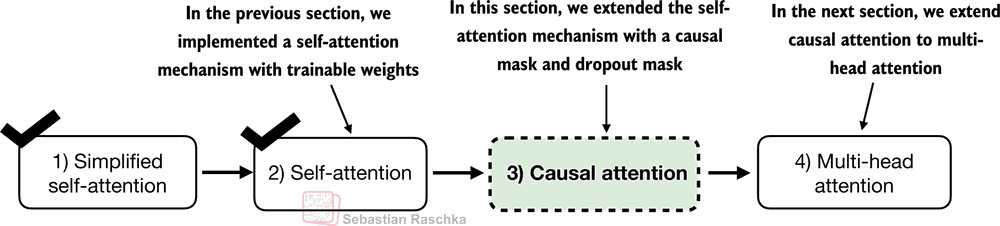

## 2.6 Estendendo a atenção de uma cabeça para multi-head attention

### 2.6.1 Empilhando várias camadas de atenção de uma cabeça

- Abaixo está um resumo da self-attention implementada anteriormente (as máscaras causal e de dropout não aparecem, para simplificar)

- Isso também é chamado de single-head attention (atenção de uma única cabeça):

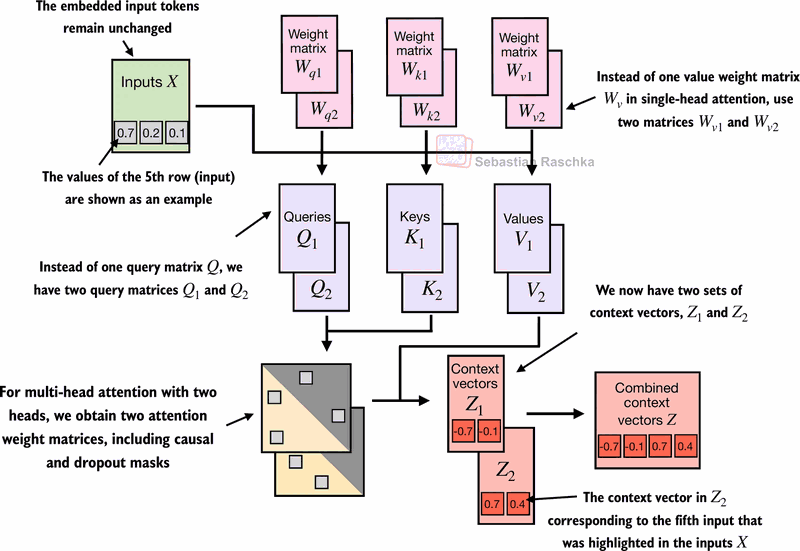

- Basta empilhar vários módulos de atenção de uma cabeça para obter um módulo de multi-head attention (atenção com múltiplas cabeças):

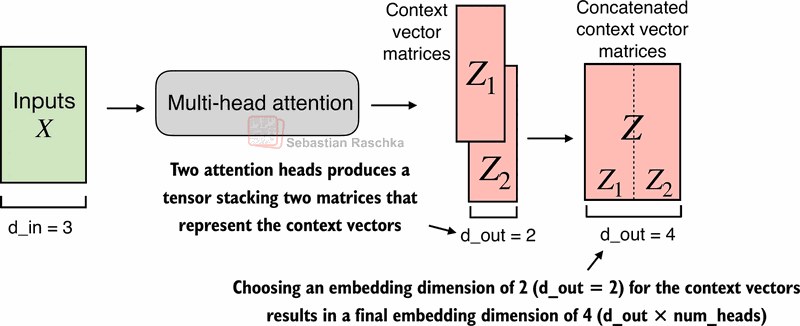

- A ideia principal da multi-head attention é executar o mecanismo de atenção várias vezes (em paralelo), com projeções lineares diferentes e aprendidas. Isso permite que o modelo preste atenção, ao mesmo tempo, a informações de diferentes subespaços de representação em diferentes posições.

> 🇧🇷 **O que esta célula faz:** Cria uma multi-head attention empilhando duas cabeças de atenção causal e concatenando suas saídas, que passam a ter 4 dimensões por token.

In [88]:
class MultiHeadAttentionWrapper(nn.Module):

    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        self.heads = nn.ModuleList(
            [CausalAttention(d_in, d_out, context_length, dropout, qkv_bias) 
             for _ in range(num_heads)]
        )

    def forward(self, x):
        return torch.cat([head(x) for head in self.heads], dim=-1)


torch.manual_seed(123)

context_length = batch.shape[1] # This is the number of tokens
d_in, d_out = 3, 2
mha = MultiHeadAttentionWrapper(d_in, d_out, context_length, 0.0, num_heads=2)

context_vecs = mha(batch)

print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]],

        [[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)
context_vecs.shape: torch.Size([2, 6, 4])


- Na implementação acima, a dimensão de embedding é 4, porque usamos `d_out=2` como dimensão de embedding para os vetores key, query e value, assim como para o context vector. E, como temos 2 cabeças de atenção, a dimensão de embedding da saída é 2*2=4

### 2.6.2 Implementando multi-head attention com divisão de pesos

- Embora a implementação acima seja uma implementação intuitiva e totalmente funcional de multi-head attention (que envolve a implementação de atenção de uma cabeça `CausalAttention` vista antes), podemos escrever uma classe independente chamada `MultiHeadAttention` para obter o mesmo resultado

- Nessa classe independente `MultiHeadAttention`, não concatenamos cabeças de atenção individuais
- Em vez disso, criamos matrizes de pesos W_query, W_key e W_value únicas e depois as dividimos em matrizes individuais para cada cabeça de atenção:

> 🇧🇷 **O que esta célula faz:** Implementa a multi-head attention de forma mais eficiente, dividindo matrizes únicas de pesos entre as cabeças, e mostra a saída e seu formato.

In [89]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x) # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim) 
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)
        
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2) 
        
        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec) # optional projection

        return context_vec

torch.manual_seed(123)

batch_size, context_length, d_in = batch.shape
d_out = 2
mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads=2)

context_vecs = mha(batch)

print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]],

        [[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]]], grad_fn=<ViewBackward0>)
context_vecs.shape: torch.Size([2, 6, 2])


- Observe que o código acima é, essencialmente, uma versão reescrita e mais eficiente de `MultiHeadAttentionWrapper`
- A saída resultante é um pouco diferente porque as inicializações aleatórias dos pesos são diferentes, mas ambas são implementações totalmente funcionais que podem ser usadas na classe GPT que vamos implementar nas próximas partes
- Observe também que adicionamos uma camada de projeção linear (`self.out_proj `) à classe `MultiHeadAttention` acima. Trata-se simplesmente de uma transformação linear que não altera as dimensões. Usar essa camada de projeção é uma convenção padrão nas implementações de LLMs, mas ela não é estritamente necessária (pesquisas recentes mostraram que ela pode ser removida sem afetar o desempenho da modelagem; veja a seção de leituras complementares no final desta parte)


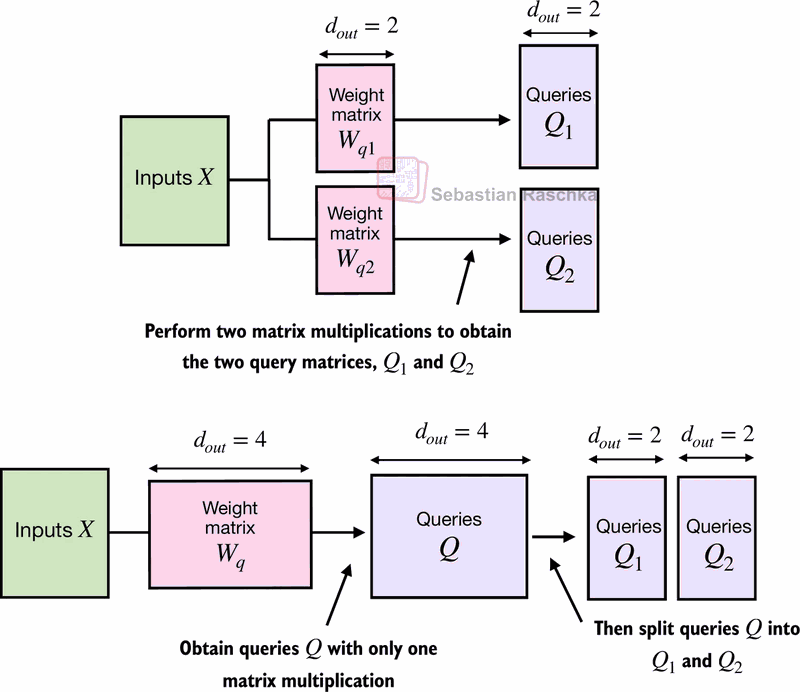

- Observe que, se você tiver interesse em uma implementação compacta e eficiente do que foi feito acima, também pode considerar a classe [`torch.nn.MultiheadAttention`](https://pytorch.org/docs/stable/generated/torch.nn.MultiheadAttention.html) do PyTorch

- Como a implementação acima pode parecer um pouco complexa à primeira vista, vamos ver o que acontece ao executar `attn_scores = queries @ keys.transpose(2, 3)`:

> 🇧🇷 **O que esta célula faz:** Mostra, com um pequeno tensor de 4 dimensões, a multiplicação de matrizes em lote usada para calcular as pontuações de todas as cabeças de uma vez.

In [90]:
# (b, num_heads, num_tokens, head_dim) = (1, 2, 3, 4)
a = torch.tensor([[[[0.2745, 0.6584, 0.2775, 0.8573],
                    [0.8993, 0.0390, 0.9268, 0.7388],
                    [0.7179, 0.7058, 0.9156, 0.4340]],

                   [[0.0772, 0.3565, 0.1479, 0.5331],
                    [0.4066, 0.2318, 0.4545, 0.9737],
                    [0.4606, 0.5159, 0.4220, 0.5786]]]])

print(a @ a.transpose(2, 3))

tensor([[[[1.3208, 1.1631, 1.2879],
          [1.1631, 2.2150, 1.8424],
          [1.2879, 1.8424, 2.0402]],

         [[0.4391, 0.7003, 0.5903],
          [0.7003, 1.3737, 1.0620],
          [0.5903, 1.0620, 0.9912]]]])


- Nesse caso, a implementação de multiplicação de matrizes do PyTorch lida com o tensor de entrada de 4 dimensões de modo que a multiplicação de matrizes seja feita entre as 2 últimas dimensões (num_tokens, head_dim) e depois repetida para cada cabeça

- Por exemplo, o código a seguir é uma forma mais compacta de calcular a multiplicação de matrizes para cada cabeça separadamente:

> 🇧🇷 **O que esta célula faz:** Calcula o mesmo produto separadamente para cada cabeça e confirma que os resultados coincidem com a versão em lote.

In [91]:
first_head = a[0, 0, :, :]
first_res = first_head @ first_head.T
print("First head:\n", first_res)

second_head = a[0, 1, :, :]
second_res = second_head @ second_head.T
print("\nSecond head:\n", second_res)

First head:
 tensor([[1.3208, 1.1631, 1.2879],
        [1.1631, 2.2150, 1.8424],
        [1.2879, 1.8424, 2.0402]])

Second head:
 tensor([[0.4391, 0.7003, 0.5903],
        [0.7003, 1.3737, 1.0620],
        [0.5903, 1.0620, 0.9912]])


# Resumo e principais lições

- Veja o notebook de código [./multihead-attention.ipynb](./multihead-attention.ipynb), que é uma versão concisa do data loader (parte 1) junto com a classe de multi-head attention que implementamos nesta parte e da qual vamos precisar para treinar o modelo GPT nas próximas partes

# Parte 3 — Implementando um modelo GPT do zero

Nesta parte montamos o coração do LLM: a arquitetura de um modelo no estilo GPT, com o tamanho do menor GPT-2 (124 milhões de parâmetros).
Partimos dos embeddings de tokens (parte 1) e da atenção multi-head (parte 2) e acrescentamos as peças que faltam: layer normalization, a ativação GELU, a rede feed forward e as shortcut connections.
Juntas, elas formam o transformer block, que é empilhado 12 vezes para compor o modelo GPT completo.
No final, usamos o modelo para gerar texto token a token. Como ele ainda não foi treinado, o resultado sai sem sentido; o treinamento é o assunto da parte 4.

> 🇧🇷 **O que esta célula faz:** Importa as bibliotecas usadas nesta parte e mostra as versões instaladas de matplotlib, PyTorch e tiktoken.

In [92]:
from importlib.metadata import version

import matplotlib
import tiktoken
import torch

print("matplotlib version:", version("matplotlib"))
print("torch version:", version("torch"))
print("tiktoken version:", version("tiktoken"))

matplotlib version: 3.8.4
torch version: 2.3.1
tiktoken version: 0.7.0


- Nesta parte, implementamos uma arquitetura de LLM no estilo GPT; a próxima parte vai se concentrar no treinamento desse LLM

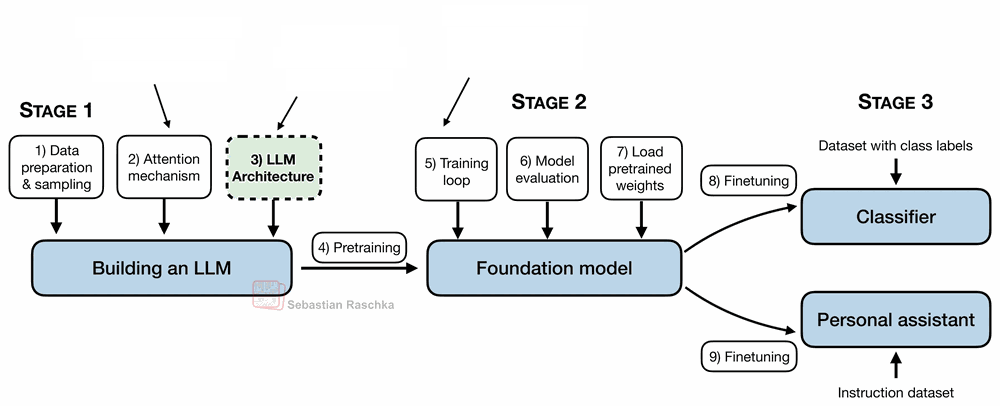

## 3.1 Codificando a arquitetura de um LLM

- Modelos como GPT e Llama geram palavras sequencialmente e se baseiam na parte do decoder (decodificador) da arquitetura transformer original
- Por isso, esses LLMs costumam ser chamados de LLMs "do tipo decoder" ("decoder-like")
- Em comparação com modelos convencionais de deep learning, os LLMs são maiores principalmente por causa do seu enorme número de parâmetros, e não da quantidade de código
- Veremos que muitos elementos se repetem na arquitetura de um LLM

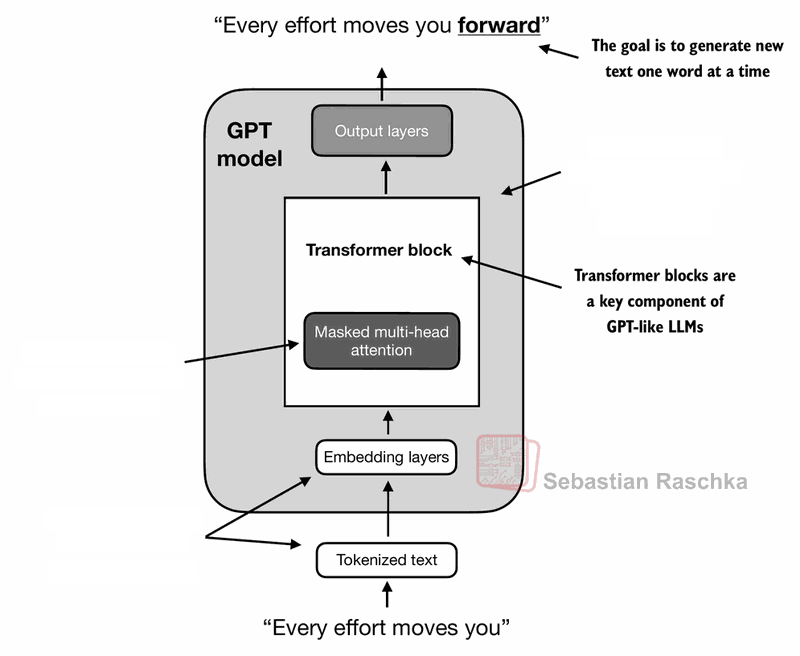

- Nas partes anteriores, usamos dimensões de embedding pequenas para as entradas e saídas de tokens, para facilitar a ilustração e garantir que coubessem em uma única página
- Nesta parte, consideramos tamanhos de embedding e de modelo semelhantes aos de um modelo GPT-2 pequeno
- Vamos codificar especificamente a arquitetura do menor modelo GPT-2 (124 milhões de parâmetros), conforme descrito em [Language Models are Unsupervised Multitask Learners](https://d4mucfpksywv.cloudfront.net/better-language-models/language_models_are_unsupervised_multitask_learners.pdf), de Radford et al. (observe que o relatório inicial o lista com 117M de parâmetros, mas isso foi corrigido depois no repositório de pesos do modelo)
- A parte 5 mostrará como carregar pesos pré-treinados na nossa implementação, que será compatível com modelos de 345, 762 e 1542 milhões de parâmetros

- Os detalhes de configuração do modelo GPT-2 de 124 milhões de parâmetros incluem:

> 🇧🇷 **O que esta célula faz:** Define a configuração do menor GPT-2 (124 milhões de parâmetros): tamanho do vocabulário, contexto, dimensão do embedding, número de cabeças e de camadas, dropout e bias.

In [93]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

- Usamos nomes de variáveis curtos para evitar linhas de código longas mais adiante
- `"vocab_size"` indica um vocabulário de 50.257 palavras, suportado pelo tokenizador BPE discutido na parte 1
- `"context_length"` representa o número máximo de tokens de entrada do modelo, viabilizado pelos embeddings posicionais vistos na parte 1
- `"emb_dim"` é o tamanho do embedding das entradas, convertendo cada token de entrada em um vetor de 768 dimensões
- `"n_heads"` é o número de cabeças de atenção (attention heads) no mecanismo de atenção multi-head implementado na parte 2
- `"n_layers"` é o número de transformer blocks (blocos transformer) dentro do modelo, que implementaremos nas próximas seções
- `"drop_rate"` é a intensidade do mecanismo de dropout, discutido na parte 2; 0.1 significa descartar 10% das unidades ocultas durante o treinamento para reduzir o overfitting (sobreajuste)
- `"qkv_bias"` define se as camadas `Linear` do mecanismo de atenção multi-head (da parte 2) devem incluir um vetor de bias ao calcular os tensores de query (Q), key (K) e value (V); vamos desativar essa opção, que é a prática padrão em LLMs modernos; no entanto, voltaremos a ela mais tarde, ao carregar os pesos pré-treinados do GPT-2 da OpenAI na nossa reimplementação, na parte 5

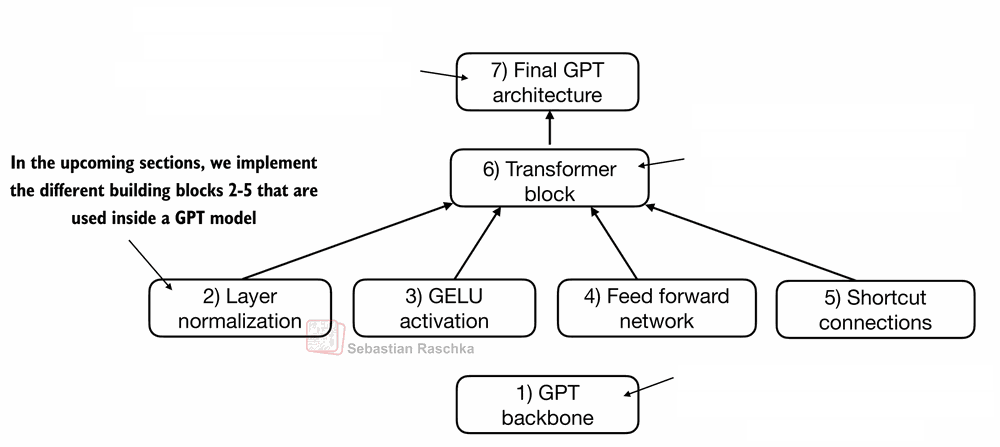

> 🇧🇷 **O que esta célula faz:** Cria um esqueleto do modelo GPT com peças provisórias (transformer block e LayerNorm que não fazem nada), só para visualizar o fluxo geral dos dados.

In [94]:
import torch
import torch.nn as nn


class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        # Use a placeholder for TransformerBlock
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        # Use a placeholder for LayerNorm
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # A simple placeholder

    def forward(self, x):
        # This block does nothing and just returns its input.
        return x


class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
        # The parameters here are just to mimic the LayerNorm interface.

    def forward(self, x):
        # This layer does nothing and just returns its input.
        return x

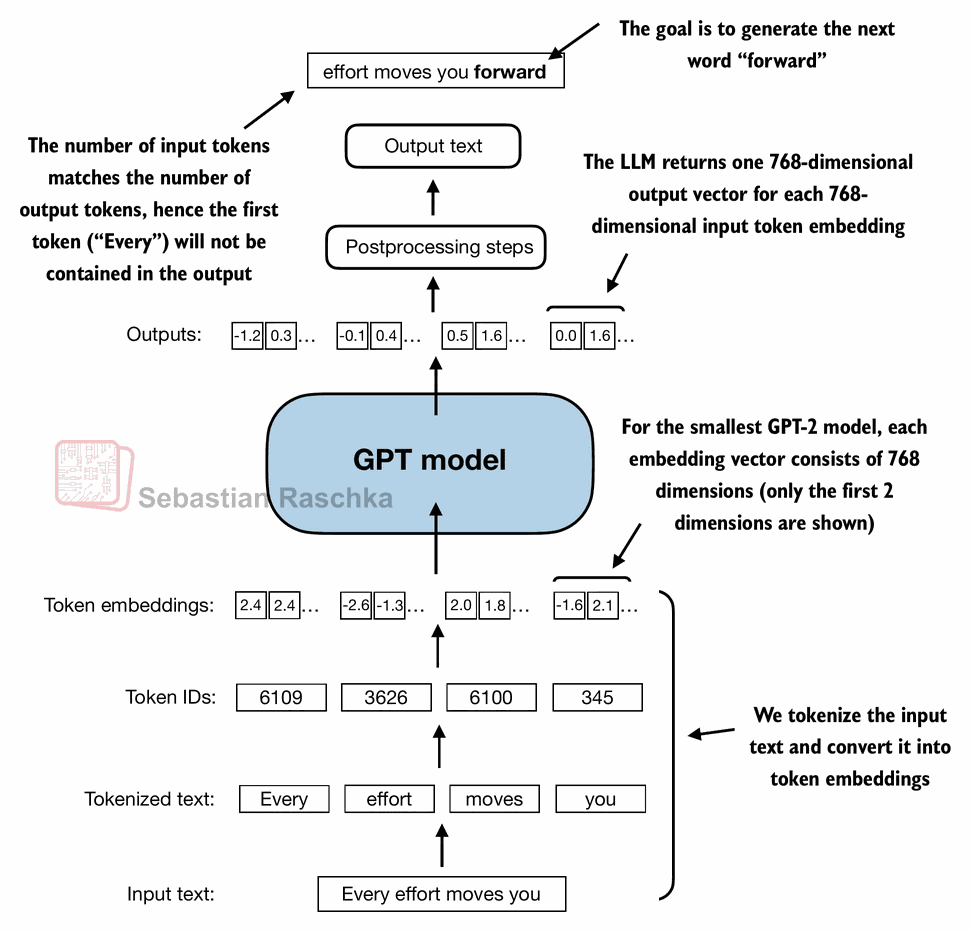

> 🇧🇷 **O que esta célula faz:** Tokeniza dois textos curtos com o tokenizador do GPT-2 e os empilha em um lote; a saída mostra os IDs dos 4 tokens de cada texto.

In [95]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

batch = []

txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


> 🇧🇷 **O que esta célula faz:** Passa o lote pelo modelo-esqueleto: a saída tem formato [2, 4, 50257], ou seja, um logit para cada palavra do vocabulário em cada posição.

In [96]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)

logits = model(batch)
print("Output shape:", logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-0.9289,  0.2748, -0.7557,  ..., -1.6070,  0.2702, -0.5888],
         [-0.4476,  0.1726,  0.5354,  ..., -0.3932,  1.5285,  0.8557],
         [ 0.5680,  1.6053, -0.2155,  ...,  1.1624,  0.1380,  0.7425],
         [ 0.0447,  2.4787, -0.8843,  ...,  1.3219, -0.0864, -0.5856]],

        [[-1.5474, -0.0542, -1.0571,  ..., -1.8061, -0.4494, -0.6747],
         [-0.8422,  0.8243, -0.1098,  ..., -0.1434,  0.2079,  1.2046],
         [ 0.1355,  1.1858, -0.1453,  ...,  0.0869, -0.1590,  0.1552],
         [ 0.1666, -0.8138,  0.2307,  ...,  2.5035, -0.3055, -0.3083]]],
       grad_fn=<UnsafeViewBackward0>)


## 3.2 Normalizando ativações com layer normalization

- A layer normalization (normalização de camada), também conhecida como LayerNorm ([Ba et al. 2016](https://arxiv.org/abs/1607.06450)), centraliza as ativações de uma camada de rede neural em torno de média 0 e normaliza sua variância para 1
- Isso estabiliza o treinamento e permite uma convergência mais rápida para pesos eficazes
- A layer normalization é aplicada antes e depois do módulo de atenção multi-head dentro do transformer block, que implementaremos mais adiante; ela também é aplicada antes da camada de saída final

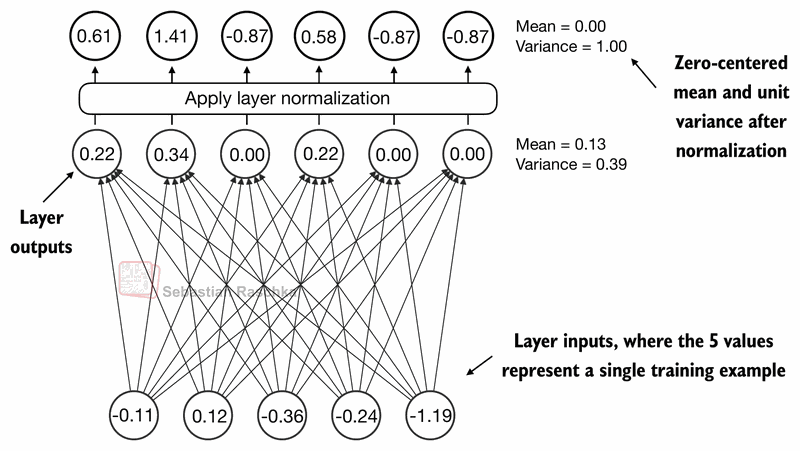

- Vamos ver como a layer normalization funciona passando uma pequena amostra de entrada por uma camada de rede neural simples:

> 🇧🇷 **O que esta célula faz:** Cria um pequeno exemplo com 2 entradas de 5 features e o passa por uma camada linear com ReLU, gerando 6 saídas por entrada.

In [97]:
torch.manual_seed(123)

# create 2 training examples with 5 dimensions (features) each
batch_example = torch.randn(2, 5) 

layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


- Vamos calcular a média e a variância de cada uma das 2 entradas acima:

> 🇧🇷 **O que esta célula faz:** Calcula a média e a variância das saídas de cada entrada, ainda não normalizadas.

In [98]:
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)

print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


- A normalização é aplicada a cada uma das duas entradas (linhas) de forma independente; usar dim=-1 aplica o cálculo ao longo da última dimensão (neste caso, a dimensão das features) em vez da dimensão das linhas

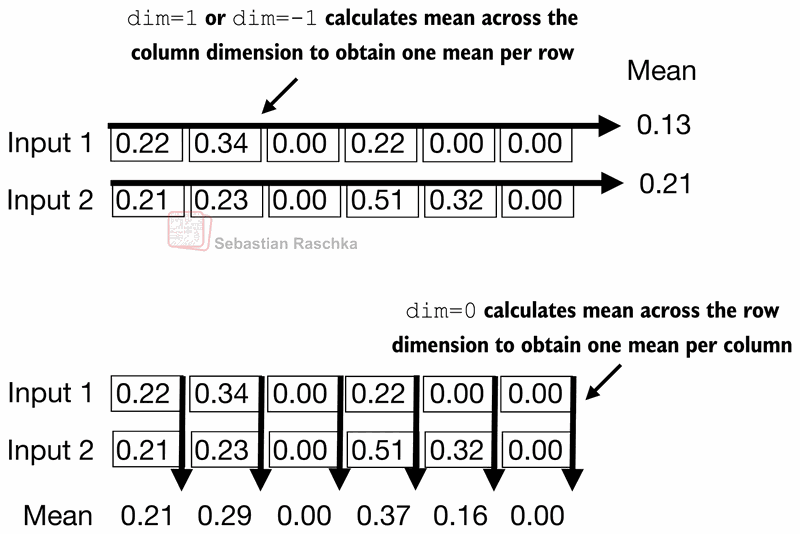

- Subtrair a média e dividir pela raiz quadrada da variância (o desvio padrão) centraliza as entradas para que tenham média 0 e variância 1 ao longo da dimensão das colunas (features):

> 🇧🇷 **O que esta célula faz:** Normaliza as saídas subtraindo a média e dividindo pelo desvio padrão; agora cada linha tem média 0 e variância 1.

In [99]:
out_norm = (out - mean) / torch.sqrt(var)
print("Normalized layer outputs:\n", out_norm)

mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Normalized layer outputs:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[    -0.0000],
        [    -0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


- Cada entrada está centrada em 0 e tem variância unitária igual a 1; para melhorar a legibilidade, podemos desativar a notação científica do PyTorch:

> 🇧🇷 **O que esta célula faz:** Desliga a notação científica do PyTorch para exibir média e variância de forma mais legível.

In [100]:
torch.set_printoptions(sci_mode=False)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[    -0.0000],
        [    -0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


- Acima, normalizamos as features de cada entrada
- Agora, usando a mesma ideia, podemos implementar uma classe `LayerNorm`:

> 🇧🇷 **O que esta célula faz:** Implementa a classe LayerNorm, que normaliza cada vetor e aplica os parâmetros treináveis de escala e deslocamento.

In [101]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

**Scale e shift (escala e deslocamento)**

- Observe que, além de fazer a normalização subtraindo a média e dividindo pela variância, adicionamos dois parâmetros treináveis: um parâmetro `scale` e um parâmetro `shift`
- Os valores iniciais de `scale` (multiplicar por 1) e `shift` (somar 0) não têm nenhum efeito; no entanto, `scale` e `shift` são parâmetros treináveis que o LLM ajusta automaticamente durante o treinamento, caso isso melhore o desempenho do modelo na tarefa de treinamento
- Isso permite que o modelo aprenda a escala e o deslocamento mais adequados aos dados que está processando
- Observe que também somamos um valor pequeno (`eps`) antes de calcular a raiz quadrada da variância; isso evita erros de divisão por zero caso a variância seja 0

**Variância enviesada**
- No cálculo da variância acima, definir `unbiased=False` significa usar a fórmula $\frac{\sum_i (x_i - \bar{x})^2}{n}$ para calcular a variância, em que n é o tamanho da amostra (aqui, o número de features ou colunas); essa fórmula não inclui a correção de Bessel (que usa `n-1` no denominador) e, portanto, fornece uma estimativa enviesada da variância
- Em LLMs, nos quais a dimensão de embedding `n` é muito grande, a diferença entre usar n e `n-1`
 é desprezível
- No entanto, o GPT-2 foi treinado com variância enviesada nas camadas de normalização, e é por isso que também adotamos essa configuração, por compatibilidade com os pesos pré-treinados que carregaremos em partes posteriores

- Vamos agora experimentar a `LayerNorm` na prática:

> 🇧🇷 **O que esta célula faz:** Cria uma LayerNorm para 5 features e a aplica ao exemplo de entrada.

In [102]:
ln = LayerNorm(emb_dim=5)
out_ln = ln(batch_example)

> 🇧🇷 **O que esta célula faz:** Confere o resultado da LayerNorm: cada entrada ficou com média 0 e variância 1.

In [103]:
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased=False, keepdim=True)

print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[    -0.0000],
        [     0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


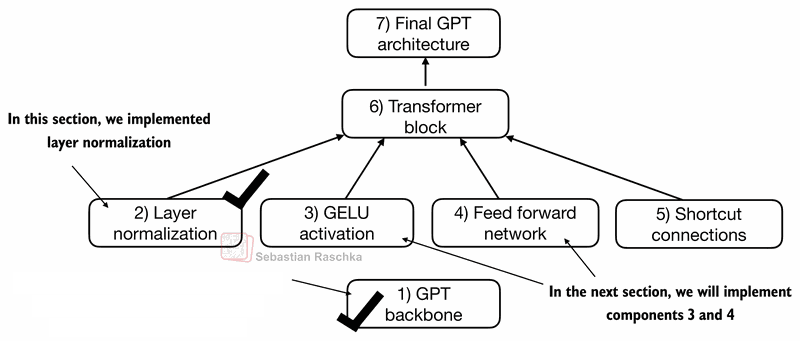

## 3.3 Implementando uma rede feed forward com ativações GELU

- Nesta seção, implementamos um pequeno submódulo de rede neural que é usado como parte do transformer block nos LLMs
- Começamos pela função de ativação
- Em deep learning, as funções de ativação ReLU (Rectified Linear Unit, unidade linear retificada) são muito usadas por sua simplicidade e eficácia em diversas arquiteturas de redes neurais
- Nos LLMs, vários outros tipos de função de ativação são usados além da ReLU tradicional; dois exemplos notáveis são a GELU (Gaussian Error Linear Unit) e a SwiGLU (Sigmoid-Weighted Linear Unit)
- GELU e SwiGLU são funções de ativação suaves e mais complexas, que incorporam, respectivamente, unidades lineares gaussianas e com portas sigmoides (sigmoid-gated), oferecendo melhor desempenho para modelos de deep learning, ao contrário da função mais simples e linear por partes da ReLU

- A GELU ([Hendrycks e Gimpel 2016](https://arxiv.org/abs/1606.08415)) pode ser implementada de várias formas; a versão exata é definida como GELU(x)=x⋅Φ(x), em que Φ(x) é a função de distribuição acumulada da distribuição gaussiana padrão.
- Na prática, é comum implementar uma aproximação computacionalmente mais barata: $\text{GELU}(x) \approx 0.5 \cdot x \cdot \left(1 + \tanh\left[\sqrt{\frac{2}{\pi}} \cdot \left(x + 0.044715 \cdot x^3\right)\right]\right)
$ (o modelo GPT-2 original também foi treinado com essa aproximação)

> 🇧🇷 **O que esta célula faz:** Implementa a função de ativação GELU usando a aproximação com tangente hiperbólica adotada no GPT-2.

In [104]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))
        ))

> 🇧🇷 **O que esta célula faz:** Desenha lado a lado os gráficos da GELU e da ReLU para comparar as duas funções de ativação.

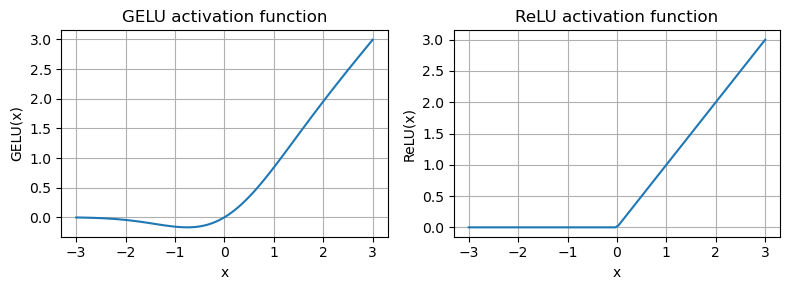

In [105]:
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

# Some sample data
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

- Como podemos ver, a ReLU é uma função linear por partes que devolve a própria entrada se ela for positiva; caso contrário, devolve zero
- A GELU é uma função suave e não linear que se aproxima da ReLU, mas com gradiente diferente de zero para valores negativos

- Em seguida, vamos implementar o pequeno módulo de rede neural `FeedForward`, que usaremos mais tarde no transformer block do LLM:

> 🇧🇷 **O que esta célula faz:** Implementa o módulo FeedForward: expande o embedding para 4 vezes o tamanho, aplica a GELU e volta à dimensão original.

In [106]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)

> 🇧🇷 **O que esta célula faz:** Mostra a dimensão do embedding usada no modelo: 768.

In [107]:
print(GPT_CONFIG_124M["emb_dim"])

768


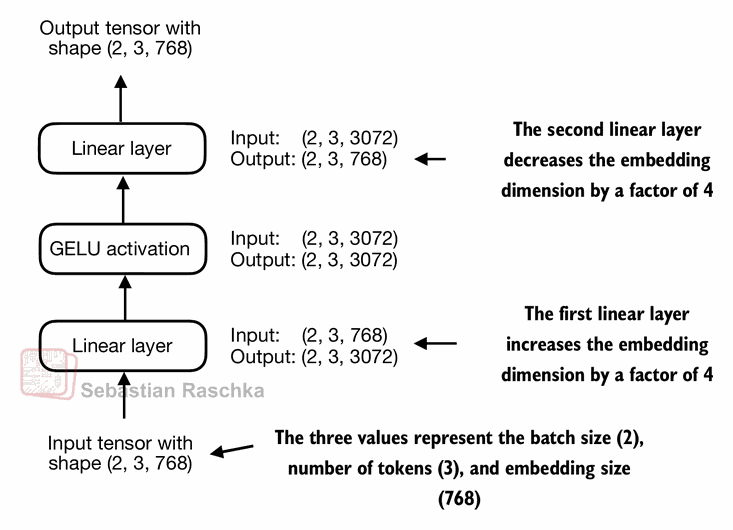

> 🇧🇷 **O que esta célula faz:** Passa um tensor aleatório pelo FeedForward; a saída mantém exatamente o formato da entrada, [2, 3, 768].

In [108]:
ffn = FeedForward(GPT_CONFIG_124M)

# input shape: [batch_size, num_token, emb_size]
x = torch.rand(2, 3, 768) 
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


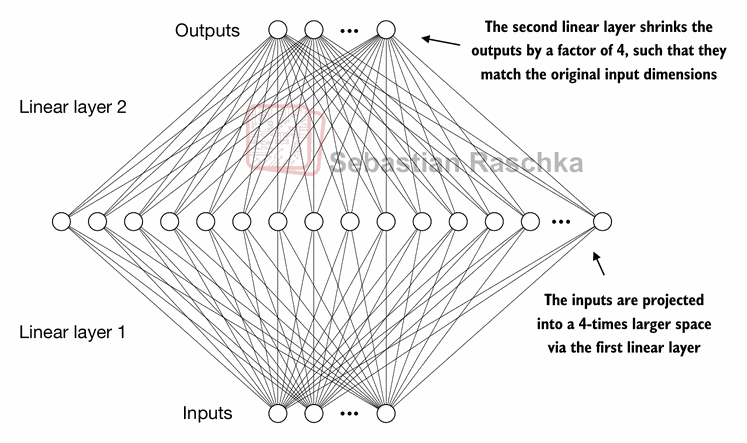

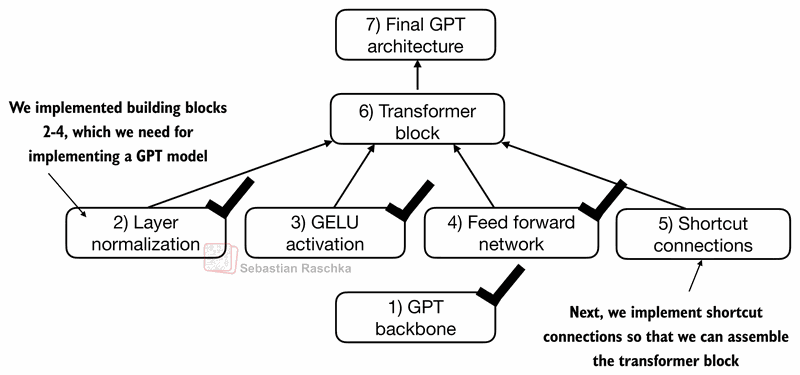

## 3.4 Adicionando shortcut connections

- A seguir, vamos falar sobre o conceito por trás das shortcut connections (conexões de atalho), também chamadas de skip connections ou conexões residuais
- Originalmente, as shortcut connections foram propostas em redes profundas para visão computacional (redes residuais) para amenizar o problema do desaparecimento do gradiente (vanishing gradient)
- Uma shortcut connection cria um caminho alternativo e mais curto para o gradiente fluir pela rede
- Isso é feito somando a saída de uma camada à saída de uma camada posterior, normalmente pulando uma ou mais camadas intermediárias
- Vamos ilustrar essa ideia com uma pequena rede de exemplo:

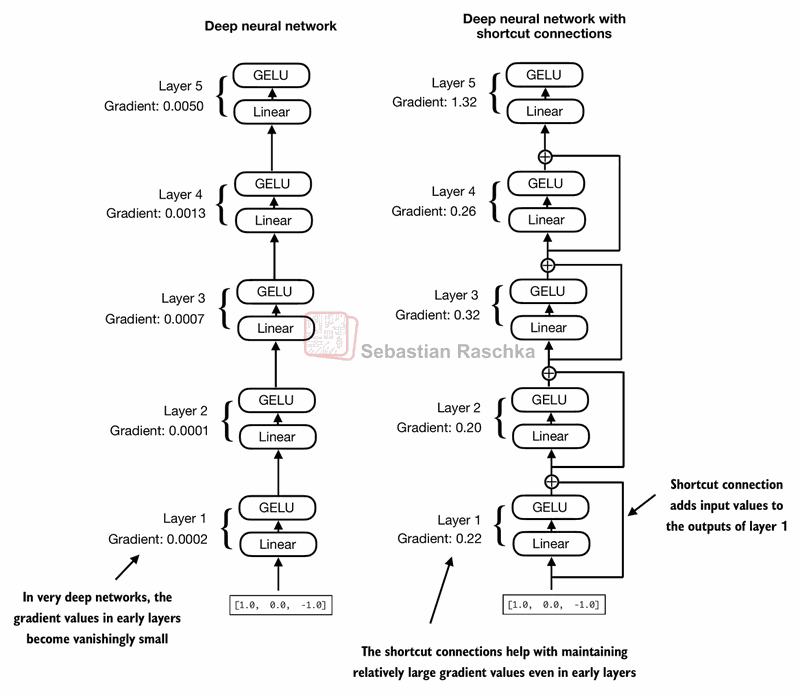

- Em código, fica assim:

> 🇧🇷 **O que esta célula faz:** Define uma rede profunda de exemplo com cinco camadas, com ou sem shortcut connections, e uma função que imprime a média dos gradientes de cada camada.

In [109]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ])

    def forward(self, x):
        for layer in self.layers:
            # Compute the output of the current layer
            layer_output = layer(x)
            # Check if shortcut can be applied
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x


def print_gradients(model, x):
    # Forward pass
    output = model(x)
    target = torch.tensor([[0.]])

    # Calculate loss based on how close the target
    # and output are
    loss = nn.MSELoss()
    loss = loss(output, target)
    
    # Backward pass to calculate the gradients
    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            # Print the mean absolute gradient of the weights
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

- Vamos primeiro imprimir os valores dos gradientes **sem** shortcut connections:

> 🇧🇷 **O que esta célula faz:** Calcula os gradientes da rede sem shortcut connections: eles ficam minúsculos nas primeiras camadas, sinal de desaparecimento do gradiente.

In [110]:
layer_sizes = [3, 3, 3, 3, 3, 1]  

sample_input = torch.tensor([[1., 0., -1.]])

torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=False
)
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173584925942123
layers.1.0.weight has gradient mean of 0.00012011159560643137
layers.2.0.weight has gradient mean of 0.0007152040489017963
layers.3.0.weight has gradient mean of 0.0013988736318424344
layers.4.0.weight has gradient mean of 0.005049645435065031


- Em seguida, vamos imprimir os valores dos gradientes **com** shortcut connections:

> 🇧🇷 **O que esta célula faz:** Calcula os gradientes da mesma rede com shortcut connections: agora eles permanecem em um tamanho saudável em todas as camadas.

In [111]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=True
)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169791162014008
layers.1.0.weight has gradient mean of 0.20694105327129364
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258540630340576


- Como podemos ver pela saída acima, as shortcut connections impedem que os gradientes desapareçam nas camadas iniciais (em direção a `layer.0`)
- Usaremos esse conceito de shortcut connection a seguir, quando implementarmos um transformer block

## 3.5 Conectando atenção e camadas lineares em um transformer block

- Nesta seção, combinamos os conceitos anteriores no chamado transformer block
- Um transformer block combina o módulo de atenção multi-head causal da parte anterior com as camadas lineares, isto é, a rede neural feed forward que implementamos em uma seção anterior
- Além disso, o transformer block também usa dropout e shortcut connections

> 🇧🇷 **O que esta célula faz:** Monta o transformer block, reaproveitando a atenção multi-head construída na parte 2 e combinando-a com LayerNorm, FeedForward, dropout e shortcut connections.

In [112]:
from suporte.partes_anteriores_p3 import MultiHeadAttention


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], 
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x

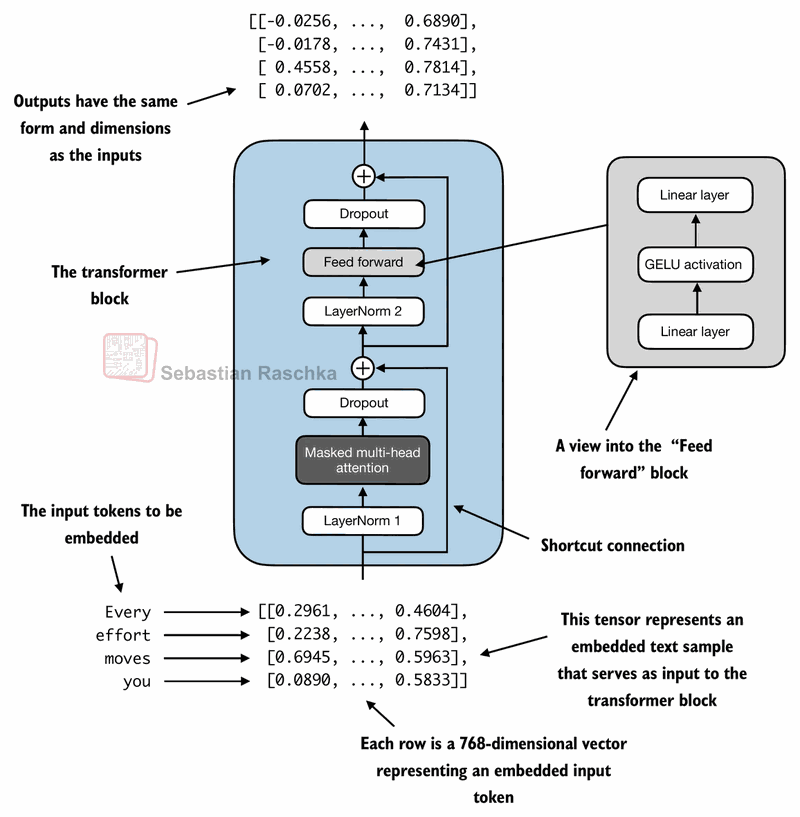

- Suponha que temos 2 amostras de entrada com 6 tokens cada, em que cada token é um vetor de embedding de 768 dimensões; então este transformer block aplica self-attention (autoatenção), seguida de camadas lineares, para produzir uma saída de tamanho semelhante
- Você pode pensar na saída como uma versão aprimorada dos vetores de contexto que discutimos na parte anterior

> 🇧🇷 **O que esta célula faz:** Passa um tensor aleatório por um transformer block; a saída tem o mesmo formato da entrada, [2, 4, 768].

In [113]:
torch.manual_seed(123)

x = torch.rand(2, 4, 768)  # Shape: [batch_size, num_tokens, emb_dim]
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


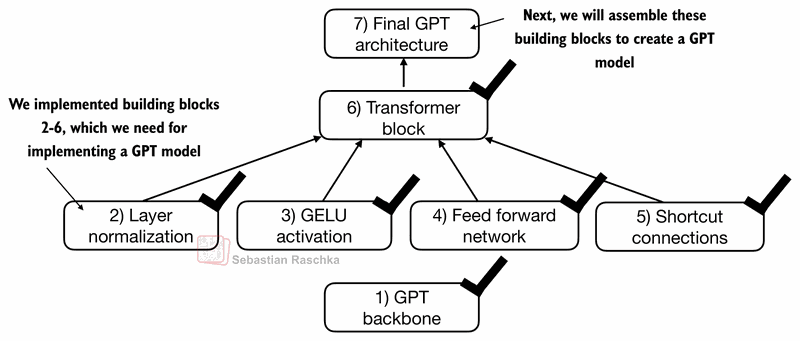

## 3.6 Codificando o modelo GPT

- Estamos quase lá: agora vamos encaixar o transformer block na arquitetura que codificamos bem no início desta parte, para obter uma arquitetura GPT utilizável
- Observe que o transformer block se repete várias vezes; no caso do menor modelo GPT-2, de 124M, ele é repetido 12 vezes:

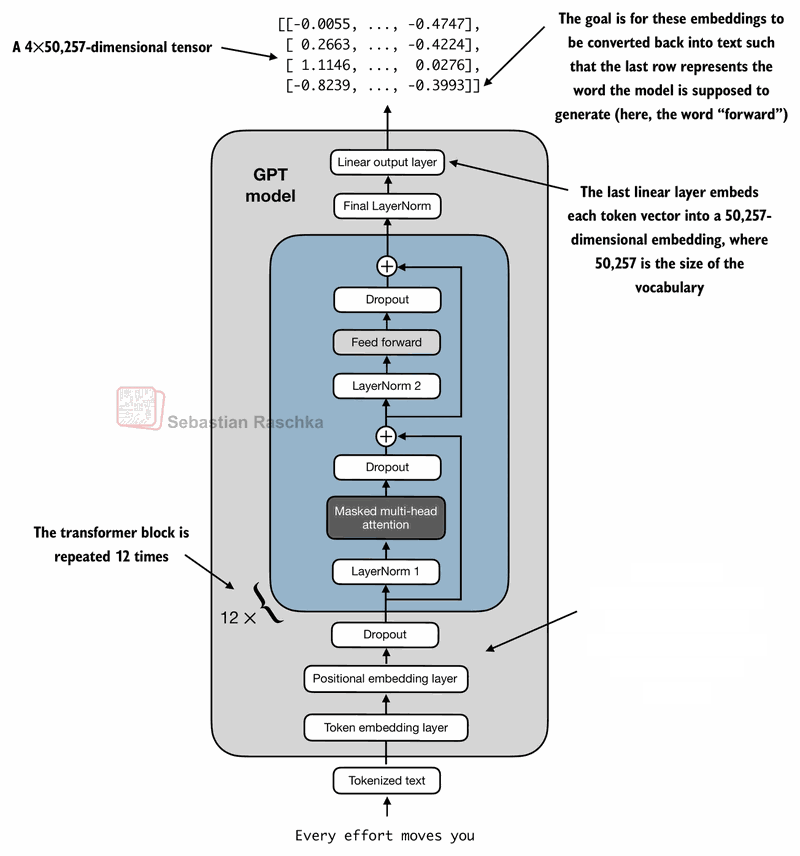

- A implementação em código correspondente, em que `cfg["n_layers"] = 12`:

> 🇧🇷 **O que esta célula faz:** Implementa o modelo GPT completo: embeddings de tokens e de posição, 12 transformer blocks empilhados, LayerNorm final e camada de saída.

In [114]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

- Usando a configuração do modelo de 124M de parâmetros, podemos agora instanciar este modelo GPT com pesos iniciais aleatórios da seguinte forma:

> 🇧🇷 **O que esta célula faz:** Cria o modelo GPT com pesos aleatórios e processa o lote de exemplo; a saída tem formato [2, 4, 50257], com os logits de cada token.

In [115]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

out = model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.1381,  0.0077, -0.1963,  ..., -0.0222, -0.1060,  0.1717],
         [ 0.3865, -0.8408, -0.6564,  ..., -0.5163,  0.2369, -0.3357],
         [ 0.6989, -0.1829, -0.1631,  ...,  0.1472, -0.6504, -0.0056],
         [-0.4290,  0.1669, -0.1258,  ...,  1.1579,  0.5303, -0.5549]],

        [[ 0.1094, -0.2894, -0.1467,  ..., -0.0557,  0.2911, -0.2824],
         [ 0.0882, -0.3552, -0.3527,  ...,  1.2930,  0.0053,  0.1898],
         [ 0.6091,  0.4702, -0.4094,  ...,  0.7688,  0.3787, -0.1974],
         [-0.0612, -0.0737,  0.4751,  ...,  1.2463, -0.3834,  0.0609]]],
       grad_fn=<UnsafeViewBackward0>)


- Vamos treinar este modelo na próxima parte
- Mas, antes, uma observação rápida sobre o seu tamanho: nós nos referimos a ele como um modelo de 124M de parâmetros; podemos conferir esse número da seguinte forma:

> 🇧🇷 **O que esta célula faz:** Conta o total de parâmetros do modelo: cerca de 163 milhões.

In [116]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 163,009,536


- Como vemos acima, este modelo tem 163M de parâmetros, e não 124M; por quê?
- No artigo original do GPT-2, os pesquisadores aplicaram weight tying (compartilhamento de pesos), o que significa que reutilizaram a camada de embedding de tokens (`tok_emb`) como camada de saída, ou seja, definiram `self.out_head.weight = self.tok_emb.weight`
- A camada de embedding de tokens projeta os tokens de entrada, codificados em one-hot com 50.257 dimensões, em uma representação de embedding de 768 dimensões
- A camada de saída projeta os embeddings de 768 dimensões de volta para uma representação de 50.257 dimensões, para que possamos convertê-los de volta em palavras (mais sobre isso na próxima seção)
- Assim, a camada de embedding e a camada de saída têm o mesmo número de parâmetros de peso, como podemos ver pelo formato de suas matrizes de pesos: a próxima parte
- Mas, antes, uma observação rápida sobre o seu tamanho: nós nos referimos a ele como um modelo de 124M de parâmetros; podemos conferir esse número da seguinte forma:

> 🇧🇷 **O que esta célula faz:** Mostra que a camada de embedding de tokens e a camada de saída têm matrizes de pesos do mesmo formato, [50257, 768].

In [117]:
print("Token embedding layer shape:", model.tok_emb.weight.shape)
print("Output layer shape:", model.out_head.weight.shape)

Token embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])


- No artigo original do GPT-2, os pesquisadores reutilizaram a matriz de embedding de tokens como matriz de saída
- Da mesma forma, se subtrairmos o número de parâmetros da camada de saída, obteremos um modelo de 124M de parâmetros:

> 🇧🇷 **O que esta célula faz:** Desconta os parâmetros da camada de saída (como no weight tying do GPT-2) e chega a cerca de 124 milhões de parâmetros.

In [118]:
total_params_gpt2 =  total_params - sum(p.numel() for p in model.out_head.parameters())
print(f"Number of trainable parameters considering weight tying: {total_params_gpt2:,}")

Number of trainable parameters considering weight tying: 124,412,160


- Na prática, achei mais fácil treinar o modelo sem weight tying, e é por isso que não o implementamos aqui
- No entanto, vamos retomar e aplicar essa ideia de weight tying mais tarde, quando carregarmos os pesos pré-treinados na parte 5
- Por fim, podemos calcular os requisitos de memória do modelo da seguinte forma, o que pode ser um ponto de referência útil:

> 🇧🇷 **O que esta célula faz:** Estima a memória ocupada pelo modelo em float32: cerca de 622 MB.

In [119]:
# Calculate the total size in bytes (assuming float32, 4 bytes per parameter)
total_size_bytes = total_params * 4

# Convert to megabytes
total_size_mb = total_size_bytes / (1024 * 1024)

print(f"Total size of the model: {total_size_mb:.2f} MB")

Total size of the model: 621.83 MB


- Exercício: você também pode experimentar as seguintes configurações, citadas no [artigo do GPT-2](https://d4mucfpksywv.cloudfront.net/better-language-models/language_models_are_unsupervised_multitask_learners.pdf).

    - **GPT2-small** (a configuração de 124M que já implementamos):
        - "emb_dim" = 768
        - "n_layers" = 12
        - "n_heads" = 12

    - **GPT2-medium:**
        - "emb_dim" = 1024
        - "n_layers" = 24
        - "n_heads" = 16
    
    - **GPT2-large:**
        - "emb_dim" = 1280
        - "n_layers" = 36
        - "n_heads" = 20
    
    - **GPT2-XL:**
        - "emb_dim" = 1600
        - "n_layers" = 48
        - "n_heads" = 25

## 3.7 Gerando texto

- LLMs como o modelo GPT que implementamos acima são usados para gerar uma palavra de cada vez

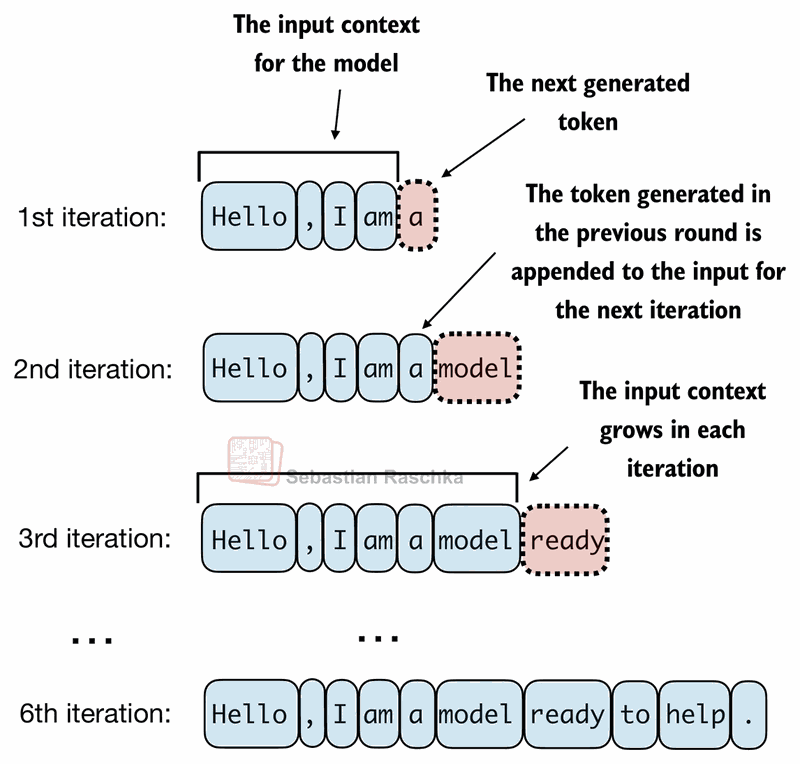

- A função `generate_text_simple` a seguir implementa a greedy decoding (decodificação gulosa), um método simples e rápido para gerar texto
- Na greedy decoding, a cada passo, o modelo escolhe a palavra (ou token) com a maior probabilidade como sua próxima saída (o maior logit corresponde à maior probabilidade, então tecnicamente nem precisaríamos calcular a função softmax explicitamente)
- Na próxima parte, implementaremos uma função `generate_text` mais avançada
- A figura abaixo mostra como o modelo GPT, dado um contexto de entrada, gera o próximo token

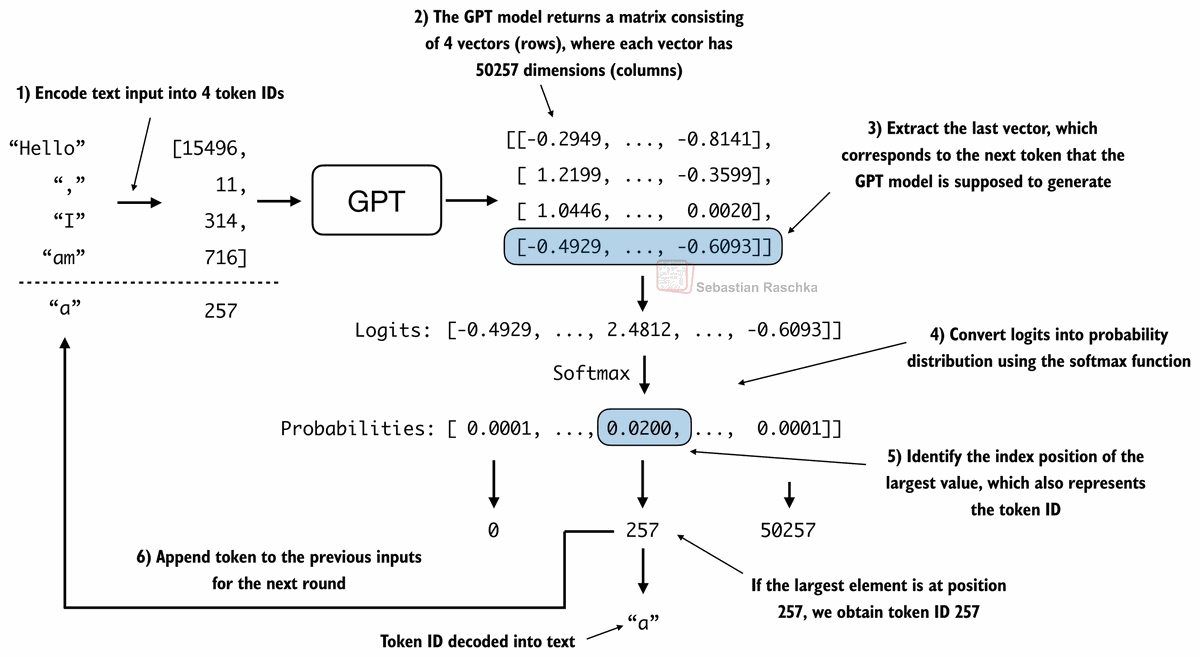

> 🇧🇷 **O que esta célula faz:** Implementa a geração de texto gulosa: a cada passo, o modelo prevê o próximo token mais provável e o acrescenta à sequência.

In [120]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (batch, n_tokens) array of indices in the current context
    for _ in range(max_new_tokens):
        
        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]
        
        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)
        
        # Focus only on the last time step
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]  

        # Apply softmax to get probabilities
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)

        # Get the idx of the vocab entry with the highest probability value
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

- A função `generate_text_simple` acima implementa um processo iterativo, no qual cria um token de cada vez

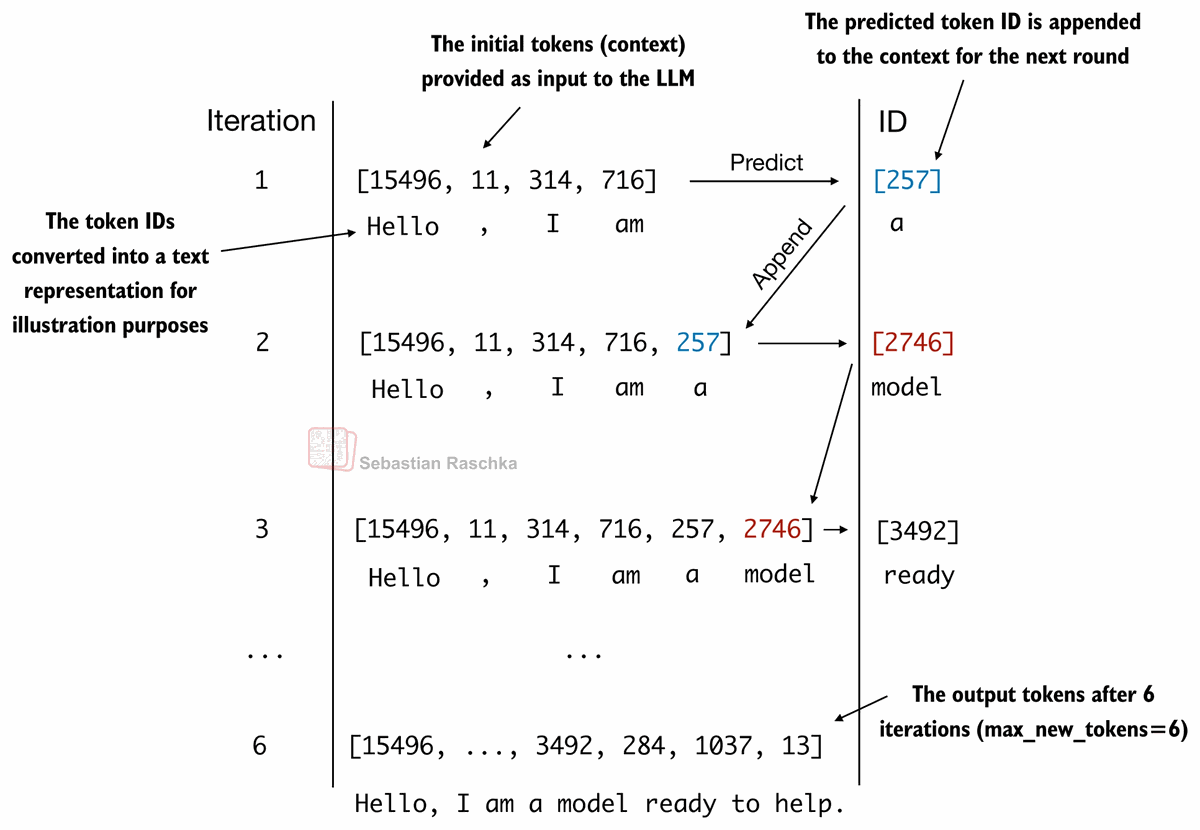

- Vamos preparar um exemplo de entrada:

> 🇧🇷 **O que esta célula faz:** Codifica a frase inicial "Hello, I am" em IDs de tokens e adiciona a dimensão de batch.

In [121]:
start_context = "Hello, I am"

encoded = tokenizer.encode(start_context)
print("encoded:", encoded)

encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:", encoded_tensor.shape)

encoded: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


> 🇧🇷 **O que esta célula faz:** Coloca o modelo em modo de avaliação e gera 6 novos tokens a partir da frase inicial; a sequência passa de 4 para 10 tokens.

In [122]:
model.eval() # disable dropout

out = generate_text_simple(
    model=model,
    idx=encoded_tensor, 
    max_new_tokens=6, 
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output:", out)
print("Output length:", len(out[0]))

Output: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
Output length: 10


- Removemos a dimensão de batch e convertemos de volta para texto:

> 🇧🇷 **O que esta célula faz:** Converte os IDs gerados de volta em texto; como o modelo ainda não foi treinado, as palavras adicionadas não fazem sentido.

In [123]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am Featureiman Byeswickattribute argue


- Observe que o modelo não foi treinado; por isso os textos de saída aleatórios acima
- Vamos treinar o modelo na próxima parte

# Parte 4 — Pré-treinamento com dados não rotulados

Nesta parte, fazemos o **pretraining** (pré-treinamento) do modelo GPT que construímos na parte 3. Até aqui, o modelo tinha a arquitetura completa, mas pesos aleatórios, e gerava apenas texto sem sentido.

Vamos medir a qualidade das previsões com a **cross entropy loss** e a **perplexity**, treinar o modelo em um conto curto e acompanhar a queda das losses de treino e de validação. Em seguida, veremos estratégias de decodificação (**temperature scaling** e **top-k sampling**) para controlar a aleatoriedade do texto gerado, aprenderemos a salvar e carregar pesos e, por fim, carregaremos os pesos oficiais do GPT-2 da OpenAI no nosso próprio modelo, que passa a gerar texto coerente.

> 🇧🇷 **O que esta célula faz:** Mostra as versões das bibliotecas usadas nesta parte (matplotlib, NumPy, tiktoken, PyTorch e TensorFlow).

In [124]:
from importlib.metadata import version

pkgs = ["matplotlib", 
        "numpy", 
        "tiktoken", 
        "torch",
        "tensorflow" # For OpenAI's pretrained weights
       ]
for p in pkgs:
    print(f"{p} version: {version(p)}")

matplotlib version: 3.8.4
numpy version: 1.26.4
tiktoken version: 0.7.0
torch version: 2.3.1
tensorflow version: 2.8.0


- Nesta parte, implementamos o loop de treinamento e o código de avaliação básica do modelo para fazer o pretraining (pré-treinamento) de um LLM
- Ao final da parte, também carregamos no nosso modelo os pesos pré-treinados que a OpenAI disponibilizou abertamente

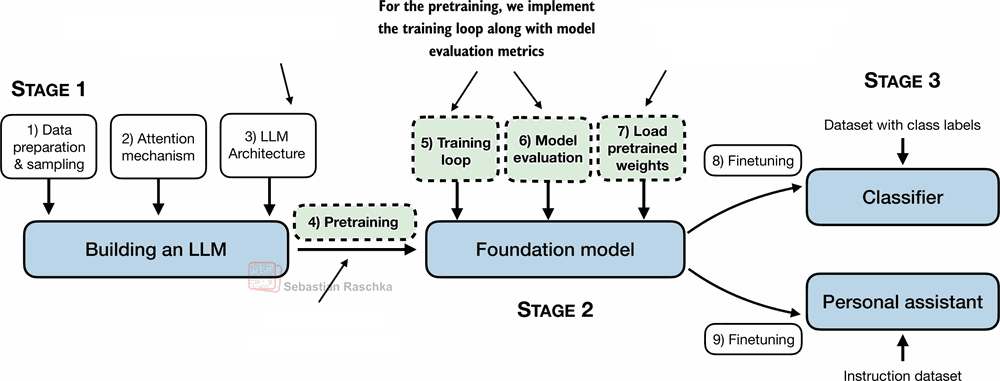

- Os tópicos abordados nesta parte são mostrados abaixo

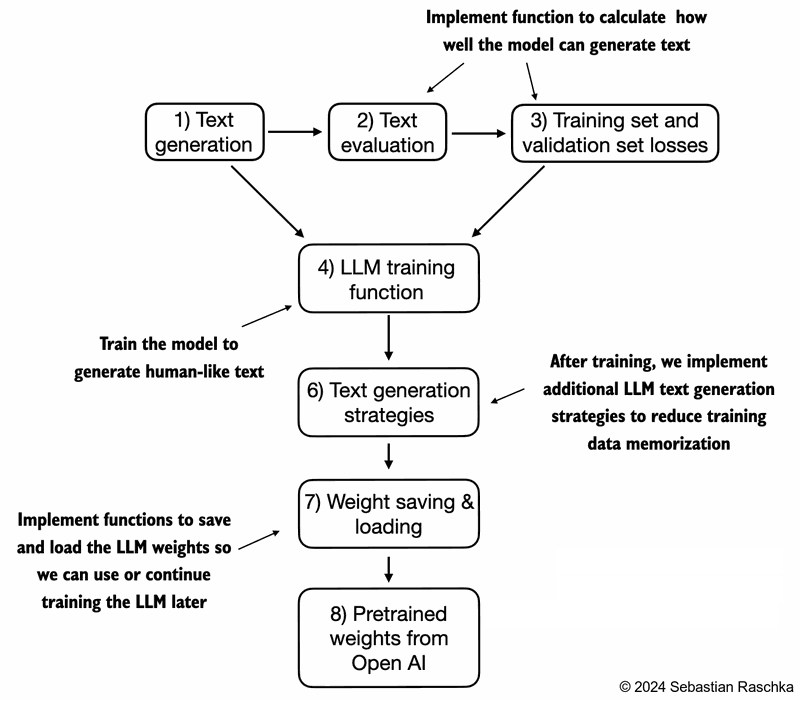

## 4.1 Avaliando modelos generativos de texto

- Começamos esta seção com uma breve recapitulação de como inicializar um modelo GPT usando o código da parte anterior
- Em seguida, discutimos métricas básicas de avaliação para LLMs
- Por fim, nesta seção, aplicamos essas métricas de avaliação a um conjunto de treino e a um conjunto de validação

### 4.1.1 Usando o GPT para gerar texto

- Inicializamos um modelo GPT usando o código da parte anterior

> 🇧🇷 **O que esta célula faz:** Reaproveita o modelo GPT da parte 3 e cria uma instância com a configuração de 124 milhões de parâmetros, com contexto reduzido para 256 tokens.

In [125]:
import torch
from suporte.partes_anteriores_p4 import GPTModel

GPT_CONFIG_124M = {
    "vocab_size": 50257,   # Vocabulary size
    "context_length": 256, # Shortened context length (orig: 1024)
    "emb_dim": 768,        # Embedding dimension
    "n_heads": 12,         # Number of attention heads
    "n_layers": 12,        # Number of layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": False      # Query-key-value bias
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval();  # Disable dropout during inference

- Usamos acima um dropout de 0,1, mas hoje em dia é relativamente comum treinar LLMs sem dropout
- LLMs modernos também não usam vetores de bias nas camadas `nn.Linear` das matrizes de query, key e value (ao contrário dos primeiros modelos GPT), o que conseguimos definindo `"qkv_bias": False`
- Reduzimos o comprimento de contexto (`context_length`) para apenas 256 tokens, a fim de diminuir os recursos computacionais necessários para treinar o modelo, enquanto o modelo GPT-2 original de 124 milhões de parâmetros usava 1024 tokens
  - Assim, mais leitores conseguirão acompanhar e executar os exemplos de código em seus notebooks (laptops)
  - Porém, fique à vontade para aumentar o `context_length` para 1024 tokens (isso não exige nenhuma alteração no código)
  - Mais adiante, também vamos carregar, a partir de pesos pré-treinados, um modelo com `context_length` de 1024

- Em seguida, usamos a função `generate_text_simple` da parte anterior para gerar texto
- Além disso, definimos duas funções auxiliares, `text_to_token_ids` e `token_ids_to_text`, para converter entre as representações em tokens e em texto; vamos usá-las ao longo de todo esta parte

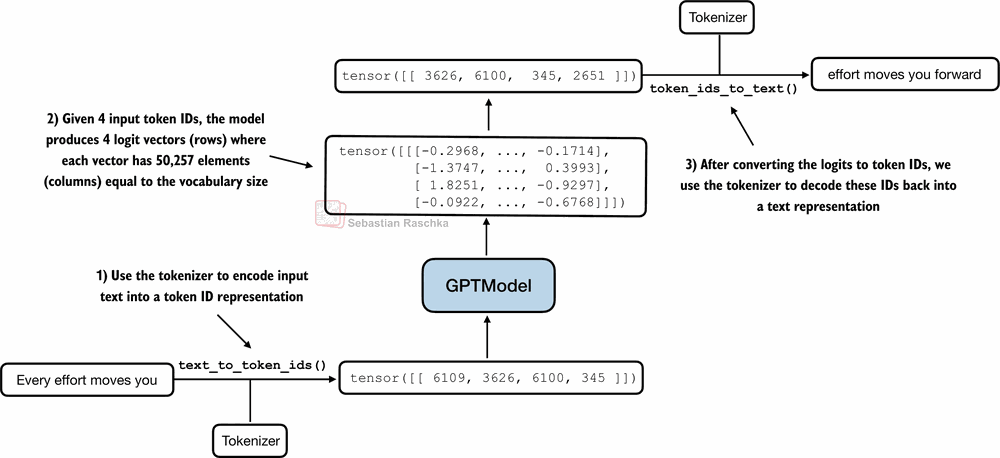

> 🇧🇷 **O que esta célula faz:** Define funções para converter texto em IDs de tokens e vice-versa e gera 10 tokens a partir de "Every effort moves you"; como o modelo ainda não foi treinado, a saída é um amontoado sem sentido.

In [126]:
import tiktoken
from suporte.partes_anteriores_p4 import generate_text_simple

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


- Como vemos acima, o modelo não produz um texto bom porque ainda não foi treinado
- Como medir ou capturar, de forma numérica, o que é um "texto bom", para acompanhá-lo durante o treinamento?
- A próxima subseção apresenta métricas para calcular uma loss (perda) das saídas geradas, que podemos usar para medir o progresso do treinamento
- As próximas partes, sobre finetuning (ajuste fino) de LLMs, também vão apresentar outras formas de medir a qualidade do modelo

<br>

### 4.1.2 Calculando a loss da geração de texto: cross entropy e perplexity

- Suponha que temos um tensor `inputs` contendo os IDs de tokens de 2 exemplos de treino (linhas)
- Correspondendo aos `inputs`, os `targets` contêm os IDs de tokens desejados, que queremos que o modelo gere
- Observe que os `targets` são os `inputs` deslocados em 1 posição, como explicado na parte 1 quando implementamos o data loader

> 🇧🇷 **O que esta célula faz:** Cria dois exemplos de entrada e os respectivos alvos, que são as mesmas sequências deslocadas em uma posição.

In [127]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [588,  428,  11311]]) #  " really like chocolate"]

- Ao passar os `inputs` pelo modelo, obtemos o vetor de logits para os 2 exemplos de entrada, que têm 3 tokens cada
- Cada token é um vetor de 50.257 dimensões, correspondente ao tamanho do vocabulário
- Aplicando a função softmax, podemos transformar o tensor de logits em um tensor de mesma dimensão contendo scores de probabilidade

> 🇧🇷 **O que esta célula faz:** Passa as entradas pelo modelo e converte os logits em probabilidades com softmax; o formato mostra 2 exemplos, 3 tokens e 50.257 posições do vocabulário.

In [128]:
with torch.no_grad():
    logits = model(inputs)

probas = torch.softmax(logits, dim=-1) # Probability of each token in vocabulary
print(probas.shape) # Shape: (batch_size, num_tokens, vocab_size)

torch.Size([2, 3, 50257])


- A figura abaixo, que usa um vocabulário bem pequeno para fins de ilustração, resume como convertemos os scores de probabilidade de volta em texto, algo que discutimos no final da parte anterior

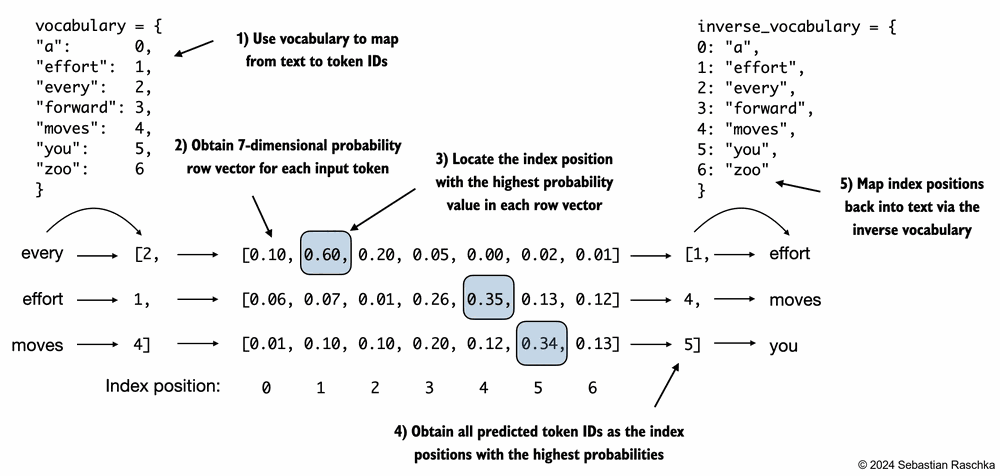

- Como discutido na parte anterior, podemos aplicar a função `argmax` para converter os scores de probabilidade em IDs de tokens previstos
- A função softmax acima produziu um vetor de 50.257 dimensões para cada token; a função `argmax` retorna a posição do maior score de probabilidade nesse vetor, que é o ID do token previsto para aquele token

- Como temos 2 batches de entrada com 3 tokens cada, obtemos 2 por 3 IDs de tokens previstos:

> 🇧🇷 **O que esta célula faz:** Escolhe, para cada posição, o token de maior probabilidade, obtendo os IDs previstos pelo modelo.

In [129]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs:\n", token_ids)

Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


- Se decodificarmos esses tokens, veremos que eles são bem diferentes dos tokens que queremos que o modelo preveja, ou seja, os tokens-alvo (targets):

> 🇧🇷 **O que esta célula faz:** Compara o texto-alvo com o texto previsto pelo modelo não treinado: as duas sequências não têm nada a ver uma com a outra.

In [130]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


- Isso acontece porque o modelo ainda não foi treinado
- Para treinar o modelo, precisamos saber o quão longe ele está das previsões corretas (targets)

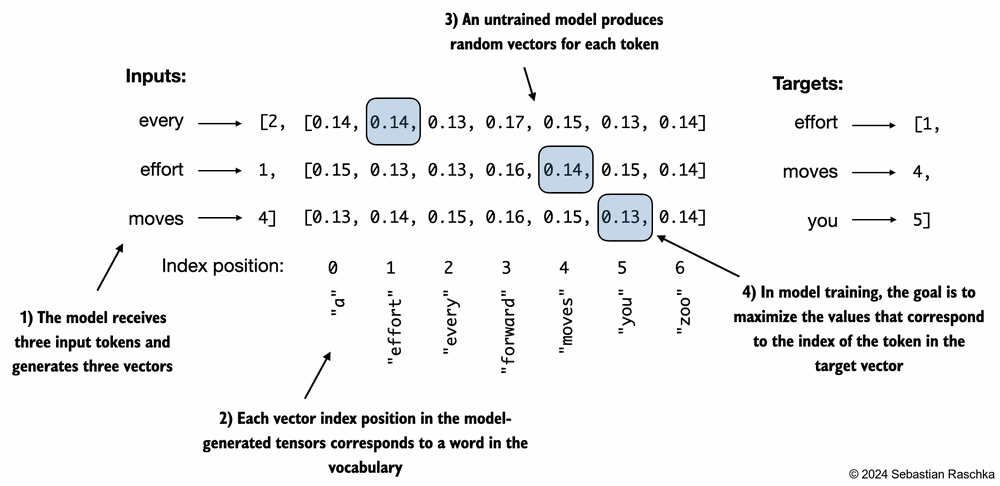

- As probabilidades dos tokens correspondentes aos índices-alvo são as seguintes:

> 🇧🇷 **O que esta célula faz:** Extrai as probabilidades que o modelo atribuiu aos tokens corretos; todas são minúsculas, da ordem de 0,00001.

In [131]:
text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([7.4540e-05, 3.1061e-05, 1.1563e-05])
Text 2: tensor([3.9836e-05, 1.6783e-05, 4.7559e-06])


- Queremos maximizar todos esses valores, aproximando-os de uma probabilidade de 1
- Em otimização matemática, é mais fácil maximizar o logaritmo do score de probabilidade do que o próprio score; isso está fora do escopo deste notebook, mas gravei uma aula com mais detalhes aqui: L8.2 Logistic Regression Loss Function, [https://www.youtube.com/watch?v=GxJe0DZvydM](https://www.youtube.com/watch?v=GxJe0DZvydM)

> 🇧🇷 **O que esta célula faz:** Calcula o logaritmo dessas probabilidades, obtendo valores negativos em torno de -10.

In [132]:
# Compute logarithm of all token probabilities
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -10.1307, -10.9951, -12.2561])


- Em seguida, calculamos a média do log das probabilidades (log-probabilidade média):

> 🇧🇷 **O que esta célula faz:** Calcula a média das log-probabilidades, cerca de -10,77.

In [133]:
# Calculate the average probability for each token
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.7722)


- O objetivo é tornar essa log-probabilidade média a maior possível, otimizando os pesos do modelo
- Por causa do log, o maior valor possível é 0, e no momento estamos bem longe de 0

- Em deep learning, em vez de maximizar a log-probabilidade média, a convenção padrão é minimizar o valor *negativo* da log-probabilidade média; no nosso caso, em vez de maximizar -10,7722 para que se aproxime de 0, em deep learning minimizaríamos 10,7722 para que se aproxime de 0
- O negativo de -10,7722, ou seja, 10,7722, também é chamado de cross entropy loss (perda de entropia cruzada) em deep learning

> 🇧🇷 **O que esta célula faz:** Inverte o sinal da média, obtendo 10,77: esse valor é a cross entropy loss.

In [134]:
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor(10.7722)


- O PyTorch já implementa uma função `cross_entropy` que executa os passos anteriores

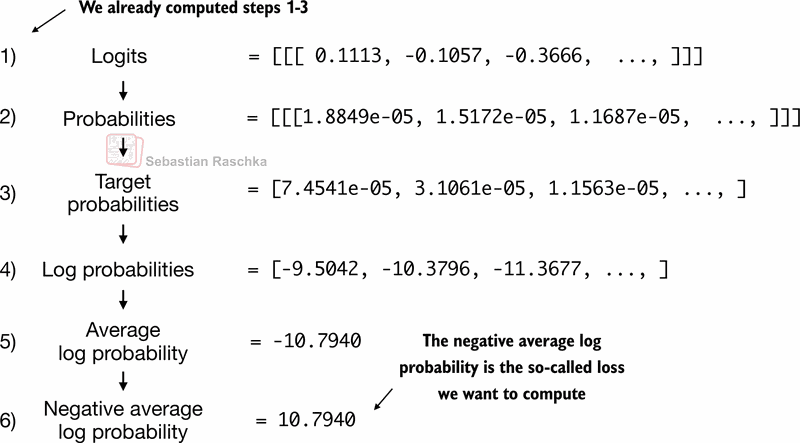

- Antes de aplicar a função de cross entropy, vamos verificar o formato (shape) dos logits e dos targets

> 🇧🇷 **O que esta célula faz:** Mostra o formato dos logits (batch, tokens, vocabulário) e dos alvos (batch, tokens).

In [135]:
# Logits have shape (batch_size, num_tokens, vocab_size)
print("Logits shape:", logits.shape)

# Targets have shape (batch_size, num_tokens)
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


- Para a função `cross_entropy` do PyTorch, queremos achatar (flatten) esses tensores, combinando-os ao longo da dimensão do batch:

> 🇧🇷 **O que esta célula faz:** Achata os tensores, juntando as dimensões de batch e tokens, no formato que a função de cross entropy do PyTorch espera.

In [136]:
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()

print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


- Observe que os targets são os IDs dos tokens, que também representam as posições de índice nos tensores de logits que queremos maximizar
- A função `cross_entropy` do PyTorch cuida automaticamente de aplicar internamente a softmax e o cálculo da log-probabilidade sobre os índices de tokens dos logits que devem ser maximizados

> 🇧🇷 **O que esta célula faz:** Calcula a cross entropy com a função pronta do PyTorch e obtém o mesmo valor de 10,77 calculado passo a passo.

In [137]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.7722)


- Um conceito relacionado à cross entropy loss é a perplexity (perplexidade) de um LLM
- A perplexity é simplesmente a exponencial da cross entropy loss

> 🇧🇷 **O que esta célula faz:** Calcula a perplexity como a exponencial da loss: cerca de 47.679, ou seja, o modelo está tão incerto quanto se escolhesse entre dezenas de milhares de tokens.

In [138]:
perplexity = torch.exp(loss)
print(perplexity)

tensor(47678.8633)


- A perplexity costuma ser considerada mais interpretável porque pode ser entendida como o tamanho efetivo do vocabulário sobre o qual o modelo está incerto a cada passo (no exemplo acima, seriam 47.678 palavras ou tokens)
- Em outras palavras, a perplexity fornece uma medida de quão bem a distribuição de probabilidade prevista pelo modelo corresponde à distribuição real das palavras no dataset
- Assim como a loss, uma perplexity menor indica que as previsões do modelo estão mais próximas da distribuição real

### 4.1.3 Calculando as losses dos conjuntos de treino e de validação

- Usamos um dataset relativamente pequeno para treinar o LLM (na verdade, apenas um conto)
- Os motivos são:
  - Você consegue executar os exemplos de código em poucos minutos em um notebook (laptop) sem uma GPU adequada
  - O treinamento termina de forma relativamente rápida (minutos em vez de semanas), o que é bom para fins didáticos
  - Usamos um texto de domínio público, que pode ser incluído neste repositório do GitHub sem violar direitos de uso nem inflar o tamanho do repositório


- Por exemplo, o Llama 2 7B exigiu 184.320 horas de GPU em GPUs A100 para ser treinado em 2 trilhões de tokens
  - No momento em que este texto foi escrito, o custo por hora de um servidor em nuvem 8xA100 na AWS era de aproximadamente \\$30
  - Assim, fazendo uma conta de guardanapo, treinar esse LLM custaria 184.320 / 8 * \\$30 =  \\$690.000

- A seguir, usamos o mesmo dataset que usamos na parte 1

> 🇧🇷 **O que esta célula faz:** Baixa o conto "The Verdict", de Edith Wharton, que será o texto de treino, ou o lê do disco se já estiver salvo.

In [139]:
import os
import urllib.request

file_path = "dados/the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

if not os.path.exists(file_path):
    with urllib.request.urlopen(url) as response:
        text_data = response.read().decode('utf-8')
    with open(file_path, "w", encoding="utf-8") as file:
        file.write(text_data)
else:
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()

- Uma verificação rápida de que o texto foi carregado corretamente, imprimindo os primeiros e os últimos 100 caracteres

> 🇧🇷 **O que esta célula faz:** Mostra os primeiros caracteres do conto para conferir que o texto foi carregado.

In [140]:
# First 100 characters
print(text_data[:99])

I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


> 🇧🇷 **O que esta célula faz:** Mostra os últimos caracteres do conto.

In [141]:
# Last 100 characters
print(text_data[-99:])

it for me! The Strouds stand alone, and happen once--but there's no exterminating our kind of art."


> 🇧🇷 **O que esta célula faz:** Conta caracteres e tokens do texto: cerca de 20 mil caracteres e apenas 5.145 tokens.

In [142]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


- Com 5.145 tokens, o texto é curtíssimo para treinar um LLM, mas, novamente, o objetivo é didático (mais adiante também vamos carregar pesos pré-treinados)

- Em seguida, dividimos o dataset em um conjunto de treino e um de validação e usamos os data loaders da parte 1 para preparar os batches para o treinamento do LLM
- Para fins de visualização, a figura abaixo assume `max_length=6`, mas, para o loader de treino, definimos `max_length` igual ao comprimento de contexto suportado pelo LLM
- Por simplicidade, a figura abaixo mostra apenas os tokens de entrada
    - Como treinamos o LLM para prever a próxima palavra do texto, os targets são iguais a essas entradas, exceto por estarem deslocados em uma posição

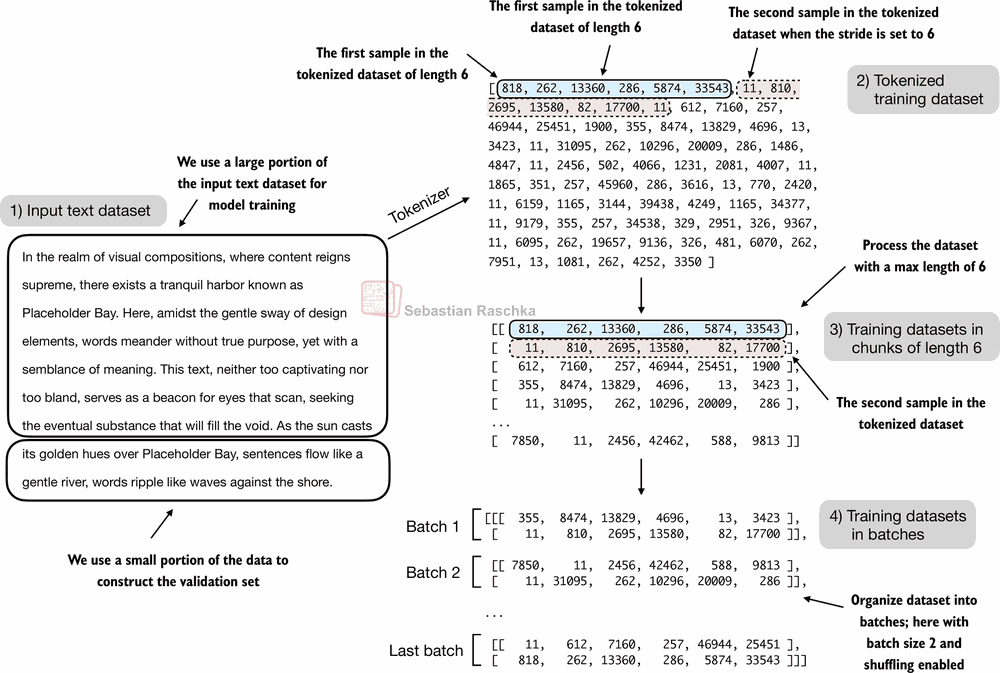

> 🇧🇷 **O que esta célula faz:** Separa 90% do texto para treino e 10% para validação e cria os data loaders com sequências do tamanho do contexto.

In [143]:
from suporte.partes_anteriores_p4 import create_dataloader_v1

# Train/validation ratio
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]


torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

> 🇧🇷 **O que esta célula faz:** Confere se há tokens suficientes para formar pelo menos uma sequência em cada conjunto; não imprime nada quando está tudo certo.

In [144]:
# Sanity check

if total_tokens * (train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the training loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "increase the `training_ratio`")

if total_tokens * (1-train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the validation loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "decrease the `training_ratio`")

- Usamos um batch size relativamente pequeno para reduzir a demanda de recursos computacionais e porque o dataset já é muito pequeno
- O Llama 2 7B, por exemplo, foi treinado com batch size de 1024

- Uma verificação opcional de que os dados foram carregados corretamente:

> 🇧🇷 **O que esta célula faz:** Percorre os data loaders e mostra o formato de cada batch: 9 batches de treino e 1 de validação, com 2 sequências de 256 tokens.

In [145]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


- Outra verificação opcional de que a quantidade de tokens está dentro do esperado:

> 🇧🇷 **O que esta célula faz:** Soma os tokens de cada conjunto: 4.608 para treino e 512 para validação.

In [146]:
train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens:", train_tokens + val_tokens)

Training tokens: 4608
Validation tokens: 512
All tokens: 5120


- Em seguida, implementamos uma função utilitária para calcular a cross entropy loss de um batch
- Além disso, implementamos uma segunda função utilitária para calcular a loss sobre um número de batches de um data loader especificado pelo usuário

> 🇧🇷 **O que esta célula faz:** Define funções que calculam a cross entropy loss de um batch e a loss média sobre vários batches de um data loader.

In [147]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

- Se você tem uma máquina com GPU compatível com CUDA, o LLM será treinado na GPU sem nenhuma alteração no código
- Por meio da configuração `device`, garantimos que os dados sejam carregados no mesmo dispositivo que o modelo LLM

> 🇧🇷 **O que esta célula faz:** Escolhe GPU ou CPU e calcula as losses iniciais de treino e validação, ambas perto de 11, típicas de um modelo sem treino.

In [148]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes


torch.manual_seed(123) # For reproducibility due to the shuffling in the data loader

with torch.no_grad(): # Disable gradient tracking for efficiency because we are not training, yet
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 10.987583584255642
Validation loss: 10.98110580444336


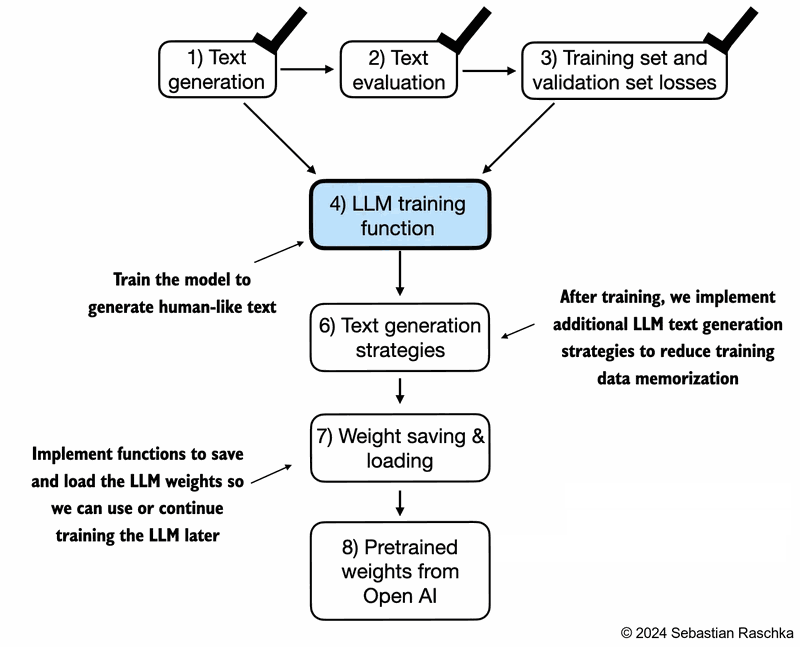

## 4.2 Treinando um LLM

- Nesta seção, finalmente implementamos o código para treinar o LLM
- Focamos em uma função de treinamento simples (se tiver interesse em incrementar essa função com técnicas mais avançadas, como learning rate warmup, cosine annealing e gradient clipping, consulte o [repositório LLMs-from-scratch](https://github.com/rasbt/LLMs-from-scratch))

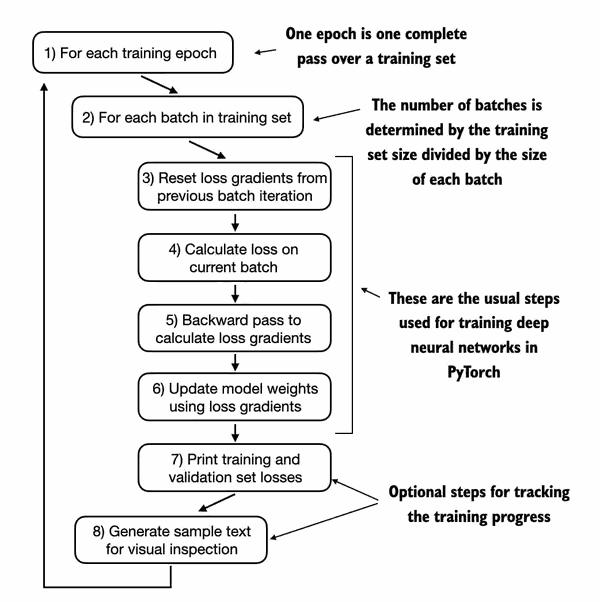

> 🇧🇷 **O que esta célula faz:** Define a função de treinamento: a cada batch, calcula a loss, os gradientes e atualiza os pesos; periodicamente avalia as losses e, ao fim de cada época, gera um texto de exemplo.

In [149]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode
        
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous epoch
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel()
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen


def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
        decoded_text = token_ids_to_text(token_ids, tokenizer)
        print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

- Agora, vamos treinar o LLM usando a função de treinamento definida acima:

> 🇧🇷 **O que esta célula faz:** Treina o modelo por 10 épocas com o otimizador AdamW; a loss de treino cai de quase 10 para menos de 1, e o texto gerado passa de vírgulas soltas a frases do conto.

In [150]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 9.816, Val loss 9.924
Ep 1 (Step 000005): Train loss 8.069, Val loss 8.337
Every effort moves you,.                                                
Ep 2 (Step 000010): Train loss 6.623, Val loss 7.051
Ep 2 (Step 000015): Train loss 6.045, Val loss 6.601
Every effort moves you, and,, and,, and,,,, and,.                                   
Ep 3 (Step 000020): Train loss 5.528, Val loss 6.523
Ep 3 (Step 000025): Train loss 5.382, Val loss 6.392
Every effort moves you.                                                 
Ep 4 (Step 000030): Train loss 4.865, Val loss 6.260
Ep 4 (Step 000035): Train loss 4.635, Val loss 6.296
Every effort moves you of the "I the picture.                    "I"I the the picture.              
Ep 5 (Step 000040): Train loss 3.943, Val loss 6.180
Every effort moves you know the                                                
Ep 6 (Step 000045): Train loss 3.552, Val loss 6.178
Ep 6 (Step 000050): Train loss 2.976, Val loss 6.134
Every

> 🇧🇷 **O que esta célula faz:** Plota as curvas de loss de treino e de validação ao longo das épocas e dos tokens vistos; a validação estaciona bem acima do treino, sinal de overfitting.

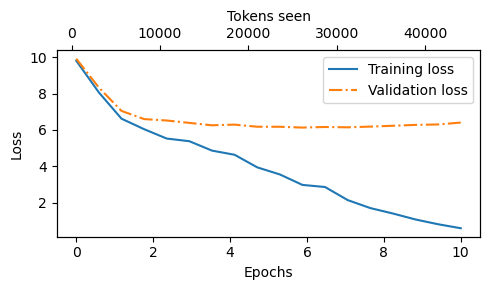

In [151]:
import matplotlib.pyplot as plt

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

- Olhando os resultados acima, vemos que o modelo começa gerando sequências de palavras incompreensíveis, enquanto, perto do final, consegue produzir frases gramaticalmente mais ou menos corretas
- No entanto, com base nas losses dos conjuntos de treino e de validação, percebemos que o modelo começa a sofrer overfitting (sobreajuste)
- Se examinássemos alguns trechos que ele escreve perto do final, descobriríamos que eles aparecem literalmente no conjunto de treino: o modelo simplesmente memoriza os dados de treino
- Mais adiante, veremos estratégias de decodificação que podem atenuar essa memorização até certo ponto
- Observe que o overfitting aqui ocorre porque temos um conjunto de treino muito, muito pequeno e iteramos sobre ele muitas vezes
  - O treinamento do LLM aqui tem finalidade principalmente didática; queremos, sobretudo, ver que o modelo consegue aprender a produzir texto coerente
  - Em vez de passar semanas ou meses treinando este modelo em grandes quantidades de hardware caro, vamos carregar pesos pré-treinados mais adiante

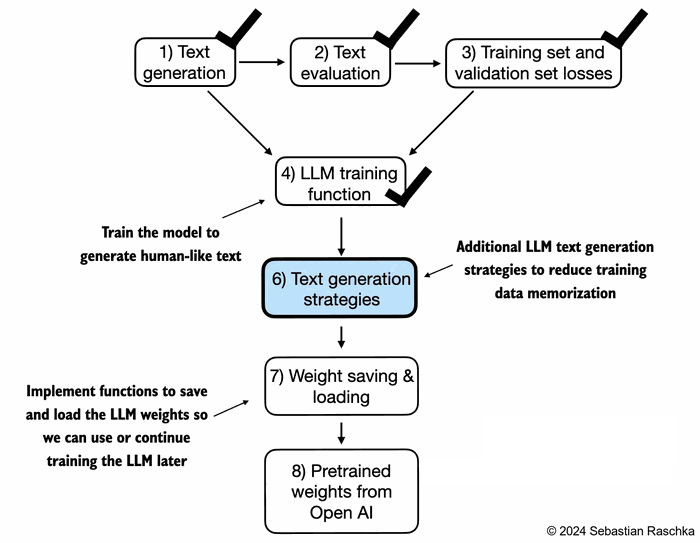

**Se tiver interesse em incrementar esta função de treinamento com técnicas mais avançadas, como learning rate warmup, cosine annealing e gradient clipping, consulte o [repositório LLMs-from-scratch](https://github.com/rasbt/LLMs-from-scratch)**

**Se tiver interesse em um dataset de treino maior e em um treinamento mais longo, veja [../03_bonus_pretraining_on_gutenberg](../03_bonus_pretraining_on_gutenberg)**

## 4.3 Estratégias de decodificação para controlar a aleatoriedade

- A inferência é relativamente barata com um LLM relativamente pequeno como o modelo GPT que treinamos acima, então não é preciso usar GPU para ela, caso você tenha usado uma GPU no treinamento acima
- Usando a função `generate_text_simple` (da parte anterior), que usamos antes dentro da função de treinamento simples, podemos gerar texto novo uma palavra (ou token) por vez
- Como explicado na seção 5.1.2, o próximo token gerado é o token correspondente ao maior score de probabilidade entre todos os tokens do vocabulário

> 🇧🇷 **O que esta célula faz:** Gera 25 tokens com o modelo treinado usando a decodificação gulosa (sempre o token mais provável); o resultado é um trecho copiado do conto.

In [152]:
model.to("cpu")
model.eval()

tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




- Mesmo que executemos a função `generate_text_simple` acima várias vezes, o LLM sempre vai gerar as mesmas saídas
- Agora apresentamos dois conceitos, as chamadas estratégias de decodificação, para modificar a `generate_text_simple`: *temperature scaling* (escalonamento por temperatura) e *top-k* sampling (amostragem top-k)
- Eles vão permitir que o modelo controle a aleatoriedade e a diversidade do texto gerado

### 4.3.1 Temperature scaling

- Antes, sempre escolhíamos como próximo token aquele com a maior probabilidade, usando `torch.argmax`
- Para adicionar variedade, podemos amostrar o próximo token usando `torch.multinomial(probs, num_samples=1)`, que amostra a partir de uma distribuição de probabilidade
- Aqui, a chance de cada índice ser escolhido corresponde à sua probabilidade no tensor de entrada

- Eis uma pequena recapitulação da geração do próximo token, assumindo um vocabulário bem pequeno para fins de ilustração:

> 🇧🇷 **O que esta célula faz:** Com um vocabulário de brinquedo de 9 palavras e logits fictícios, escolhe o próximo token pelo de maior probabilidade: "forward".

In [153]:
vocab = { 
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
} 

inverse_vocab = {v: k for k, v in vocab.items()}

# Suppose input is "every effort moves you", and the LLM
# returns the following logits for the next token:
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

probas = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item()

# The next generated token is then as follows:
print(inverse_vocab[next_token_id])

forward


> 🇧🇷 **O que esta célula faz:** Sorteia o próximo token de acordo com as probabilidades em vez de pegar sempre o maior; desta vez sai "toward".

In [154]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

toward


> 🇧🇷 **O que esta célula faz:** Sorteia o próximo token 1.000 vezes e conta quantas vezes cada palavra sai; "forward" domina, mas outras palavras também aparecem.

In [155]:
def print_sampled_tokens(probas):
    torch.manual_seed(123) # Manual seed for reproducibility
    sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)

71 x closer
2 x every
0 x effort
544 x forward
2 x inches
1 x moves
0 x pizza
376 x toward
4 x you


- Em vez de determinar o token mais provável via `torch.argmax`, usamos `torch.multinomial(probas, num_samples=1)` para determinar o token mais provável amostrando a partir da distribuição da softmax
- Para fins de ilustração, vamos ver o que acontece quando amostramos o próximo token 1.000 vezes usando as probabilidades originais da softmax:

- Podemos controlar a distribuição e o processo de seleção por meio de um conceito chamado temperature scaling
- "Temperature scaling" é apenas um nome sofisticado para dividir os logits por um número maior que 0
- Temperaturas maiores que 1 resultam em probabilidades de tokens distribuídas de forma mais uniforme após aplicar a softmax
- Temperaturas menores que 1 resultam em distribuições mais confiantes (mais agudas ou com picos mais pronunciados) após aplicar a softmax

> 🇧🇷 **O que esta célula faz:** Define uma softmax com temperatura e calcula as probabilidades para as temperaturas 1, 0,1 e 5.

In [156]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

# Temperature values
temperatures = [1, 0.1, 5]  # Original, higher confidence, and lower confidence

# Calculate scaled probabilities
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]

> 🇧🇷 **O que esta célula faz:** Plota as probabilidades de cada palavra para as três temperaturas: temperatura baixa concentra a probabilidade, temperatura alta a espalha.

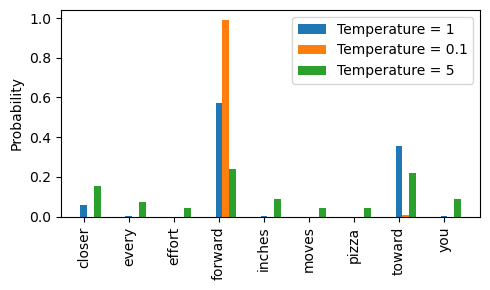

In [157]:
# Plotting
x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.savefig("temperature-plot.pdf")
plt.show()

- Podemos ver que o reescalonamento com temperatura 0,1 resulta em uma distribuição mais aguda, que se aproxima de `torch.argmax`, de modo que a palavra mais provável é selecionada quase sempre:

> 🇧🇷 **O que esta célula faz:** Com temperatura 0,1, o sorteio escolhe "forward" em 992 de 1.000 vezes, quase como sempre pegar o mais provável.

In [158]:
print_sampled_tokens(scaled_probas[1])

0 x closer
0 x every
0 x effort
992 x forward
0 x inches
0 x moves
0 x pizza
8 x toward


- As probabilidades reescalonadas com temperatura 5 ficam distribuídas de forma mais uniforme:

> 🇧🇷 **O que esta célula faz:** Com temperatura 5, as escolhas ficam bem espalhadas, e até palavras sem sentido, como "pizza", aparecem.

In [159]:
print_sampled_tokens(scaled_probas[2])

153 x closer
68 x every
55 x effort
223 x forward
102 x inches
50 x moves
43 x pizza
218 x toward
88 x you


- Supondo a entrada "every effort moves you" para o LLM, a abordagem acima pode às vezes resultar em textos sem sentido, como "every effort moves you pizza", em 3,2% das vezes (32 de 1000 vezes)

### 4.3.2 Top-k sampling

- Para podermos usar temperaturas mais altas, aumentando a diversidade da saída, e ao mesmo tempo reduzir a probabilidade de frases sem sentido, podemos restringir a amostragem aos k tokens mais prováveis (top-k):

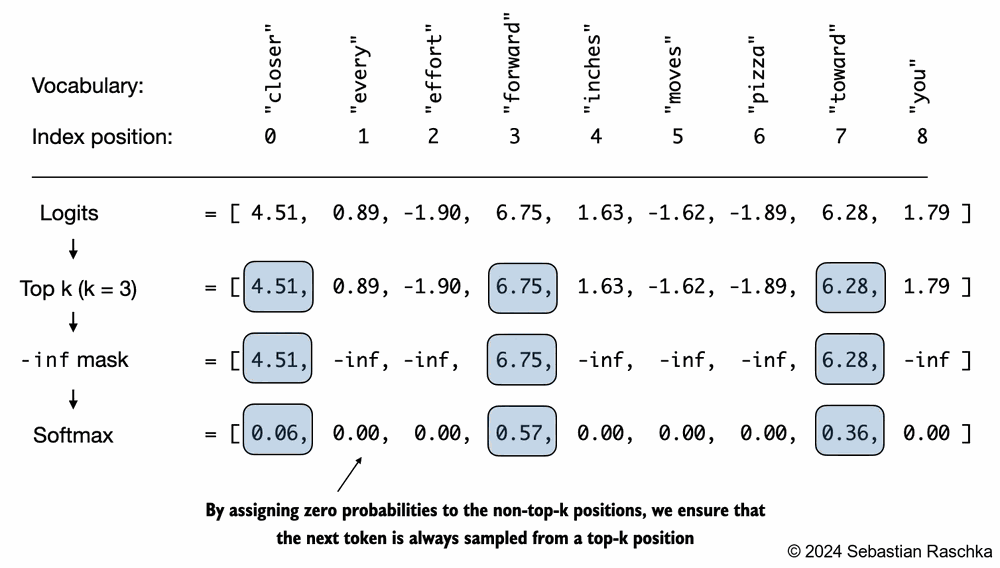

- Em código, podemos implementar isso da seguinte forma:

> 🇧🇷 **O que esta célula faz:** Seleciona os 3 maiores logits e suas posições no vocabulário.

In [160]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)

print("Top logits:", top_logits)
print("Top positions:", top_pos)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


> 🇧🇷 **O que esta célula faz:** Substitui por menos infinito todos os logits fora do top 3, descartando esses tokens.

In [161]:
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float('-inf')), 
    other=next_token_logits
)

print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


> 🇧🇷 **O que esta célula faz:** Aplica a softmax: só os 3 tokens mantidos recebem probabilidade, e os demais ficam com zero.

In [162]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


### 4.3.3 Modificando a função de geração de texto

- As duas subseções anteriores apresentaram o temperature sampling e o top-k sampling
- Vamos usar esses dois conceitos para modificar a função `generate_simple` que usamos antes para gerar texto com o LLM, criando uma nova função `generate`:

> 🇧🇷 **O que esta célula faz:** Define uma nova função de geração que combina top-k sampling e temperature scaling; com temperatura zero, volta a escolher sempre o token mais provável.

In [163]:
def generate(model, idx, max_new_tokens, context_size, temperature, top_k=None):

    # For-loop is the same as before: Get logits, and only focus on last time step
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # New: Filter logits with top_k sampling
        if top_k is not None:
            # Keep only top_k values
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float('-inf')).to(logits.device), logits)

        # New: Apply temperature scaling
        if temperature > 0.0:
            logits = logits / temperature

            # Apply softmax to get probabilities
            probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)

            # Sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)

        # Otherwise same as before: get idx of the vocab entry with the highest logits value
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)

        # Same as before: append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, num_tokens+1)

    return idx

> 🇧🇷 **O que esta célula faz:** Gera texto com top-k igual a 25 e temperatura 1,4; a saída fica mais variada e deixa de copiar o conto palavra por palavra.

In [164]:
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you know began to my surprise, poor StI was such a good; and


## 4.4 Carregando e salvando pesos do modelo no PyTorch

- Treinar LLMs é computacionalmente caro, por isso é fundamental saber salvar e carregar os pesos de um LLM

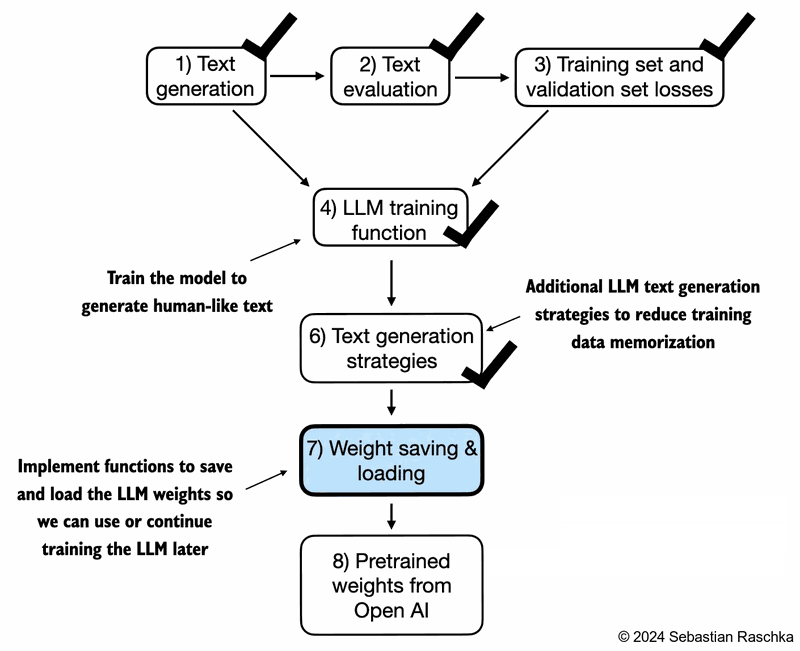

- A forma recomendada no PyTorch é salvar os pesos do modelo, o chamado `state_dict`, aplicando a função `torch.save` ao método `.state_dict()`:

> 🇧🇷 **O que esta célula faz:** Salva os pesos do modelo treinado em um arquivo.

In [165]:
torch.save(model.state_dict(), "model.pth")

- Depois, podemos carregar os pesos do modelo em uma nova instância de `GPTModel` da seguinte forma:

> 🇧🇷 **O que esta célula faz:** Cria um modelo novo e carrega nele os pesos salvos.

In [166]:
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("model.pth"))
model.eval();

- É comum treinar LLMs com otimizadores adaptativos, como Adam ou AdamW, em vez do SGD comum
- Esses otimizadores adaptativos armazenam parâmetros adicionais para cada peso do modelo, então faz sentido salvá-los também, caso planejemos continuar o pretraining mais tarde:

> 🇧🇷 **O que esta célula faz:** Salva em um único checkpoint os pesos do modelo e o estado do otimizador AdamW.

In [167]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    }, 
    "model_and_optimizer.pth"
)

> 🇧🇷 **O que esta célula faz:** Carrega o checkpoint, restaurando o modelo e o otimizador, prontos para continuar o treinamento.

In [168]:
checkpoint = torch.load("model_and_optimizer.pth")

model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();

## 4.5 Carregando pesos pré-treinados da OpenAI

- Até agora, treinamos apenas um modelo GPT-2 pequeno usando um conto muito curto, para fins didáticos
- Leitores interessados também podem encontrar um pretraining mais longo, sobre o corpus completo de livros do Project Gutenberg, em [../03_bonus_pretraining_on_gutenberg](../03_bonus_pretraining_on_gutenberg)
- Felizmente, não precisamos gastar dezenas ou centenas de milhares de dólares fazendo o pretraining do modelo em um grande corpus: podemos carregar os pesos pré-treinados fornecidos pela OpenAI

- Para uma forma alternativa de carregar os pesos a partir do Hugging Face Hub, veja [../02_alternative_weight_loading](../02_alternative_weight_loading)

- Primeiro, um pouco de código padrão (boilerplate) para baixar os arquivos da OpenAI e carregar os pesos no Python
- Como a OpenAI usou o [TensorFlow](https://www.tensorflow.org/), teremos que instalar e usar o TensorFlow para carregar os pesos; o [tqdm](https://github.com/tqdm/tqdm) é uma biblioteca de barras de progresso
- Descomente e execute a próxima célula para instalar as bibliotecas necessárias

> 🇧🇷 **O que esta célula faz:** Comando comentado para instalar o TensorFlow e o tqdm, necessários para ler os pesos da OpenAI.

In [169]:
# pip install tensorflow tqdm

> 🇧🇷 **O que esta célula faz:** Mostra as versões instaladas do TensorFlow e do tqdm.

In [170]:
print("TensorFlow version:", version("tensorflow"))
print("tqdm version:", version("tqdm"))

TensorFlow version: 2.8.0
tqdm version: 4.66.4


> 🇧🇷 **O que esta célula faz:** Importa a função auxiliar que baixa os pesos oficiais do GPT-2.

In [171]:
# Relative import from the gpt_download.py contained in this folder
from suporte.gpt_download import download_and_load_gpt2

- Em seguida, podemos baixar os pesos do modelo de 124 milhões de parâmetros da seguinte forma:

> 🇧🇷 **O que esta célula faz:** Baixa os pesos oficiais do GPT-2 de 124 milhões de parâmetros e os carrega na memória; as barras mostram o progresso de cada arquivo.

In [172]:
settings, params = download_and_load_gpt2(model_size="124M", models_dir="dados/gpt2")

checkpoint: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 77.0/77.0 [00:00<00:00, 106kiB/s]
encoder.json: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1.04M/1.04M [00:01<00:00, 1.04MiB/s]
hparams.json: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 90.0/90.0 [00:00<00:00, 102kiB/s]
model.ckpt.data-00000-of-00001: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 498M/498M [01:27<00:00, 5.69MiB/s]
model.ckpt.index: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 5.21k/5.21k [00:00<00:00, 5.43MiB/s]
model.ckpt.meta: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 471k/471k [00:00<00:

> 🇧🇷 **O que esta célula faz:** Mostra a configuração do GPT-2 baixado: vocabulário de 50.257 tokens, contexto de 1024, embeddings de 768 dimensões, 12 cabeças e 12 camadas.

In [173]:
print("Settings:", settings)

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}


> 🇧🇷 **O que esta célula faz:** Lista as chaves do dicionário de parâmetros: blocos transformer, normalização final e embeddings de tokens e de posições.

In [174]:
print("Parameter dictionary keys:", params.keys())

Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


> 🇧🇷 **O que esta célula faz:** Mostra a matriz de embeddings de tokens do GPT-2, com uma linha de 768 valores para cada um dos 50.257 tokens.

In [175]:
print(params["wte"])
print("Token embedding weight tensor dimensions:", params["wte"].shape)

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
Token embedding weight tensor dimensions: (50257, 768)


- Como alternativa, "355M", "774M" e "1558M" também são valores aceitos para o argumento `model_size`
- A diferença entre esses modelos de tamanhos diferentes está resumida na figura abaixo:

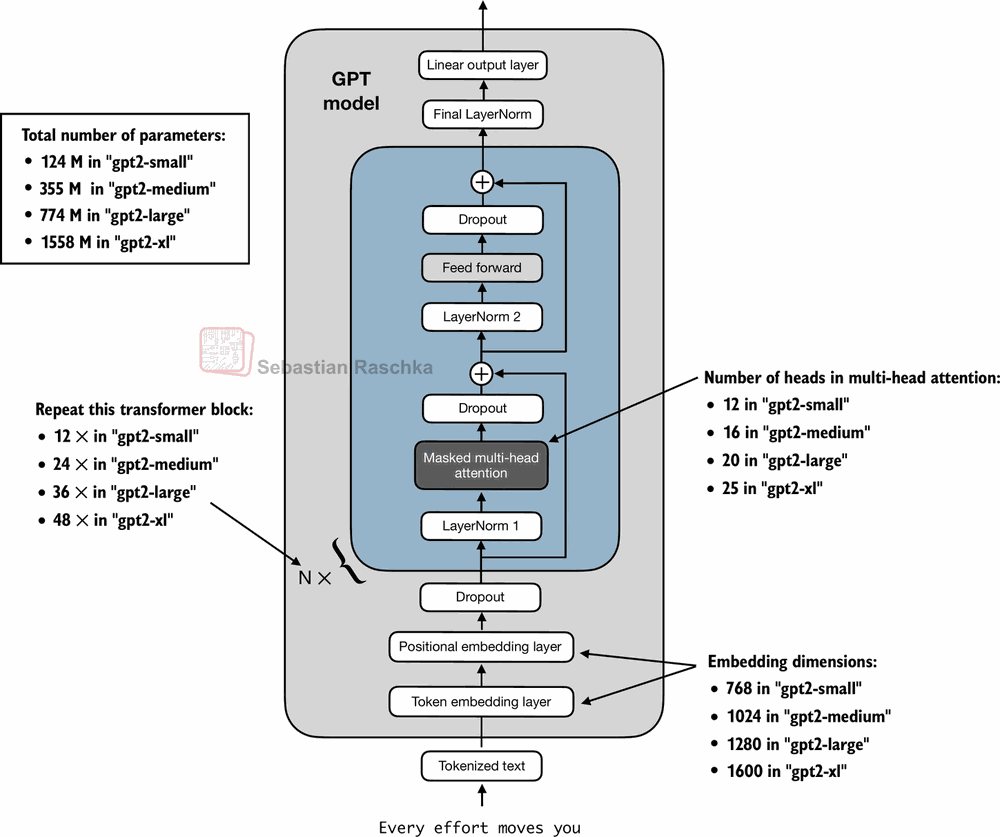

- Acima, carregamos no Python os pesos do modelo GPT-2 de 124M, mas ainda precisamos transferi-los para a nossa instância de `GPTModel`
- Primeiro, inicializamos uma nova instância de GPTModel
- Observe que o modelo GPT original inicializava com vetores de bias as camadas lineares das matrizes de query, key e value no módulo de atenção multi-head, o que não é necessário nem recomendado; porém, para conseguir carregar os pesos corretamente, também precisamos habilitá-los na nossa implementação, definindo `qkv_bias` como `True`
- Também usamos o comprimento de contexto de `1024` tokens, que era o usado pelo(s) modelo(s) GPT-2 original(is)

> 🇧🇷 **O que esta célula faz:** Monta a configuração do GPT-2 pequeno com contexto de 1024 tokens e bias nas projeções de query, key e value, e cria um modelo com ela.

In [176]:
# Define model configurations in a dictionary for compactness
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

# Copy the base configuration and update with specific model settings
model_name = "gpt2-small (124M)"  # Example model name
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True})

gpt = GPTModel(NEW_CONFIG)
gpt.eval();

- A próxima tarefa é atribuir os pesos da OpenAI aos tensores de pesos correspondentes na nossa instância de `GPTModel`

> 🇧🇷 **O que esta célula faz:** Define uma função que confere se dois tensores têm o mesmo formato antes de copiar os pesos de um para o outro.

In [177]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))

> 🇧🇷 **O que esta célula faz:** Copia cada peso da OpenAI para a camada correspondente do nosso modelo: embeddings, atenção, feed forward e normalizações de todos os blocos.

In [178]:
import numpy as np

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])
    
    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight, 
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias, 
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight, 
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias, 
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight, 
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias, 
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale, 
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift, 
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale, 
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift, 
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])
    
    
load_weights_into_gpt(gpt, params)
gpt.to("cpu");

- Se o modelo foi carregado corretamente, podemos usá-lo para gerar texto novo com a nossa função `generate` anterior:

> 🇧🇷 **O que esta célula faz:** Gera texto com o GPT-2 carregado a partir de "Every effort moves you"; o resultado é inglês fluente e coerente, sinal de que os pesos foram carregados corretamente.

In [179]:
torch.manual_seed(123)

token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you toward an equal share for each vote plus half. Inequality is often not an accurate representation of human worth; to know the


- Sabemos que carregamos os pesos do modelo corretamente porque o modelo consegue gerar texto coerente; se tivéssemos cometido até mesmo um pequeno erro, o modelo não conseguiria fazer isso

- Para uma forma alternativa de carregar os pesos a partir do Hugging Face Hub, veja [../02_alternative_weight_loading](../02_alternative_weight_loading)

## Resumo e principais conclusões

- Veja o script [gpt_train.py](gpt_train.py), que contém um script de treinamento independente
- O script [gpt_generate.py](gpt_generate.py) carrega os pesos pré-treinados da OpenAI e gera texto a partir de um prompt
- As soluções dos exercícios estão em [exercise-solutions.ipynb](exercise-solutions.ipynb)

# Parte 5 — Fine-tuning para classificação de texto

Nesta parte, damos o primeiro passo para adaptar o LLM a uma tarefa específica: **classificar textos**. Partimos do GPT-2 pré-treinado (cujos pesos carregamos na parte 4) e o transformamos em um detector de **spam** para mensagens SMS.

Para isso, preparamos um dataset balanceado de mensagens, trocamos a camada de saída do modelo por uma pequena *classification head* (cabeça de classificação) com apenas 2 saídas e fazemos o *finetuning* (ajuste fino) de algumas camadas. Ao final, o modelo acerta cerca de 96% das mensagens de teste — e prepara o terreno para a parte 6, em que ensinaremos o modelo a seguir instruções.

> 🇧🇷 **O que esta célula faz:** Libera a memória dos modelos das partes anteriores antes de carregar um modelo novo.

In [ ]:
import gc
import torch

# Libera a memória ocupada pelos modelos das partes anteriores
for nome in ["model", "gpt", "optimizer", "checkpoint", "params", "model_state_dict"]:
    globals().pop(nome, None)
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"Memória de GPU em uso: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

> 🇧🇷 **O que esta célula faz:** Confere as versões das bibliotecas usadas nesta parte (PyTorch, tiktoken, pandas, TensorFlow etc.).

In [180]:
from importlib.metadata import version

pkgs = ["matplotlib",
        "numpy",
        "tiktoken",
        "torch",
        "tensorflow", # For OpenAI's pretrained weights
        "pandas"      # Dataset loading
       ]
for p in pkgs:
    print(f"{p} version: {version(p)}")

matplotlib version: 3.8.4
numpy version: 1.26.4
tiktoken version: 0.7.0
torch version: 2.3.1
tensorflow version: 2.8.0
pandas version: 2.2.2


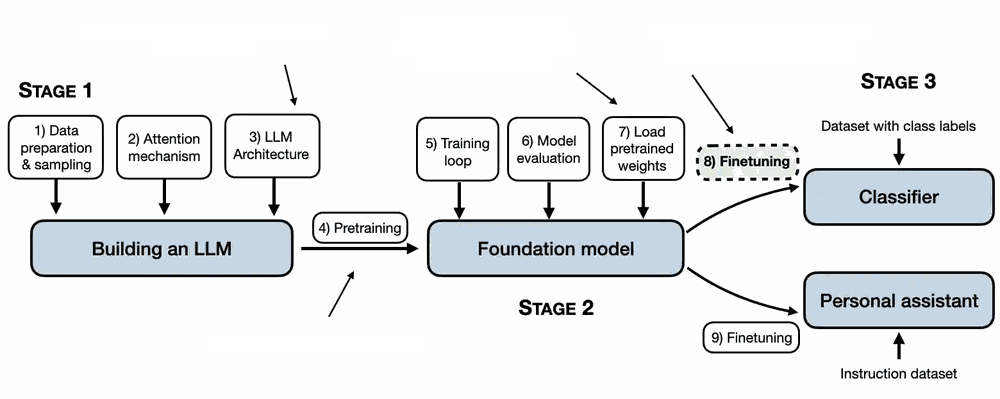

## 5.1 Diferentes categorias de finetuning

- Não há código nesta seção

- As formas mais comuns de fazer finetuning (ajuste fino) de modelos de linguagem são o *instruction-finetuning* (ajuste fino por instruções) e o *classification finetuning* (ajuste fino para classificação)
- O instruction-finetuning, ilustrado abaixo, é o tema da próxima parte

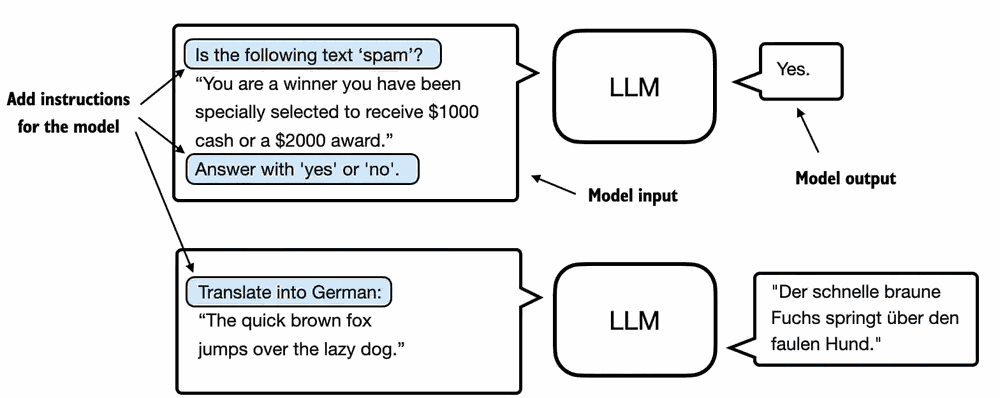

- O classification finetuning, tema desta parte, é um procedimento que talvez você já conheça se tem experiência com machine learning -- é parecido, por exemplo, com treinar uma rede convolucional para classificar dígitos escritos à mão
- No classification finetuning, temos um número específico de rótulos de classe (por exemplo, "spam" e "não spam") que o modelo pode produzir
- Um modelo ajustado para classificação só consegue prever as classes que viu durante o treinamento (por exemplo, "spam" ou "não spam"), ao passo que um modelo ajustado por instruções geralmente consegue realizar muitas tarefas
- Podemos pensar em um modelo ajustado para classificação como um modelo muito especializado; na prática, é muito mais fácil criar um modelo especializado do que um modelo generalista que tenha bom desempenho em muitas tarefas diferentes

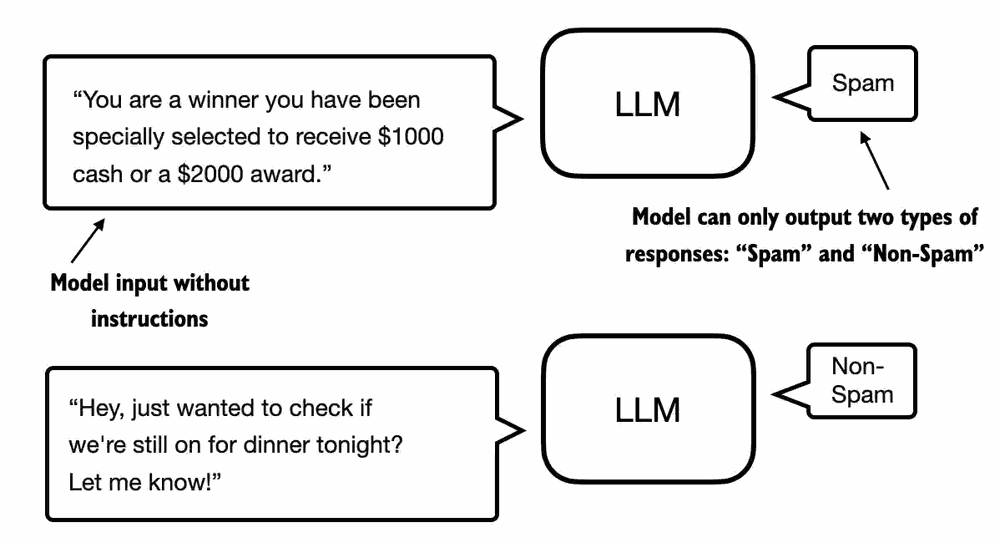

## 5.2 Preparando o dataset

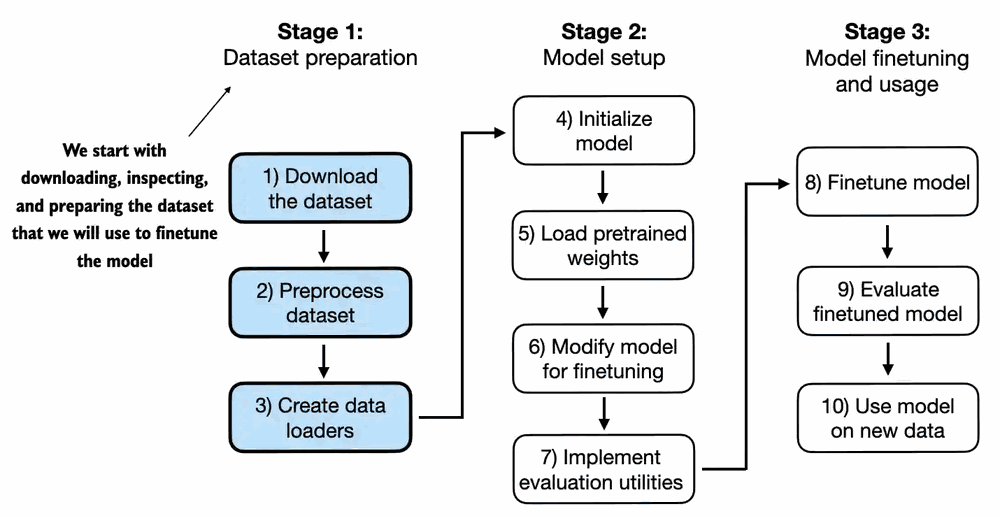

- Esta seção prepara o dataset (conjunto de dados) que usamos no classification finetuning
- Usamos um dataset formado por mensagens de texto spam e não spam para fazer o finetuning do LLM de modo que ele aprenda a classificá-las
- Primeiro, baixamos e descompactamos o dataset

> 🇧🇷 **O que esta célula faz:** Baixa e descompacta o dataset SMS Spam Collection, com milhares de mensagens SMS rotuladas como spam ou não spam.

In [181]:
import urllib.request
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "dados/sms_spam_collection.zip"
extracted_path = "dados/sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extraction.")
        return

    # Downloading the file
    with urllib.request.urlopen(url) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())

    # Unzipping the file
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    # Add .tsv file extension
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")

download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

File downloaded and saved as sms_spam_collection/SMSSpamCollection.tsv


- O dataset está salvo como um arquivo de texto separado por tabulações, que podemos carregar em um DataFrame do pandas

> 🇧🇷 **O que esta célula faz:** Carrega as mensagens em uma tabela do pandas: cada linha tem um rótulo (ham ou spam) e o texto do SMS.

In [182]:
import pandas as pd

df = pd.read_csv(data_file_path, sep="\t", header=None, names=["Label", "Text"])
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


- Ao verificar a distribuição das classes, vemos que os dados contêm "ham" (isto é, "não spam") com muito mais frequência do que "spam"

> 🇧🇷 **O que esta célula faz:** Conta as mensagens de cada classe: 4.825 "ham" (não spam) contra apenas 747 spam, um dataset bem desbalanceado.

In [183]:
print(df["Label"].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


- Por simplicidade, e porque de qualquer forma preferimos um dataset pequeno para fins didáticos (isso tornará possível fazer o finetuning do LLM mais rapidamente), fazemos uma subamostragem (*undersampling*) do dataset para que ele contenha 747 instâncias de cada classe
- (Além do undersampling, há várias outras formas de lidar com o desbalanceamento de classes, mas elas estão fora do escopo de um notebook sobre LLMs; você encontra exemplos e mais informações no [guia do usuário do `imbalanced-learn`](https://imbalanced-learn.org/stable/user_guide.html))

> 🇧🇷 **O que esta célula faz:** Balanceia o dataset sorteando 747 mensagens "ham" para igualar as 747 de spam.

In [184]:
def create_balanced_dataset(df):
    
    # Count the instances of "spam"
    num_spam = df[df["Label"] == "spam"].shape[0]
    
    # Randomly sample "ham" instances to match the number of "spam" instances
    ham_subset = df[df["Label"] == "ham"].sample(num_spam, random_state=123)
    
    # Combine ham "subset" with "spam"
    balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]])

    return balanced_df

balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


- Em seguida, convertemos os rótulos de classe em texto, "ham" e "spam", nos rótulos de classe inteiros 0 e 1:

> 🇧🇷 **O que esta célula faz:** Converte os rótulos de texto em números: "ham" vira 0 e "spam" vira 1.

In [185]:
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})

- Agora, vamos definir uma função que divide aleatoriamente o dataset em subconjuntos de treinamento, validação e teste

> 🇧🇷 **O que esta célula faz:** Embaralha os dados e os divide em 70% para treino, 10% para validação e 20% para teste, salvando cada parte em CSV.

In [186]:
def random_split(df, train_frac, validation_frac):
    # Shuffle the entire DataFrame
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)

    # Calculate split indices
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)

    # Split the DataFrame
    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]

    return train_df, validation_df, test_df

train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)
# Test size is implied to be 0.2 as the remainder

train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

## 5.3 Criando os data loaders

- Observe que as mensagens de texto têm comprimentos diferentes; se quisermos combinar vários exemplos de treinamento em um batch (lote), temos duas opções:
  - 1. truncar todas as mensagens para o comprimento da mensagem mais curta do dataset ou do batch
  - 2. aplicar padding (preenchimento) a todas as mensagens até o comprimento da mensagem mais longa do dataset ou do batch

- Escolhemos a opção 2 e aplicamos padding a todas as mensagens até o comprimento da mensagem mais longa do dataset
- Para isso, usamos `<|endoftext|>` como token de padding, como discutido na parte 1

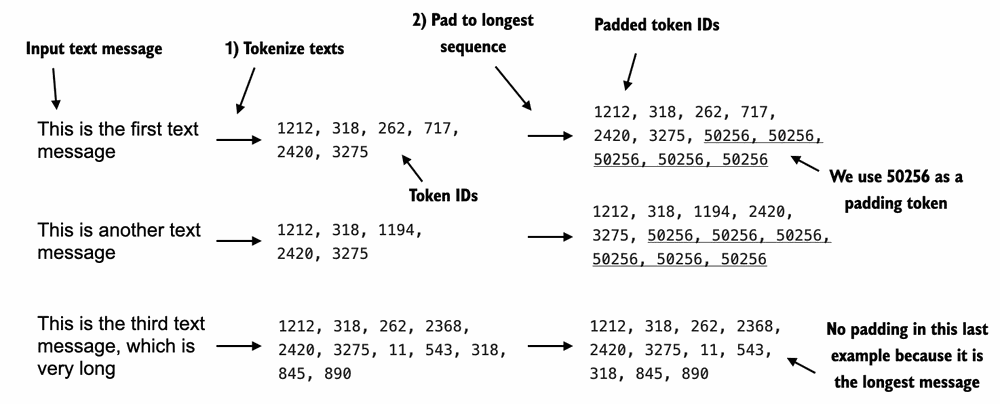

> 🇧🇷 **O que esta célula faz:** Mostra que o token especial <|endoftext|>, usado como padding, tem o ID 50256 no tokenizador do GPT-2.

In [187]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


- A classe `SpamDataset` abaixo identifica a sequência mais longa no dataset de treinamento e acrescenta o token de padding às demais, para que alcancem o comprimento dessa sequência

> 🇧🇷 **O que esta célula faz:** Define o dataset de spam: tokeniza cada mensagem e completa as mais curtas com o token de padding até todas terem o mesmo tamanho.

In [188]:
import torch
from torch.utils.data import Dataset


class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        self.data = pd.read_csv(csv_file)

        # Pre-tokenize texts
        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data["Text"]
        ]

        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
            # Truncate sequences if they are longer than max_length
            self.encoded_texts = [
                encoded_text[:self.max_length]
                for encoded_text in self.encoded_texts
            ]

        # Pad sequences to the longest sequence
        self.encoded_texts = [
            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]

    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )

    def __len__(self):
        return len(self.data)

    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if encoded_length > max_length:
                max_length = encoded_length
        return max_length

> 🇧🇷 **O que esta célula faz:** Cria o dataset de treino; a mensagem mais longa tem 120 tokens, que passa a ser o comprimento de todas.

In [189]:
train_dataset = SpamDataset(
    csv_file="train.csv",
    max_length=None,
    tokenizer=tokenizer
)

print(train_dataset.max_length)

120


- Também aplicamos padding aos conjuntos de validação e de teste até o comprimento da sequência de treinamento mais longa
- Observe que as amostras de validação e de teste mais longas que o maior exemplo de treinamento são truncadas por meio de `encoded_text[:self.max_length]` no código da `SpamDataset`
- Esse comportamento é totalmente opcional, e também funcionaria bem se definíssemos `max_length=None` tanto no conjunto de validação quanto no de teste

> 🇧🇷 **O que esta célula faz:** Cria os datasets de validação e teste usando o mesmo comprimento de 120 tokens do treino.

In [190]:
val_dataset = SpamDataset(
    csv_file="validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)
test_dataset = SpamDataset(
    csv_file="test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

- Em seguida, usamos o dataset para instanciar os data loaders, de forma semelhante à criação dos data loaders nas partes anteriores

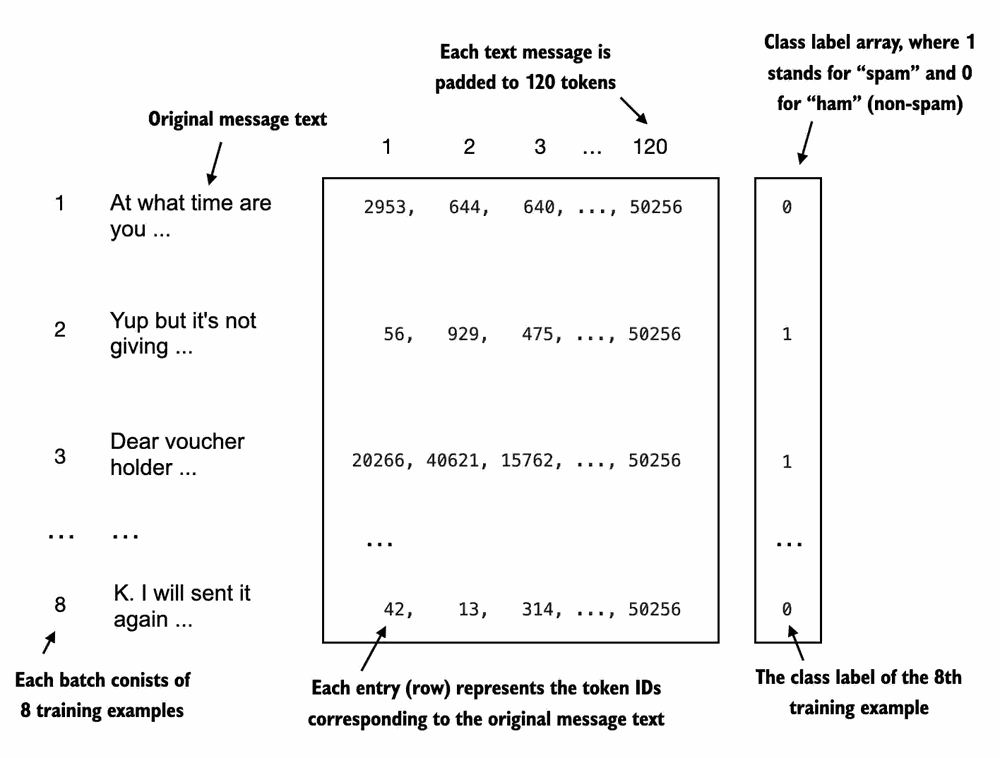

> 🇧🇷 **O que esta célula faz:** Cria os data loaders, que entregam as mensagens em batches de 8 para treino, validação e teste.

In [191]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

- Como etapa de verificação, percorremos os data loaders e confirmamos que os batches contêm 8 exemplos de treinamento cada, sendo que cada exemplo de treinamento é composto por 120 tokens

> 🇧🇷 **O que esta célula faz:** Confere o formato de um batch: 8 mensagens de 120 tokens cada, acompanhadas de 8 rótulos.

In [192]:
print("Train loader:")
for input_batch, target_batch in train_loader:
    pass

print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)

Train loader:
Input batch dimensions: torch.Size([8, 120])
Label batch dimensions torch.Size([8])


- Por fim, vamos imprimir o número total de batches em cada dataset

> 🇧🇷 **O que esta célula faz:** Mostra quantos batches há em cada conjunto: 130 de treino, 19 de validação e 38 de teste.

In [193]:
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

130 training batches
19 validation batches
38 test batches


## 5.4 Inicializando um modelo com pesos pré-treinados

- Nesta seção, inicializamos o modelo pré-treinado com o qual trabalhamos na parte anterior

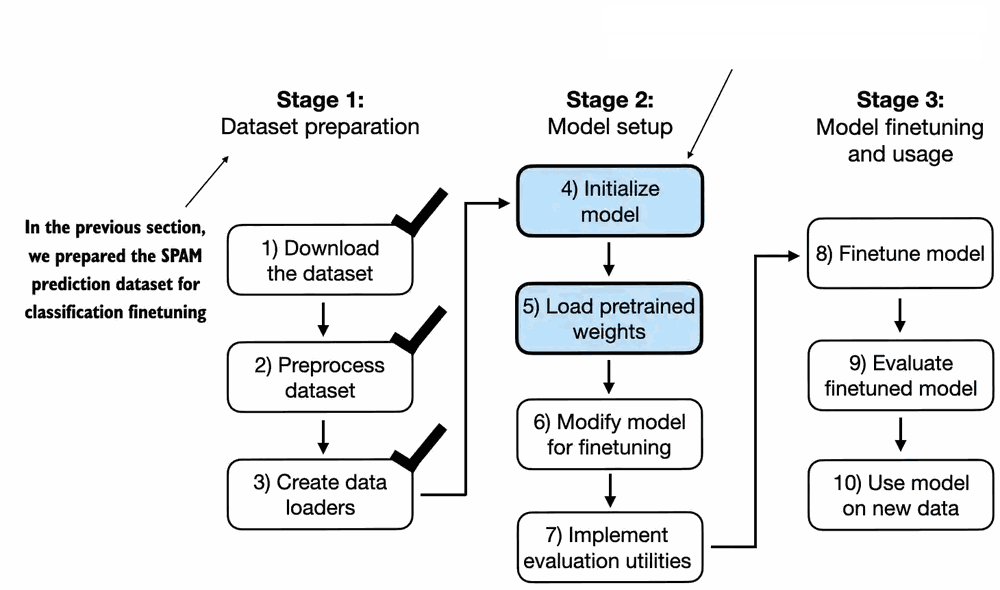

> 🇧🇷 **O que esta célula faz:** Define a configuração do GPT-2 small (124M parâmetros) e verifica se as mensagens cabem no tamanho de contexto do modelo.

In [194]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"

BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

assert train_dataset.max_length <= BASE_CONFIG["context_length"], (
    f"Dataset length {train_dataset.max_length} exceeds model's context "
    f"length {BASE_CONFIG['context_length']}. Reinitialize data sets with "
    f"`max_length={BASE_CONFIG['context_length']}`"
)

> 🇧🇷 **O que esta célula faz:** Baixa os pesos oficiais do GPT-2 e os carrega no modelo GPT construído nas partes anteriores.

In [195]:
from suporte.gpt_download import download_and_load_gpt2
from suporte.partes_anteriores_p5 import GPTModel, load_weights_into_gpt

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(model_size=model_size, models_dir="dados/gpt2")

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

checkpoint: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 77.0/77.0 [00:00<00:00, 243kiB/s]
encoder.json: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1.04M/1.04M [00:00<00:00, 1.04MiB/s]
hparams.json: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 90.0/90.0 [00:00<00:00, 57.8kiB/s]
model.ckpt.data-00000-of-00001: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 498M/498M [01:29<00:00, 5.56MiB/s]
model.ckpt.index: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 5.21k/5.21k [00:00<00:00, 6.34MiB/s]
model.ckpt.meta: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 471k/471k [00:00<00:

- Para garantir que o modelo foi carregado corretamente, vamos verificar se ele gera texto coerente

> 🇧🇷 **O que esta célula faz:** Testa o modelo carregado gerando uma continuação para "Every effort moves you": o texto sai coerente, sinal de que os pesos foram carregados corretamente.

In [196]:
from suporte.partes_anteriores_p5 import (
    generate_text_simple,
    text_to_token_ids,
    token_ids_to_text
)


text_1 = "Every effort moves you"

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_1, tokenizer),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


- Antes de fazer o finetuning do modelo como classificador, vamos ver se ele talvez já consiga classificar mensagens de spam por meio de prompting (instruções no próprio texto de entrada)

> 🇧🇷 **O que esta célula faz:** Pede ao modelo, via prompt, que diga se uma mensagem é spam: ele apenas repete parte da pergunta, pois ainda não sabe seguir instruções.

In [197]:
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_2, tokenizer),
    max_new_tokens=23,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


- Como podemos ver, o modelo não é muito bom em seguir instruções
- Isso é esperado, já que ele foi apenas pré-treinado e não passou por instruction-finetuning (o instruction-finetuning será abordado na próxima parte)

## 5.5 Adicionando uma classification head

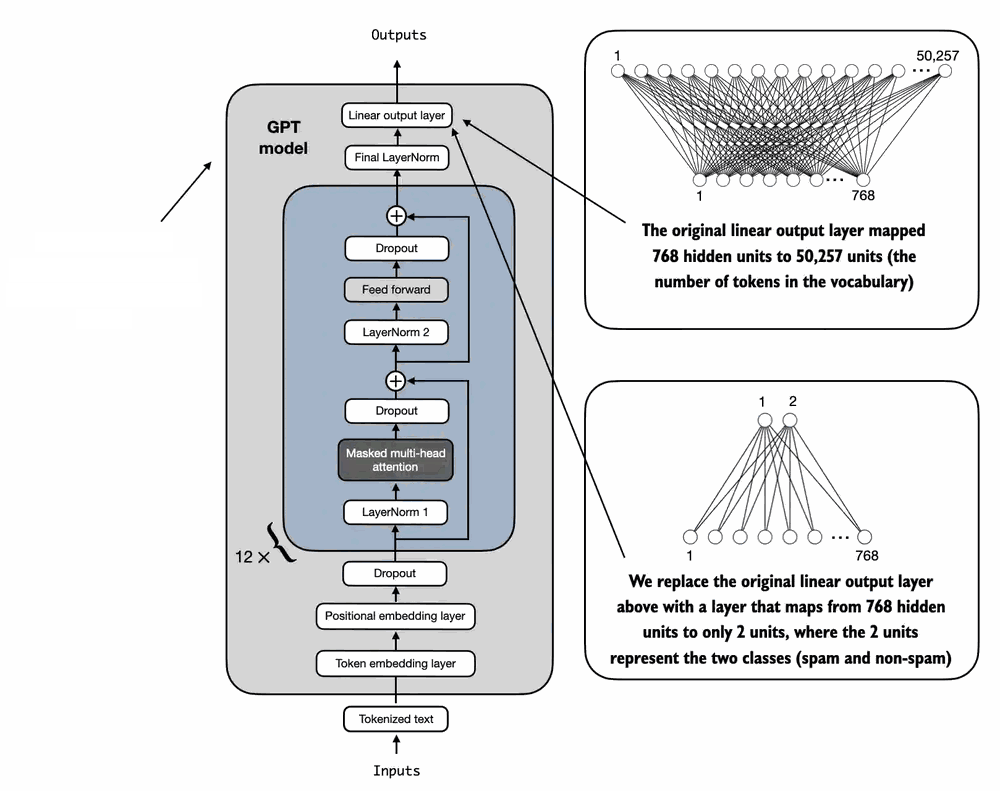

- Nesta seção, modificamos o LLM pré-treinado para deixá-lo pronto para o classification finetuning
- Vamos primeiro dar uma olhada na arquitetura do modelo

> 🇧🇷 **O que esta célula faz:** Imprime a arquitetura do modelo: embeddings, 12 blocos transformer, normalização final e a camada de saída.

In [198]:
print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768,

- Acima, vemos organizada de forma clara a arquitetura que implementamos na parte 3
- O objetivo é substituir a camada de saída e fazer seu finetuning
- Para isso, primeiro congelamos o modelo, ou seja, tornamos todas as camadas não treináveis

> 🇧🇷 **O que esta célula faz:** Congela todos os parâmetros do modelo, para que não sejam alterados durante o treino.

In [199]:
for param in model.parameters():
    param.requires_grad = False

- Depois, substituímos a camada de saída (`model.out_head`), que originalmente mapeia as entradas da camada para 50.257 dimensões (o tamanho do vocabulário)
- Como fazemos o finetuning do modelo para classificação binária (prever 2 classes, "spam" e "não spam"), podemos substituir a camada de saída como mostrado abaixo; a nova camada será treinável por padrão
- Observe que usamos `BASE_CONFIG["emb_dim"]` (que é igual a 768 no modelo `"gpt2-small (124M)"`) para manter o código abaixo mais genérico

> 🇧🇷 **O que esta célula faz:** Troca a camada de saída de 50.257 saídas (o vocabulário) por uma cabeça de classificação com apenas 2 saídas: spam e não spam.

In [200]:
torch.manual_seed(123)

num_classes = 2
model.out_head = torch.nn.Linear(in_features=BASE_CONFIG["emb_dim"], out_features=num_classes)

- Tecnicamente, basta treinar apenas a camada de saída
- No entanto, como constatei em [experimentos, fazer o finetuning de camadas adicionais](https://magazine.sebastianraschka.com/p/finetuning-large-language-models) pode melhorar visivelmente o desempenho
- Por isso, também tornamos treináveis o último bloco transformer e o módulo `LayerNorm` final, que conecta o último bloco transformer à camada de saída

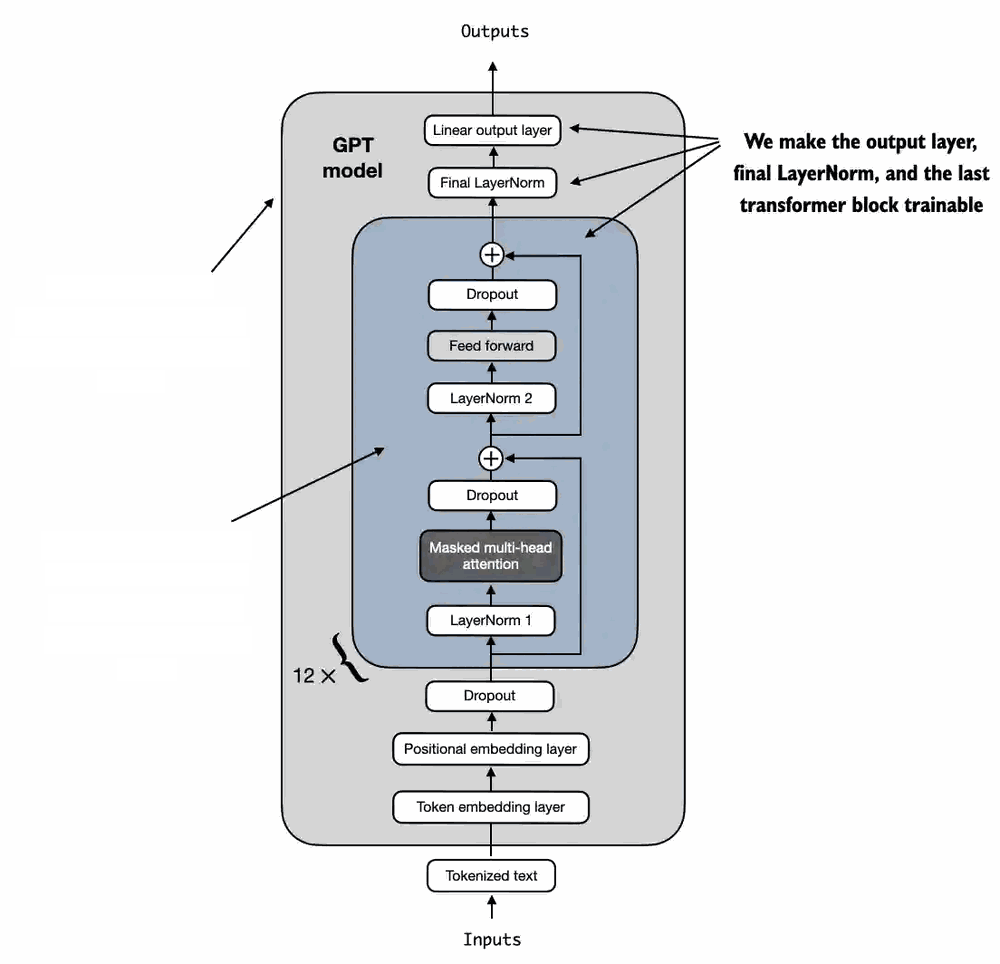

> 🇧🇷 **O que esta célula faz:** Libera para treino também o último bloco transformer e a normalização final, o que tende a melhorar o resultado.

In [201]:
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True

for param in model.final_norm.parameters():
    param.requires_grad = True

- Ainda podemos usar este modelo de forma semelhante à das partes anteriores
- Por exemplo, vamos alimentá-lo com um texto de entrada

> 🇧🇷 **O que esta célula faz:** Tokeniza a frase "Do you have time", que vira um tensor com 4 tokens.

In [202]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print("Inputs:", inputs)
print("Inputs dimensions:", inputs.shape) # shape: (batch_size, num_tokens)

Inputs: tensor([[5211,  345,  423,  640]])
Inputs dimensions: torch.Size([1, 4])


- A diferença em relação às partes anteriores é que agora ele tem duas dimensões de saída em vez de 50.257

> 🇧🇷 **O que esta célula faz:** Passa a frase pelo modelo: agora a saída tem 2 valores por token, em vez de um valor para cada palavra do vocabulário.

In [203]:
with torch.no_grad():
    outputs = model(inputs)

print("Outputs:\n", outputs)
print("Outputs dimensions:", outputs.shape) # shape: (batch_size, num_tokens, num_classes)

Outputs:
 tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])
Outputs dimensions: torch.Size([1, 4, 2])


- Como discutido nas partes anteriores, para cada token de entrada há um vetor de saída
- Como fornecemos ao modelo um texto de exemplo com 4 tokens de entrada, a saída acima consiste em 4 vetores de saída bidimensionais

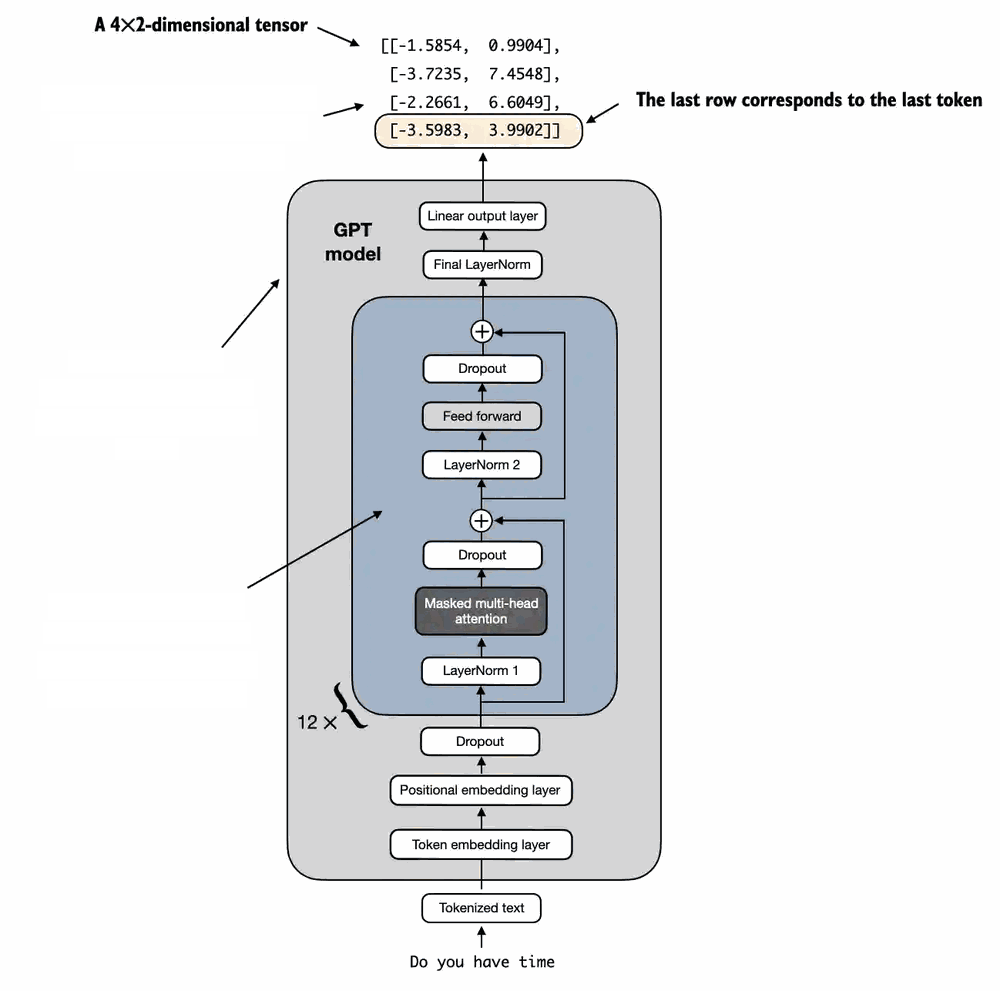

- Na parte 2, discutimos o mecanismo de atenção, que conecta cada token de entrada a todos os outros tokens de entrada
- Na parte 2, também apresentamos a máscara de atenção causal, usada em modelos do tipo GPT; essa máscara causal permite que o token atual preste atenção apenas à posição atual e às posições anteriores
- Com base nesse mecanismo de atenção causal, o 4º (último) token contém a maior quantidade de informação entre todos os tokens, porque é o único que inclui informações sobre todos os outros tokens
- Por isso, estamos particularmente interessados neste último token, que vamos ajustar (finetuning) para a tarefa de classificação de spam

> 🇧🇷 **O que esta célula faz:** Seleciona apenas a saída do último token, que é a usada para classificar a mensagem.

In [204]:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5983,  3.9902]])


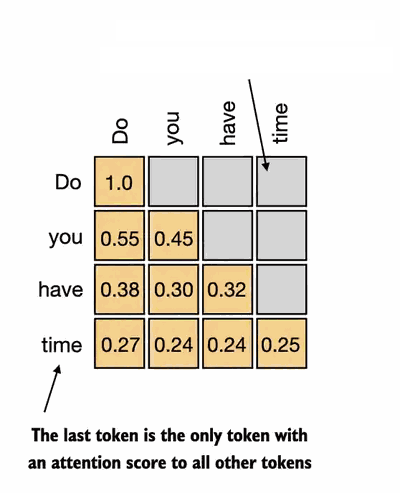

## 5.6 Calculando a loss e a accuracy de classificação

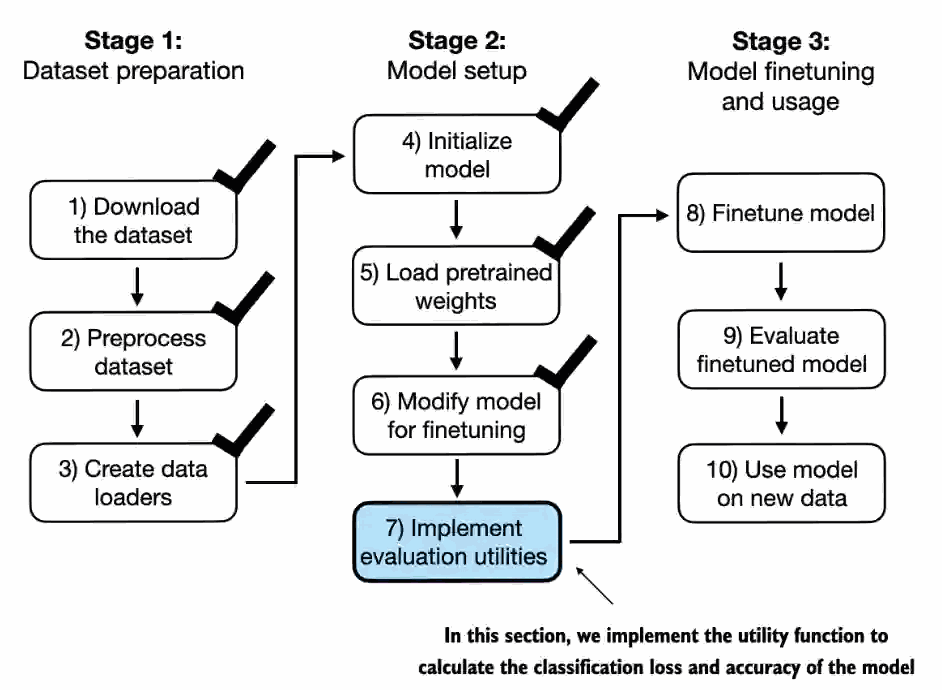

- Antes de explicar o cálculo da loss (função de perda), vamos ver rapidamente como as saídas do modelo são convertidas em rótulos de classe

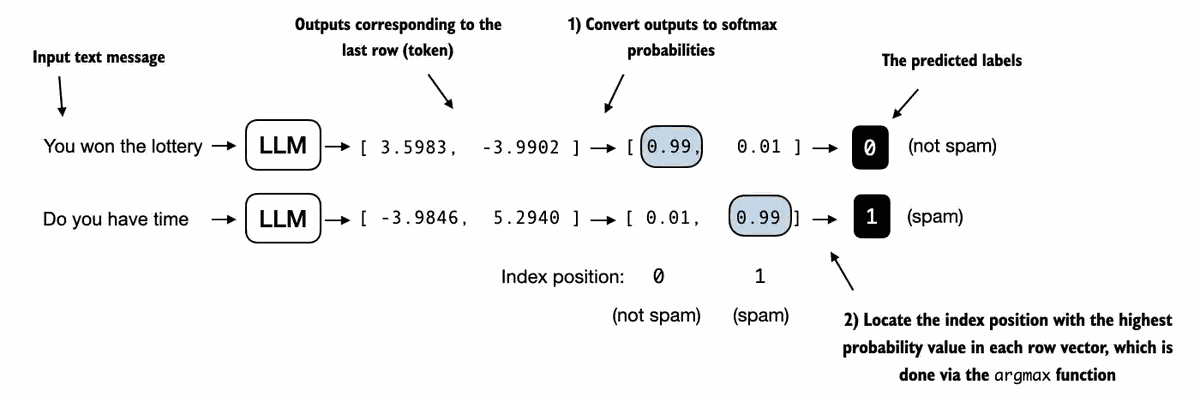

> 🇧🇷 **O que esta célula faz:** Mostra novamente a saída do último token, com os dois valores (logits) de cada classe.

In [205]:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5983,  3.9902]])


- Assim como na parte 4, convertemos as saídas (logits) em probabilidades por meio da função `softmax` e, em seguida, obtemos a posição do índice com o maior valor de probabilidade por meio da função `argmax`

> 🇧🇷 **O que esta célula faz:** Converte os logits em probabilidades com softmax e escolhe a classe mais provável: aqui, a classe 1.

In [206]:
probas = torch.softmax(outputs[:, -1, :], dim=-1)
label = torch.argmax(probas)
print("Class label:", label.item())

Class label: 1


- Observe que a função softmax é opcional aqui, como explicado na parte 4, porque as maiores saídas correspondem às maiores probabilidades

> 🇧🇷 **O que esta célula faz:** Obtém a mesma classe direto dos logits, mostrando que o softmax não é necessário para escolher a classe.

In [207]:
logits = outputs[:, -1, :]
label = torch.argmax(logits)
print("Class label:", label.item())

Class label: 1


- Podemos aplicar esse conceito para calcular a chamada accuracy (acurácia) de classificação, que calcula a porcentagem de previsões corretas em um dado dataset
- Para calcular a accuracy de classificação, podemos aplicar o código de previsão baseado em `argmax` visto acima a todos os exemplos de um dataset e calcular a fração de previsões corretas da seguinte forma:

> 🇧🇷 **O que esta célula faz:** Define uma função que calcula a acurácia, isto é, a fração de mensagens classificadas corretamente.

In [208]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch, target_batch = input_batch.to(device), target_batch.to(device)

            with torch.no_grad():
                logits = model(input_batch)[:, -1, :]  # Logits of last output token
            predicted_labels = torch.argmax(logits, dim=-1)

            num_examples += predicted_labels.shape[0]
            correct_predictions += (predicted_labels == target_batch).sum().item()
        else:
            break
    return correct_predictions / num_examples

- Vamos aplicar a função para calcular as accuracies de classificação nos diferentes datasets:

> 🇧🇷 **O que esta célula faz:** Mede a acurácia antes do treino: cerca de 46% a 49%, ou seja, o modelo ainda está chutando.

In [209]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes

torch.manual_seed(123) # For reproducibility due to the shuffling in the training data loader

train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=10)
val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=10)
test_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches=10)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 46.25%
Validation accuracy: 45.00%
Test accuracy: 48.75%


- Como podemos ver, as accuracies das previsões não são muito boas, já que ainda não fizemos o finetuning do modelo

- Antes de começar o finetuning (/treinamento), precisamos primeiro definir a função de loss que queremos otimizar durante o treinamento
- O objetivo é maximizar a accuracy do modelo na classificação de spam; no entanto, a accuracy de classificação não é uma função diferenciável
- Por isso, em vez disso, minimizamos a loss de entropia cruzada (*cross entropy*) como uma aproximação (proxy) para maximizar a accuracy de classificação (você pode aprender mais sobre esse tema na aula 8 do meu curso gratuito [Introduction to Deep Learning](https://sebastianraschka.com/blog/2021/dl-course.html#l08-multinomial-logistic-regression--softmax-regression))

- A função `calc_loss_batch` é a mesma da parte 4, exceto pelo fato de que agora só nos interessa otimizar o último token, `model(input_batch)[:, -1, :]`, em vez de todos os tokens, `model(input_batch)`

> 🇧🇷 **O que esta célula faz:** Define a loss de um batch: a entropia cruzada calculada apenas sobre a saída do último token.

In [210]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)[:, -1, :]  # Logits of last output token
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

A `calc_loss_loader` é exatamente igual à da parte 4

> 🇧🇷 **O que esta célula faz:** Define a loss média ao longo de vários batches, igual à usada na parte 4.

In [211]:
# Same as in part 4
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

- Usando a `calc_loss_loader`, calculamos as losses iniciais dos conjuntos de treinamento, validação e teste antes de começar o treinamento

> 🇧🇷 **O que esta célula faz:** Calcula a loss inicial nos três conjuntos, em torno de 2,3 a 2,6, antes de qualquer treino.

In [212]:
with torch.no_grad(): # Disable gradient tracking for efficiency because we are not training, yet
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)

print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 2.453
Validation loss: 2.583
Test loss: 2.322


- Na próxima seção, treinamos o modelo para melhorar os valores de loss e, consequentemente, a accuracy de classificação

## 5.7 Fazendo o finetuning do modelo com dados supervisionados

- Nesta seção, definimos e usamos a função de treinamento para melhorar a accuracy de classificação do modelo
- A função `train_classifier_simple` abaixo é praticamente igual à função `train_model_simple` que usamos para pré-treinar o modelo na parte 4
- As duas únicas diferenças são que agora
  1. contamos o número de exemplos de treinamento vistos (`examples_seen`) em vez do número de tokens vistos
  2. calculamos a accuracy após cada época em vez de imprimir um texto de exemplo após cada época

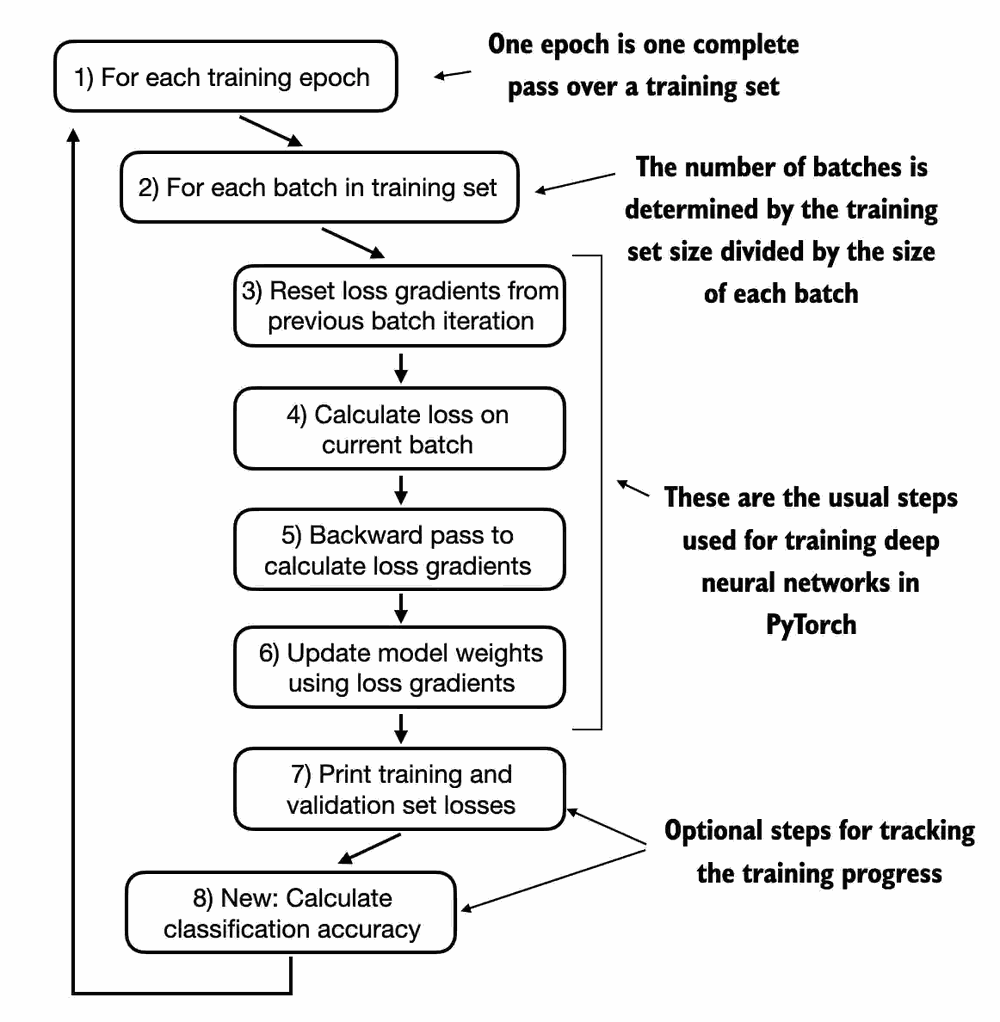

> 🇧🇷 **O que esta célula faz:** Define o laço de treino do classificador: atualiza os pesos a cada batch, mostra as losses periodicamente e mede a acurácia ao fim de cada época.

In [213]:
# Overall the same as `train_model_simple` in part 4
def train_classifier_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                            eval_freq, eval_iter):
    # Initialize lists to track losses and examples seen
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            examples_seen += input_batch.shape[0] # New: track examples instead of tokens
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Calculate accuracy after each epoch
        train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
        val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=eval_iter)
        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen

- A função `evaluate_model` usada em `train_classifier_simple` é a mesma que usamos na parte 4

> 🇧🇷 **O que esta célula faz:** Define a função que avalia a loss de treino e de validação sem alterar o modelo.

In [214]:
# Same as part 4
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

- O treinamento leva cerca de 5 minutos em um notebook MacBook Air M3 e menos de meio minuto em uma GPU V100 ou A100

> 🇧🇷 **O que esta célula faz:** Treina o classificador por 5 épocas: a loss cai de cerca de 2,2 para menos de 0,1, e a acurácia sobe de 70% até perto de 100%.

In [215]:
import time

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)

num_epochs = 5
train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=50, eval_iter=5,
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.153, Val loss 2.392
Ep 1 (Step 000050): Train loss 0.617, Val loss 0.637
Ep 1 (Step 000100): Train loss 0.523, Val loss 0.557
Training accuracy: 70.00% | Validation accuracy: 72.50%
Ep 2 (Step 000150): Train loss 0.561, Val loss 0.489
Ep 2 (Step 000200): Train loss 0.419, Val loss 0.397
Ep 2 (Step 000250): Train loss 0.409, Val loss 0.353
Training accuracy: 82.50% | Validation accuracy: 85.00%
Ep 3 (Step 000300): Train loss 0.333, Val loss 0.320
Ep 3 (Step 000350): Train loss 0.340, Val loss 0.306
Training accuracy: 90.00% | Validation accuracy: 90.00%
Ep 4 (Step 000400): Train loss 0.136, Val loss 0.200
Ep 4 (Step 000450): Train loss 0.153, Val loss 0.132
Ep 4 (Step 000500): Train loss 0.222, Val loss 0.137
Training accuracy: 100.00% | Validation accuracy: 97.50%
Ep 5 (Step 000550): Train loss 0.207, Val loss 0.143
Ep 5 (Step 000600): Train loss 0.083, Val loss 0.074
Training accuracy: 100.00% | Validation accuracy: 97.50%
Training completed in 0.64 mi

- Assim como na parte 4, usamos o matplotlib para plotar a função de loss dos conjuntos de treinamento e de validação

> 🇧🇷 **O que esta célula faz:** Define uma função que plota as curvas de treino e validação em função das épocas e dos exemplos vistos.

In [216]:
import matplotlib.pyplot as plt

def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    # Create a second x-axis for examples seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(examples_seen, train_values, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

> 🇧🇷 **O que esta célula faz:** Plota a loss de treino e de validação: as duas curvas caem juntas, sinal de que o modelo aprende sem overfitting.

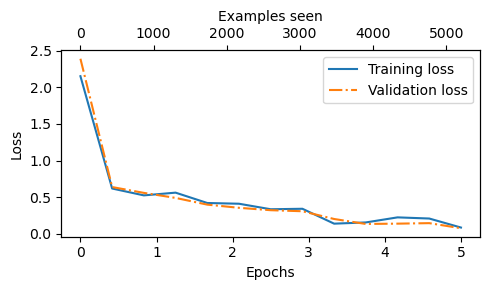

In [217]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

- Acima, com base na inclinação descendente, vemos que o modelo aprende bem
- Além disso, o fato de as losses de treinamento e de validação estarem muito próximas indica que o modelo não tende a sofrer overfitting (sobreajuste) nos dados de treinamento
- Da mesma forma, podemos plotar a accuracy abaixo

> 🇧🇷 **O que esta célula faz:** Plota a acurácia de treino e de validação ao longo das épocas, que sobe rapidamente e se aproxima de 100%.

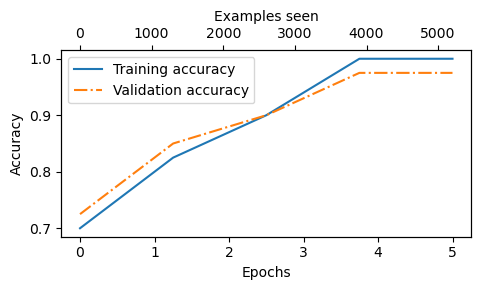

In [218]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

- Com base no gráfico de accuracy acima, vemos que o modelo atinge uma accuracy de treinamento e de validação relativamente alta após as épocas 4 e 5
- No entanto, precisamos lembrar que especificamos `eval_iter=5` na função de treinamento, o que significa que apenas estimamos o desempenho nos conjuntos de treinamento e de validação
- Podemos calcular o desempenho nos conjuntos de treinamento, validação e teste sobre o dataset completo, como mostrado abaixo

> 🇧🇷 **O que esta célula faz:** Mede a acurácia final nos conjuntos completos: cerca de 97% em treino e validação e 95,67% no teste.

In [219]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 97.21%
Validation accuracy: 97.32%
Test accuracy: 95.67%


- Vemos que os desempenhos nos conjuntos de treinamento e de teste são praticamente idênticos
- No entanto, com base no desempenho um pouco inferior no conjunto de teste, vemos que o modelo sofre um overfitting muito pequeno nos dados de treinamento, assim como nos dados de validação, que foram usados para ajustar alguns dos hiperparâmetros, como a taxa de aprendizado (*learning rate*)
- Isso é normal, porém, e essa diferença poderia ser reduzida ainda mais aumentando a taxa de dropout do modelo (`drop_rate`) ou o `weight_decay` na configuração do otimizador

## 5.8 Usando o LLM como classificador de spam

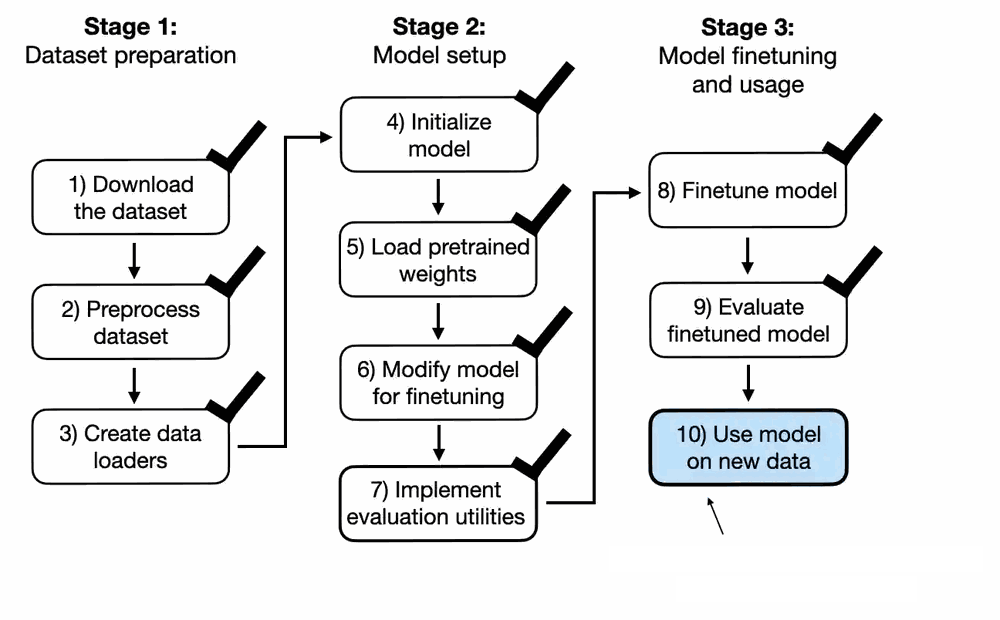

- Por fim, vamos colocar em ação o modelo GPT ajustado (após o finetuning)
- A função `classify_review` abaixo implementa etapas de pré-processamento dos dados semelhantes às da `SpamDataset` que implementamos anteriormente
- Em seguida, a função obtém do modelo o rótulo de classe inteiro previsto e retorna o nome da classe correspondente

> 🇧🇷 **O que esta célula faz:** Define uma função que prepara uma mensagem nova, passa pelo modelo e responde "spam" ou "not spam".

In [220]:
def classify_review(text, model, tokenizer, device, max_length=None, pad_token_id=50256):
    model.eval()

    # Prepare inputs to the model
    input_ids = tokenizer.encode(text)
    supported_context_length = model.pos_emb.weight.shape[1]

    # Truncate sequences if they too long
    input_ids = input_ids[:min(max_length, supported_context_length)]

    # Pad sequences to the longest sequence
    input_ids += [pad_token_id] * (max_length - len(input_ids))
    input_tensor = torch.tensor(input_ids, device=device).unsqueeze(0) # add batch dimension

    # Model inference
    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]  # Logits of the last output token
    predicted_label = torch.argmax(logits, dim=-1).item()

    # Return the classified result
    return "spam" if predicted_label == 1 else "not spam"

- Vamos testá-la com alguns exemplos abaixo

> 🇧🇷 **O que esta célula faz:** Classifica uma mensagem prometendo prêmio em dinheiro: o modelo responde corretamente "spam".

In [221]:
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)

print(classify_review(
    text_1, model, tokenizer, device, max_length=train_dataset.max_length
))

spam


> 🇧🇷 **O que esta célula faz:** Classifica um convite comum para jantar: o modelo responde corretamente "not spam".

In [222]:
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print(classify_review(
    text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

not spam


- Por fim, vamos salvar o modelo, caso queiramos reutilizá-lo mais tarde sem precisar treiná-lo novamente

> 🇧🇷 **O que esta célula faz:** Salva os pesos do classificador treinado em disco, para reutilizá-lo sem precisar treinar de novo.

In [223]:
torch.save(model.state_dict(), "review_classifier.pth")

- Depois, em uma nova sessão, poderíamos carregar o modelo da seguinte forma

> 🇧🇷 **O que esta célula faz:** Carrega os pesos salvos de volta no modelo; a mensagem confirma que todos os parâmetros foram encontrados.

In [224]:
model_state_dict = torch.load("review_classifier.pth")
model.load_state_dict(model_state_dict)

<All keys matched successfully>

## Resumo e principais lições

- Leitores interessados encontram uma introdução ao treinamento eficiente em parâmetros com *low-rank adaptation* (LoRA) no apêndice E

# Parte 6 — Fine-tuning para seguir instruções

Nesta parte final, pegamos o GPT-2 pré-treinado e fazemos o **instruction finetuning** (ajuste fino com instruções), para que ele deixe de apenas completar textos e passe a **seguir instruções**.
Preparamos um dataset de 1.100 pares instrução-resposta no formato **Alpaca**, montamos batches com uma função *collate* personalizada e ajustamos o **GPT-2 medium (355M)** por duas épocas.
Por fim, geramos respostas para o conjunto de teste e usamos outro LLM, o **Llama 3** rodando via Ollama, para dar notas automáticas a elas.
É o fechamento da jornada: depois de implementar a arquitetura (partes 1 a 3) e pré-treinar o modelo (parte 4), chegamos ao ajuste fino que transforma o LLM em um assistente.

> 🇧🇷 **O que esta célula faz:** Libera a memória dos modelos das partes anteriores antes de carregar um modelo novo.

In [ ]:
import gc
import torch

# Libera a memória ocupada pelos modelos das partes anteriores
for nome in ["model", "gpt", "optimizer", "checkpoint", "params", "model_state_dict"]:
    globals().pop(nome, None)
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"Memória de GPU em uso: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

> 🇧🇷 **O que esta célula faz:** Mostra a GPU disponível no ambiente (na execução original, uma NVIDIA RTX 3060).

In [225]:
!nvidia-smi

/bin/bash: /home/pasteurjr/anaconda3/envs/tfcuda11/lib/libtinfo.so.6: no version information available (required by /bin/bash)
Sat Jun 22 17:42:16 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.171.04             Driver Version: 535.171.04   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce RTX 3060        Off | 00000000:01:00.0  On |                  N/A |
|  0%   41C    P8              17W / 170W |    436MiB / 12288MiB |      8%      Default |
|                              

> 🇧🇷 **O que esta célula faz:** Exibe as versões das bibliotecas usadas nesta parte (matplotlib, tiktoken, torch, tqdm e tensorflow).

In [226]:
from importlib.metadata import version

pkgs = [
    "matplotlib",  # Plotting library
    "tiktoken",    # Tokenizer
    "torch",       # Deep learning library
    "tqdm",        # Progress bar
    "tensorflow",  # For OpenAI's pretrained weights
]
for p in pkgs:
    print(f"{p} version: {version(p)}")

matplotlib version: 3.8.4
tiktoken version: 0.7.0
torch version: 2.3.1
tqdm version: 4.66.4
tensorflow version: 2.8.0


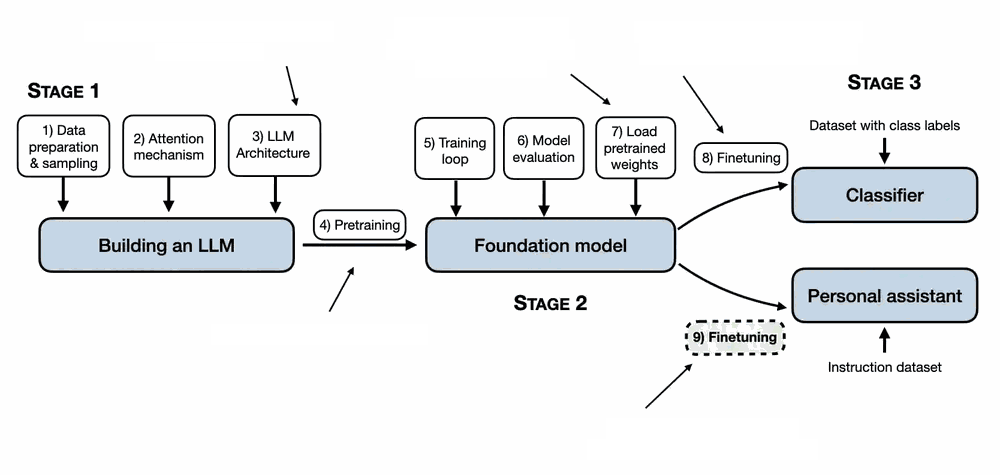

## 6.1 Introdução ao instruction finetuning

- Na parte 4, vimos que o pré-treinamento de um LLM envolve um procedimento de treino no qual ele aprende a gerar uma palavra de cada vez
- Por isso, um LLM pré-treinado é bom em completar textos, mas não é bom em seguir instruções
- Nesta parte, ensinamos o LLM a seguir instruções melhor

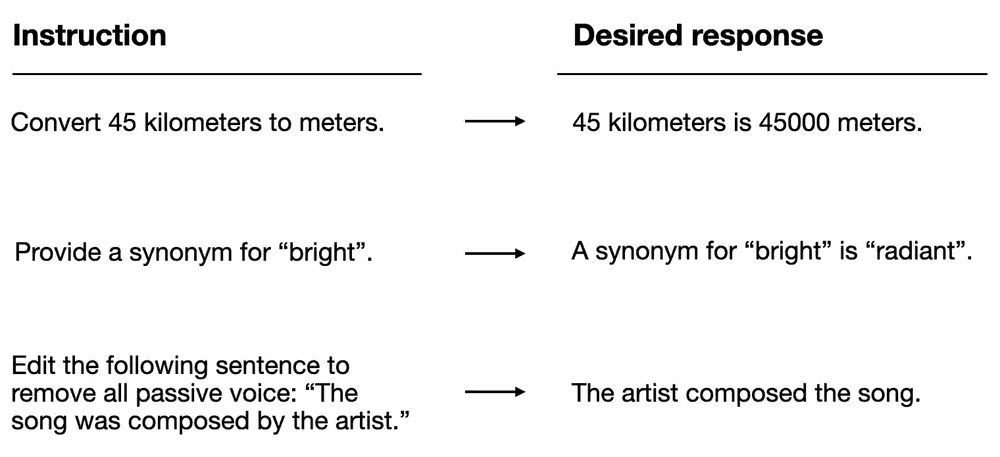

- Os tópicos abordados nesta parte estão resumidos na figura abaixo

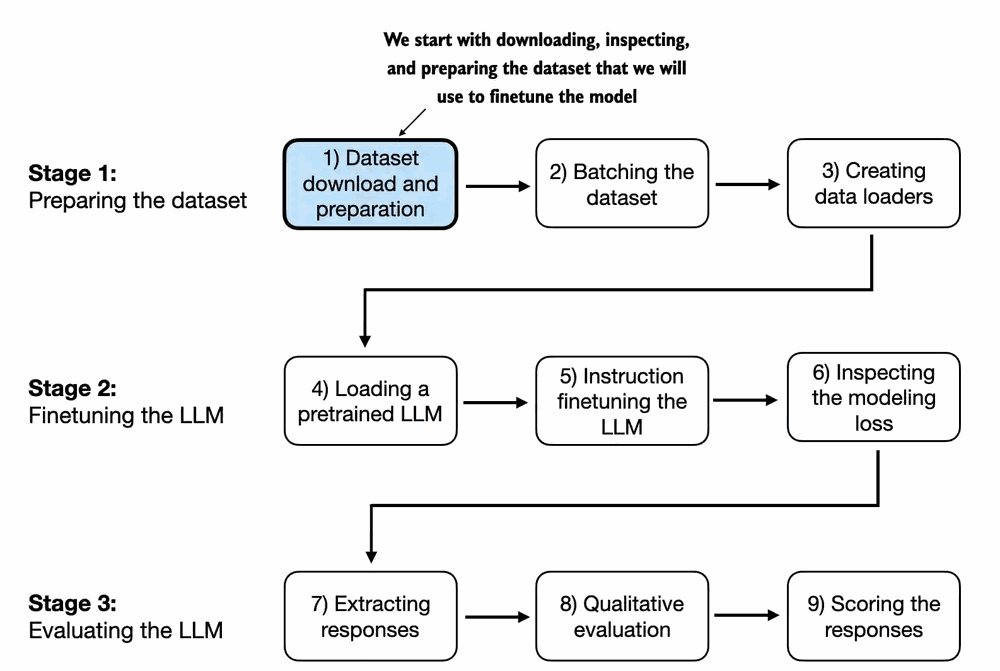

## 6.2 Preparando um dataset para instruction finetuning supervisionado

- Vamos trabalhar com um dataset (conjunto de dados) de instruções preparado para esta parte

> 🇧🇷 **O que esta célula faz:** Baixa o dataset de instruções preparado para esta parte e o carrega; ele tem 1.100 exemplos.

In [227]:
import json
import os
import urllib


def download_and_load_file(file_path, url):

    if not os.path.exists(file_path):
        with urllib.request.urlopen(url) as response:
            text_data = response.read().decode("utf-8")
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)
    else:
        with open(file_path, "r", encoding="utf-8") as file:
            text_data = file.read()

    with open(file_path, "r") as file:
        data = json.load(file)

    return data


file_path = "dados/instruction-data.json"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch07/01_main-chapter-code/instruction-data.json"

data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))

Number of entries: 1100


- Cada item da lista `data` que carregamos do arquivo JSON acima é um dicionário no seguinte formato

> 🇧🇷 **O que esta célula faz:** Mostra um exemplo do dataset: um dicionário com os campos instruction, input e output.

In [228]:
print("Example entry:\n", data[50])

Example entry:
 {'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}


- Observe que o campo `'input'` pode estar vazio:

> 🇧🇷 **O que esta célula faz:** Mostra outro exemplo, agora com o campo input vazio.

In [229]:
print("Another example entry:\n", data[999])

Another example entry:
 {'instruction': "What is an antonym of 'complicated'?", 'input': '', 'output': "An antonym of 'complicated' is 'simple'."}


- O instruction finetuning costuma ser chamado de "instruction finetuning supervisionado" (supervised instruction finetuning) porque envolve treinar um modelo com um dataset em que os pares de entrada e saída são fornecidos explicitamente
- Há diferentes maneiras de formatar as entradas para o LLM; a figura abaixo ilustra dois formatos de exemplo que foram usados para treinar, respectivamente, os LLMs Alpaca (https://crfm.stanford.edu/2023/03/13/alpaca.html) e Phi-3 (https://arxiv.org/abs/2404.14219)

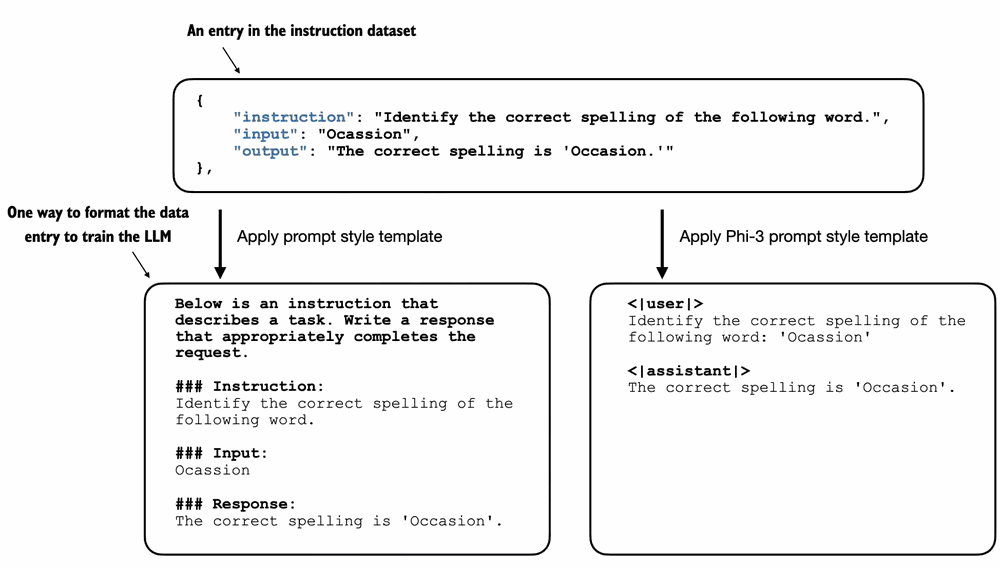

- Nesta parte, usamos a formatação de prompt no estilo Alpaca, que foi o template (modelo) de prompt original para instruction finetuning
- Abaixo, formatamos a entrada que passaremos ao LLM

> 🇧🇷 **O que esta célula faz:** Define a função que formata uma entrada no estilo de prompt do Alpaca, com a instrução e, se houver, o campo de entrada.

In [230]:
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text

- Uma resposta formatada com o campo de entrada (input) fica como mostrado abaixo

> 🇧🇷 **O que esta célula faz:** Monta um exemplo completo no formato Alpaca, com instrução, entrada e a resposta desejada.

In [231]:
model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"

print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


- Abaixo está uma resposta formatada sem o campo de entrada

> 🇧🇷 **O que esta célula faz:** Monta um exemplo no formato Alpaca sem o campo de entrada.

In [232]:
model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[999]['output']}"

print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


- Por fim, antes de prepararmos os data loaders do PyTorch na próxima seção, dividimos o dataset em conjuntos de treino, validação e teste

> 🇧🇷 **O que esta célula faz:** Divide o dataset em 85% para treino, 10% para teste e o restante para validação.

In [233]:
train_portion = int(len(data) * 0.85)  # 85% for training
test_portion = int(len(data) * 0.1)   # 10% for testing
val_portion = len(data) - train_portion - test_portion  # Remaining 5% for validation

train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]

> 🇧🇷 **O que esta célula faz:** Mostra o tamanho de cada parte: 935 exemplos de treino, 55 de validação e 110 de teste.

In [234]:
print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 935
Validation set length: 55
Test set length: 110


## 6.3 Organizando os dados em batches de treino

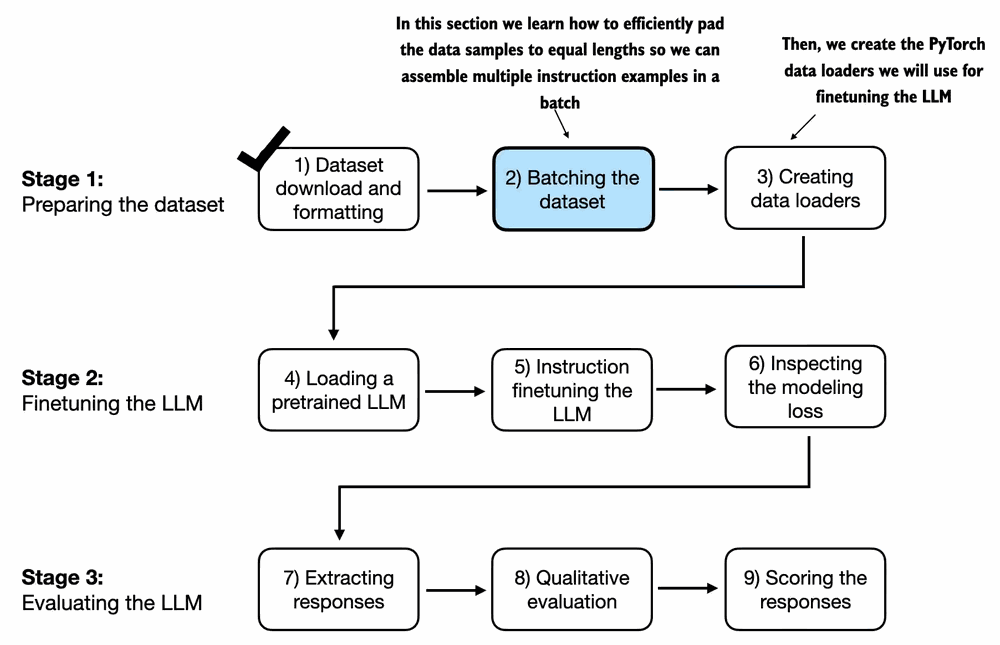

- Fazemos a montagem dos batches (lotes) deste dataset em várias etapas, como resume a figura abaixo

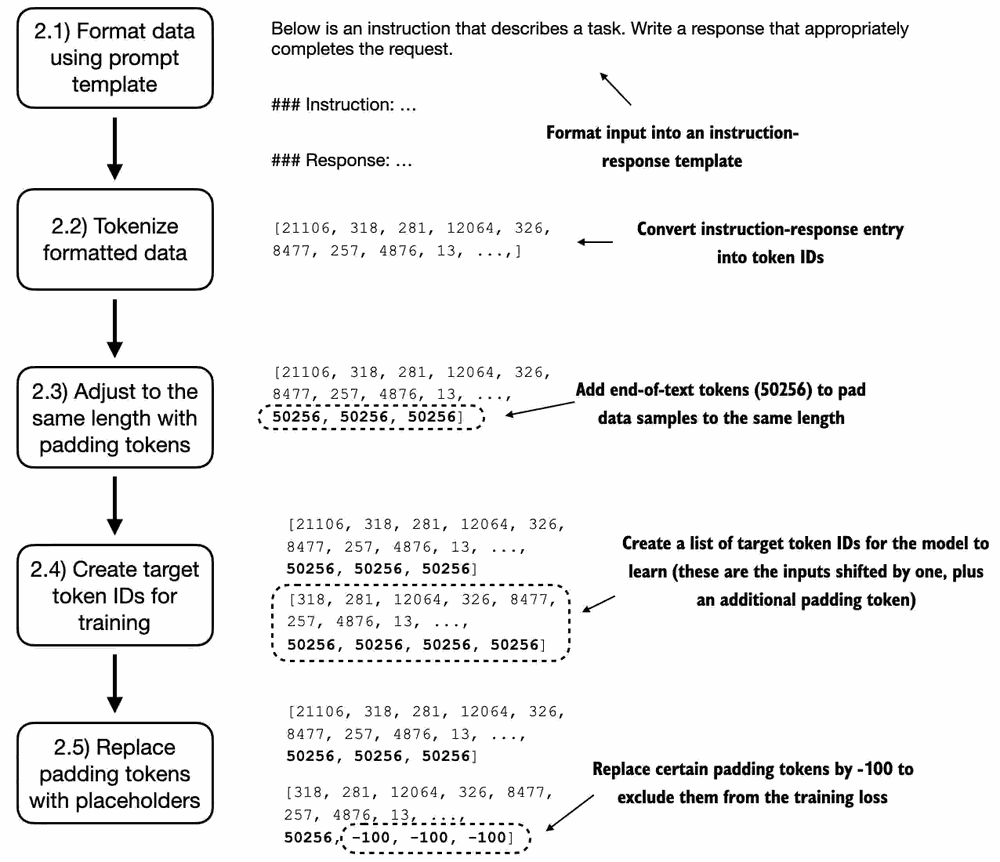

- Primeiro, implementamos uma classe `InstructionDataset` que pré-tokeniza todas as entradas do dataset, de forma semelhante ao `SpamDataset` da parte 5

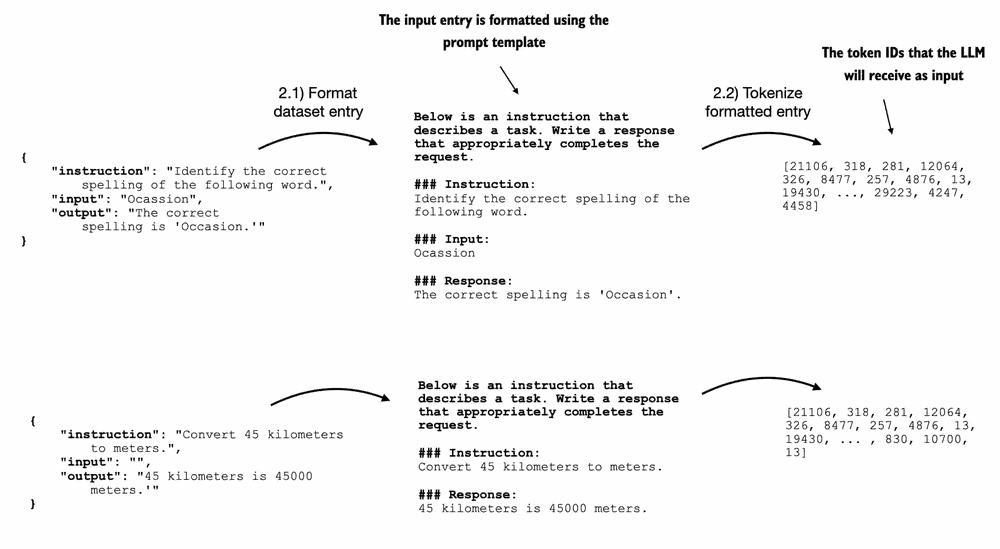

> 🇧🇷 **O que esta célula faz:** Define a classe de dataset que formata e pré-tokeniza todos os exemplos de instrução.

In [235]:
import torch
from torch.utils.data import Dataset


class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data

        # Pre-tokenize texts
        self.encoded_texts = []
        for entry in data:
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text
            self.encoded_texts.append(
                tokenizer.encode(full_text)
            )

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)

- Assim como na parte 5, queremos reunir vários exemplos de treino em um batch para acelerar o treinamento; isso exige completar (padding) todas as entradas até um comprimento semelhante
- Também como na parte anterior, usamos o token `<|endoftext|>` como token de padding

> 🇧🇷 **O que esta célula faz:** Confirma que o token <|endoftext|>, usado como padding, tem o ID 50256 no tokenizador do GPT-2.

In [236]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


- Na parte 5, completamos todos os exemplos do dataset até o mesmo comprimento
  - Aqui, adotamos uma abordagem mais sofisticada e desenvolvemos uma função "collate" personalizada, que podemos passar ao data loader
  - Essa função collate personalizada completa os exemplos de treino de cada batch para que tenham o mesmo comprimento (mas batches diferentes podem ter comprimentos diferentes)

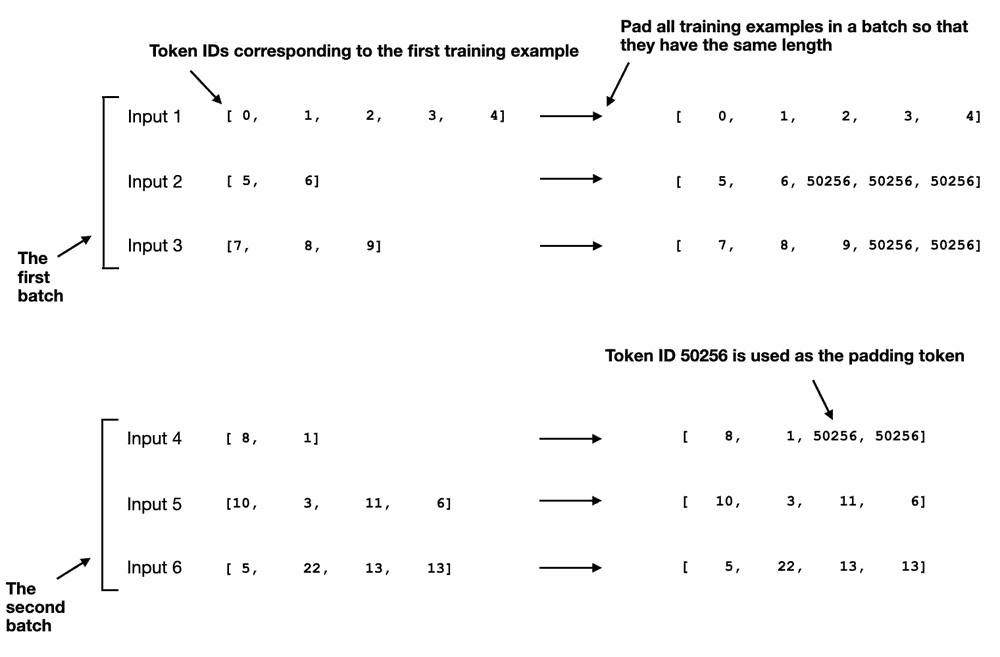

> 🇧🇷 **O que esta célula faz:** Primeira versão da função collate: completa cada sequência do batch com tokens de padding até o comprimento da maior.

In [237]:
def custom_collate_draft_1(
    batch,
    pad_token_id=50256,
    device="cpu"
):
    # Find the longest sequence in the batch
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs
    inputs_lst = []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to max_length
        # this always adds at least 1 additional padding tokens
        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item))
        # We remove this extra padded token again here
        inputs = torch.tensor(padded[:-1])
        inputs_lst.append(inputs)

    # Convert list of inputs to tensor and transfer to target device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    return inputs_tensor

> 🇧🇷 **O que esta célula faz:** Testa a função com três sequências curtas; as mais curtas recebem o token 50256 até igualar o tamanho da maior.

In [238]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


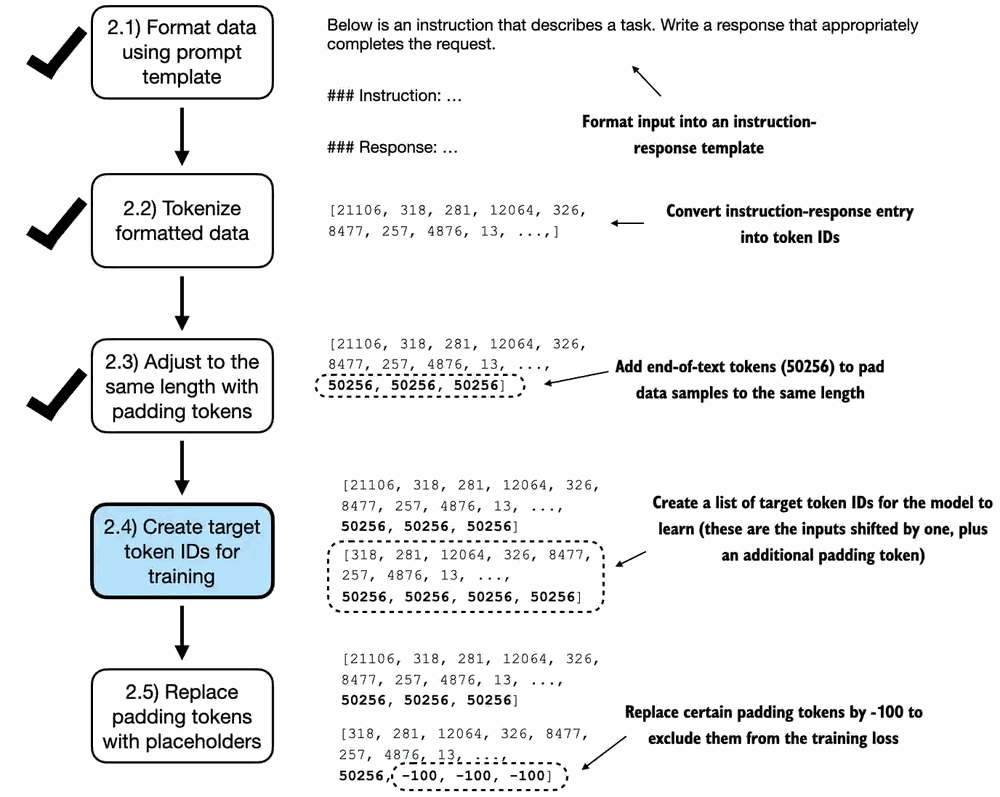

- Acima, retornamos apenas as entradas para o LLM; no entanto, para treinar o LLM, também precisamos dos valores-alvo (targets)
- Assim como no pré-treinamento de um LLM, os alvos são as entradas deslocadas 1 posição para a direita, de modo que o LLM aprenda a prever o próximo token

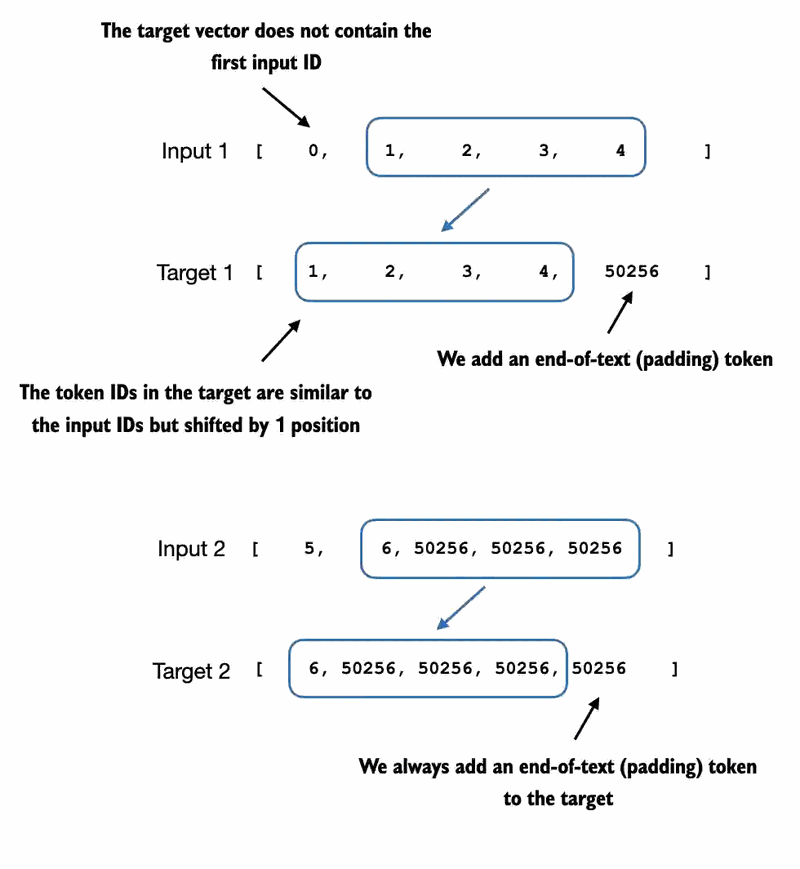

> 🇧🇷 **O que esta célula faz:** Segunda versão da função collate, que além das entradas gera os alvos deslocados uma posição à direita.

In [239]:
def custom_collate_draft_2(
    batch,
    pad_token_id=50256,
    device="cpu"
):
    # Find the longest sequence in the batch
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to max_length
        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item))
        inputs = torch.tensor(padded[:-1])  # Truncate the last token for inputs
        targets = torch.tensor(padded[1:])  # Shift +1 to the right for targets
        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # Convert list of inputs to tensor and transfer to target device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

> 🇧🇷 **O que esta célula faz:** Mostra as entradas e os alvos do batch de teste; os alvos são as entradas deslocadas em um token.

In [240]:
inputs, targets = custom_collate_draft_2(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


- Em seguida, introduzimos um valor `ignore_index` para substituir todos os IDs de token de padding por um novo valor; o objetivo desse `ignore_index` é permitir que ignoremos os valores de padding na função de loss (falaremos mais sobre isso adiante)

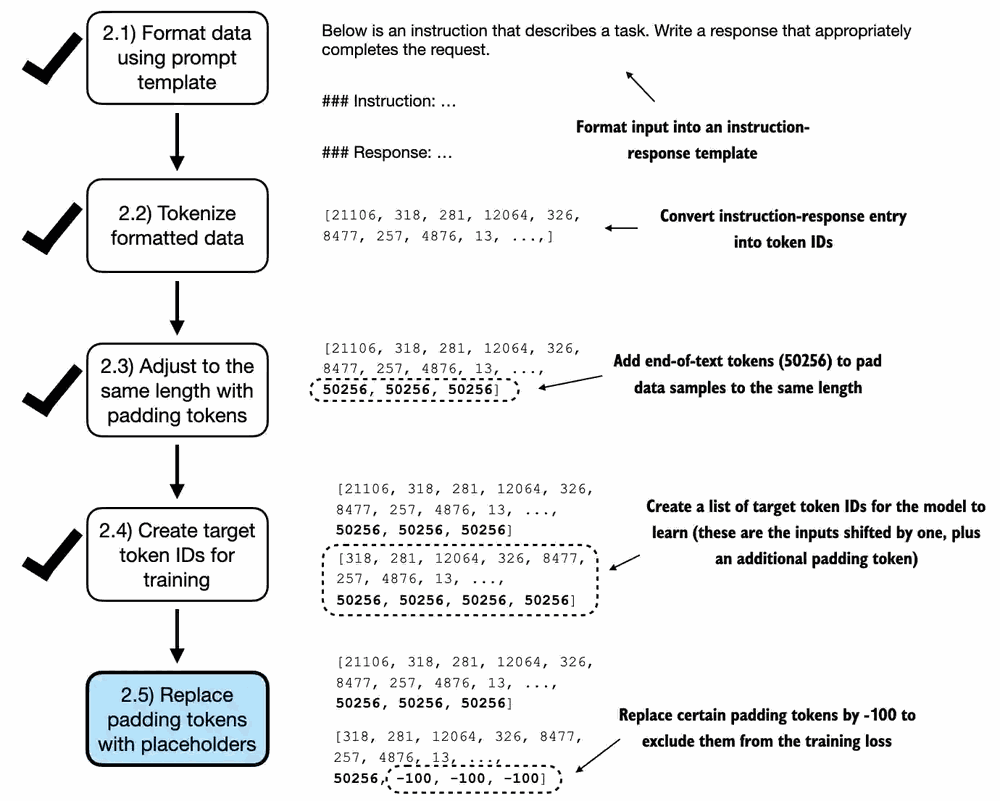

- Concretamente, isso significa que substituímos os IDs de token correspondentes a `50256` por `-100`, como ilustrado abaixo

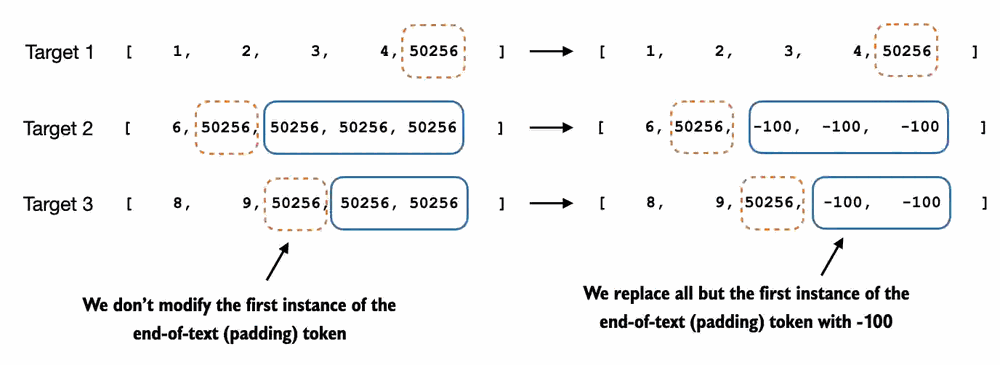

- (Além disso, introduzimos também o `allowed_max_length`, caso queiramos limitar o comprimento das amostras; isso será útil se você pretende trabalhar com seus próprios datasets com textos mais longos que o tamanho de contexto de 1024 tokens suportado pelo modelo GPT-2)

> 🇧🇷 **O que esta célula faz:** Versão final da função collate: troca por -100 os tokens de padding extras nos alvos (mantendo o primeiro) e permite limitar o comprimento máximo.

In [241]:
def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=None,
    device="cpu"
):
    # Find the longest sequence in the batch
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs and targets
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to max_length
        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item))
        inputs = torch.tensor(padded[:-1])  # Truncate the last token for inputs
        targets = torch.tensor(padded[1:])  # Shift +1 to the right for targets

        # New: Replace all but the first padding tokens in targets by ignore_index
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        # New: Optionally truncate to maximum sequence length
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # Convert list of inputs and targets to tensors and transfer to target device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)

    return inputs_tensor, targets_tensor

> 🇧🇷 **O que esta célula faz:** Nos alvos, os tokens de padding após o primeiro agora aparecem como -100, que será ignorado pela loss.

In [242]:
inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


- Vamos ver o que essa substituição por -100 consegue
- Para fins de ilustração, suponha que temos uma pequena tarefa de classificação com 2 rótulos de classe, 0 e 1, semelhante à da parte 5
- Se tivermos os seguintes valores de logits (saídas da última camada do modelo), calculamos a seguinte loss

> 🇧🇷 **O que esta célula faz:** Calcula a loss de entropia cruzada em um exemplo simples com dois exemplos de treino; o resultado é 1,1269.

In [243]:
logits_1 = torch.tensor(
    [[-1.0, 1.0],  # 1st training example
     [-0.5, 1.5]]  # 2nd training example
)
targets_1 = torch.tensor([0, 1])


loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)
print(loss_1)

tensor(1.1269)


- Agora, adicionar mais um exemplo de treino vai, como esperado, influenciar a loss

> 🇧🇷 **O que esta célula faz:** Adiciona um terceiro exemplo e a loss muda para 0,7936, como esperado.

In [244]:
logits_2 = torch.tensor(
    [[-1.0, 1.0],
     [-0.5, 1.5],
     [-0.5, 1.5]]  # New 3rd training example
)
targets_2 = torch.tensor([0, 1, 1])

loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

tensor(0.7936)


- Vejamos o que acontece se substituirmos o rótulo de classe de um dos exemplos por -100

> 🇧🇷 **O que esta célula faz:** Com o rótulo -100 no terceiro exemplo, a loss volta a 1,1269: esse exemplo é ignorado no cálculo.

In [245]:
targets_3 = torch.tensor([0, 1, -100])

loss_3 = torch.nn.functional.cross_entropy(logits_2, targets_3)
print(loss_3)
print("loss_1 == loss_3:", loss_1 == loss_3)

tensor(1.1269)
loss_1 == loss_3: tensor(True)


- Como podemos ver, a loss resultante para esses 3 exemplos de treino é igual à loss que calculamos a partir dos 2 exemplos de treino, o que significa que a função de loss de entropia cruzada (cross entropy) ignorou o exemplo de treino com o rótulo -100
- Por padrão, o PyTorch tem a configuração `cross_entropy(..., ignore_index=-100)` para ignorar os exemplos correspondentes ao rótulo -100
- Usando esse `ignore_index` de -100, podemos ignorar os tokens de fim de texto (padding) adicionais que usamos nos batches para completar os exemplos de treino até o mesmo comprimento
- No entanto, não queremos ignorar a primeira ocorrência do token de fim de texto (padding) (50256), porque ela pode ajudar a sinalizar ao LLM quando a resposta está completa

- Na prática, também é comum mascarar os IDs de token dos alvos que correspondem à instrução, como ilustrado na figura abaixo (este é um exercício recomendado ao leitor depois de concluir esta parte)

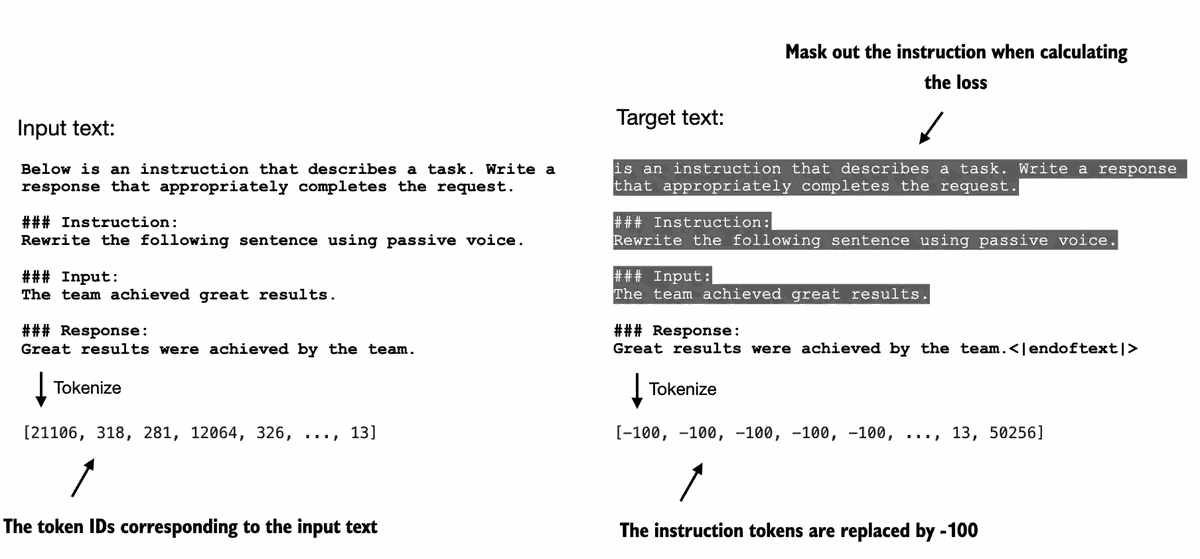

## 6.4 Criando data loaders para um dataset de instruções

- Nesta seção, usamos a classe `InstructionDataset` e a função `custom_collate_fn` para instanciar os data loaders de treino, validação e teste

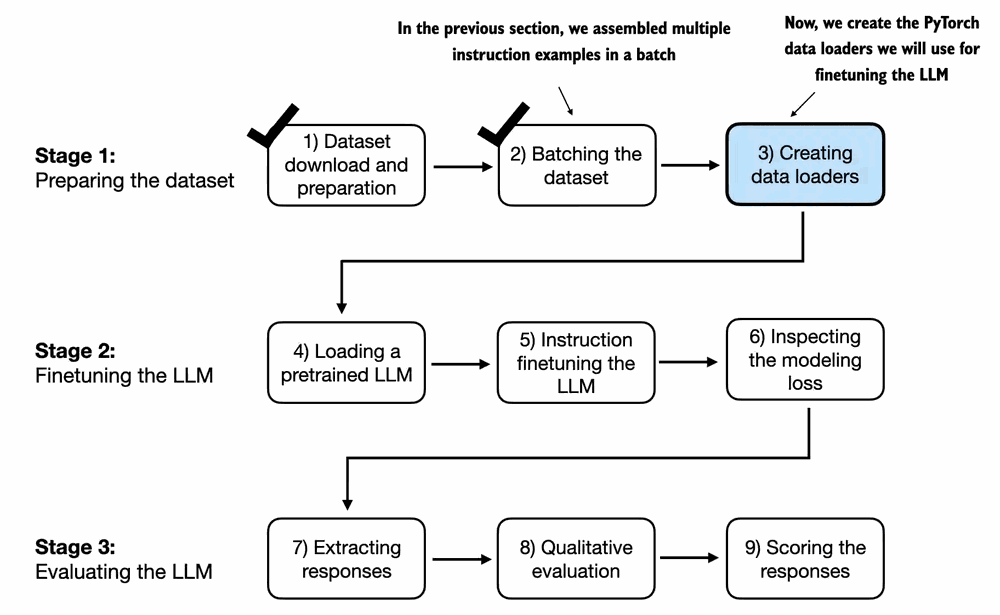

- Outro detalhe adicional da função `custom_collate_fn` anterior é que agora movemos os dados diretamente para o dispositivo de destino (por exemplo, a GPU), em vez de fazer isso no laço principal de treinamento; isso melhora a eficiência, porque pode ser executado como um processo em segundo plano quando usamos a `custom_collate_fn` como parte do data loader
- Usando a função `partial` da biblioteca padrão `functools` do Python, criamos uma nova função com o argumento `device` da função original já preenchido

> 🇧🇷 **O que esta célula faz:** Detecta o dispositivo (GPU, se houver) e cria uma versão da função collate já configurada para ele.

In [246]:
from functools import partial

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

customized_collate_fn = partial(custom_collate_fn, device=device, allowed_max_length=1024)

Device: cuda


- Em seguida, instanciamos os data loaders de forma semelhante às partes anteriores, exceto que agora fornecemos nossa própria função collate para o processo de montagem dos batches

> 🇧🇷 **O que esta célula faz:** Cria o data loader de treino, com batches de 8 exemplos e a função collate personalizada.

In [247]:
from torch.utils.data import DataLoader


num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True
)

> 🇧🇷 **O que esta célula faz:** Cria os data loaders de validação e de teste da mesma forma.

In [248]:
val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False
)



- Vejamos como ficam as dimensões dos batches de entrada e de alvo resultantes

> 🇧🇷 **O que esta célula faz:** Mostra as dimensões dos batches de treino: todos têm 8 exemplos, mas o comprimento varia de batch para batch.

In [249]:
print("Train loader:")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)

Train loader:
torch.Size([8, 61]) torch.Size([8, 61])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 79]) torch.Size([8, 79])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 83]) torch.Size([8, 83])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 68]) torch.

- Como podemos ver pela saída acima, todos os batches têm tamanho 8, mas comprimentos diferentes, como esperado
- Vamos também conferir se as entradas contêm os tokens de padding `<|endoftext|>` correspondentes ao ID de token 50256, imprimindo o conteúdo do primeiro exemplo de treino do batch `inputs`

> 🇧🇷 **O que esta célula faz:** Exibe os IDs de token do primeiro exemplo do batch; no fim aparecem os tokens de padding 50256.

In [250]:
print(inputs[0])

tensor([21106,   318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,
          257,  2882,   326, 20431, 32543,   262,  2581,    13,   198,   198,
        21017, 46486,    25,   198, 30003,  6525,   262,  6827,  1262,   257,
          985,   576,    13,   198,   198, 21017, 23412,    25,   198,   464,
         5156,   318,   845, 13779,    13,   198,   198, 21017, 18261,    25,
          198,   464,  5156,   318,   355, 13779,   355,   257,  4936,    13,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256],
       device='cuda:0')


- Da mesma forma, conferimos visualmente se os alvos contêm os tokens de marcação -100

> 🇧🇷 **O que esta célula faz:** Exibe os alvos do mesmo exemplo: após o primeiro 50256, o padding foi trocado por -100.

In [251]:
print(targets[0])

tensor([  318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,   257,
         2882,   326, 20431, 32543,   262,  2581,    13,   198,   198, 21017,
        46486,    25,   198, 30003,  6525,   262,  6827,  1262,   257,   985,
          576,    13,   198,   198, 21017, 23412,    25,   198,   464,  5156,
          318,   845, 13779,    13,   198,   198, 21017, 18261,    25,   198,
          464,  5156,   318,   355, 13779,   355,   257,  4936,    13, 50256,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100],
       device='cuda:0')


## 6.5 Carregando um LLM pré-treinado

- Nesta seção, carregamos um modelo GPT pré-treinado usando o mesmo código que usamos na seção 4.5 da parte 4 e na seção 5.4 da parte 5

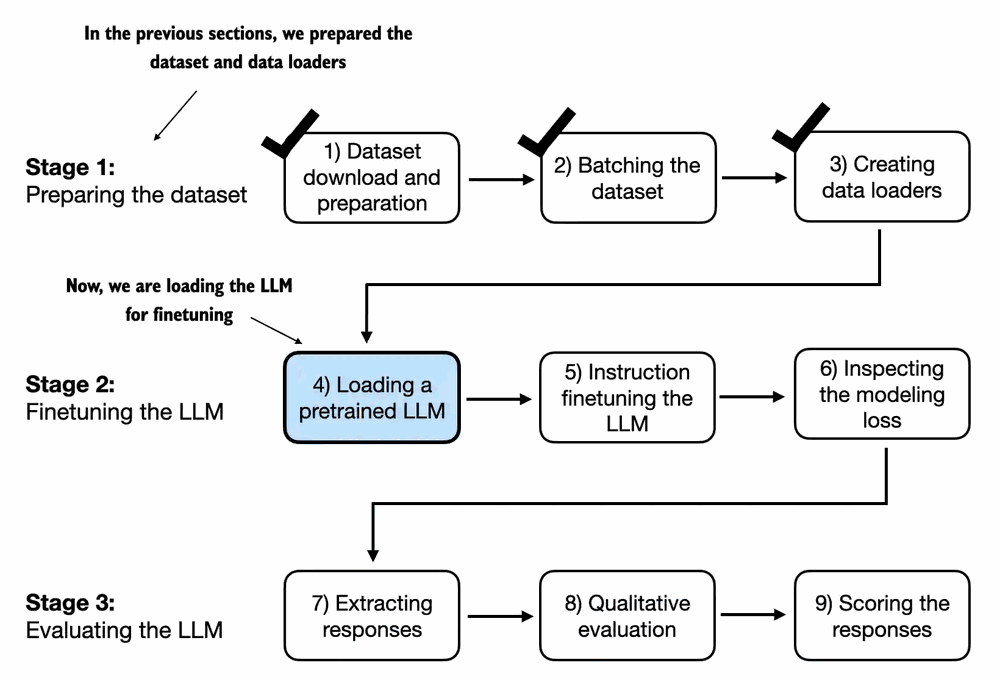

- No entanto, em vez de carregar o menor modelo, de 124 milhões de parâmetros, carregamos a versão média (medium), com 355 milhões de parâmetros, já que o modelo de 124 milhões é pequeno demais para obter resultados qualitativamente razoáveis com instruction finetuning

> 🇧🇷 **O que esta célula faz:** Mostra novamente a GPU usada e o consumo de memória (uma RTX 3060 na execução original).

In [252]:
!nvidia-smi


/bin/bash: /home/pasteurjr/anaconda3/envs/tfcuda11/lib/libtinfo.so.6: no version information available (required by /bin/bash)
Fri Jun 21 23:41:38 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.171.04             Driver Version: 535.171.04   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce RTX 3060        Off | 00000000:01:00.0  On |                  N/A |
|  0%   38C    P8              17W / 170W |   1198MiB / 12288MiB |      9%      Default |
|                              

> 🇧🇷 **O que esta célula faz:** Reaproveita funções das partes anteriores, baixa os pesos oficiais do GPT-2 medium (355M) e os carrega no modelo.

In [253]:
from suporte.gpt_download import download_and_load_gpt2
from suporte.partes_anteriores_p6 import GPTModel, load_weights_into_gpt


BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

CHOOSE_MODEL = "gpt2-medium (355M)"

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(model_size=model_size, models_dir="dados/gpt2")

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

File already exists and is up-to-date: gpt2/355M/checkpoint
File already exists and is up-to-date: gpt2/355M/encoder.json
File already exists and is up-to-date: gpt2/355M/hparams.json
File already exists and is up-to-date: gpt2/355M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/355M/model.ckpt.index
File already exists and is up-to-date: gpt2/355M/model.ckpt.meta
File already exists and is up-to-date: gpt2/355M/vocab.bpe


2024-06-21 23:41:17.211999: W tensorflow/core/framework/cpu_allocator_impl.cc:82] Allocation of 205852672 exceeds 10% of free system memory.


- Antes de começarmos o ajuste fino do modelo na próxima seção, vejamos como ele se sai em uma das tarefas de validação

> 🇧🇷 **O que esta célula faz:** Formata a primeira tarefa de validação, que pede para passar uma frase para a voz passiva.

In [254]:
torch.manual_seed(123)

input_text = format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


> 🇧🇷 **O que esta célula faz:** Usa o modelo ainda sem ajuste fino para gerar uma resposta à tarefa de validação.

In [255]:
from suporte.partes_anteriores_p6 import (
    generate,
    text_to_token_ids,
    token_ids_to_text
)

token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer),
    max_new_tokens=35,
    context_size=BASE_CONFIG["context_length"],
    eos_id=50256,
)
generated_text = token_ids_to_text(token_ids, tokenizer)

- Observe que a função `generate` que usamos nas partes anteriores retorna o texto de entrada e o de saída combinados, o que era conveniente na seção anterior para criar um texto legível
- Para isolar a resposta, podemos subtrair o comprimento da instrução do início do `generated_text`

> 🇧🇷 **O que esta célula faz:** Isola a resposta gerada: o modelo ainda não segue a instrução e apenas repete a frase e a instrução.

In [256]:
response_text = generated_text[len(input_text):].strip()
print(response_text)

### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


- Como podemos ver, o modelo ainda não é capaz de seguir as instruções; ele cria uma seção "Response", mas simplesmente repete a frase de entrada original e a instrução

## 6.6 Fazendo o ajuste fino do LLM com dados de instruções

- Nesta seção, fazemos o ajuste fino (finetuning) do modelo

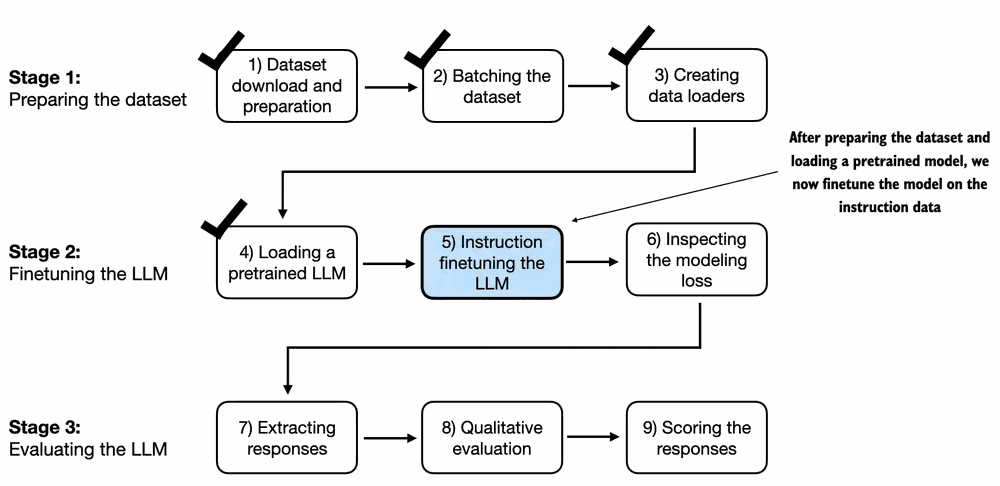

- Observe que podemos reaproveitar todas as funções de cálculo de loss e de treinamento que usamos nas partes anteriores

> 🇧🇷 **O que esta célula faz:** Reaproveita as funções de cálculo de loss e de treino das partes anteriores.

In [257]:
from suporte.partes_anteriores_p6 import (
    calc_loss_loader,
    train_model_simple
)

- Vamos calcular a loss inicial dos conjuntos de treino e de validação antes de começar o treinamento (como nas partes anteriores, o objetivo é minimizar a loss)

> 🇧🇷 **O que esta célula faz:** Calcula a loss inicial antes do ajuste fino: cerca de 3,83 no treino e 3,76 na validação.

In [258]:
model.to(device)

torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 3.8259098529815674
Validation loss: 3.761934232711792


- Observe que o treinamento é um pouco mais custoso do que nas partes anteriores, já que estamos usando um modelo maior (355 milhões em vez de 124 milhões de parâmetros)
- Os tempos de execução em vários dispositivos são mostrados abaixo como referência (rodar este notebook em uma GPU compatível não exige nenhuma alteração no código)

<div style="text-align: left;">
    
| Modelo             | Dispositivo           | Tempo de execução para 2 épocas |
|--------------------|-----------------------|---------------------------------|
| gpt2-medium (355M) | CPU (M3 MacBook Air)  | 15,78 minutos                   |
| gpt2-medium (355M) | GPU (L4)              | 1,83 minutos                    |
| gpt2-medium (355M) | GPU (A100)            | 0,86 minutos                    |
| gpt2-small (124M)  | CPU (M3 MacBook Air)  | 5,74 minutos                    |
| gpt2-small (124M)  | GPU (L4)              | 0,69 minutos                    |
| gpt2-small (124M)  | GPU (A100)            | 0,39 minutos                    |

</div>

- Rodei este notebook usando o modelo `"gpt2-medium (355M)"`

> 🇧🇷 **O que esta célula faz:** Ajusta o GPT-2 medium com as instruções por 2 épocas; a loss de validação cai de 2,6 para cerca de 0,65, em pouco mais de 2 minutos de GPU.

In [259]:
import time

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.1)

num_epochs = 2

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.637, Val loss 2.626
Ep 1 (Step 000005): Train loss 1.174, Val loss 1.102
Ep 1 (Step 000010): Train loss 0.872, Val loss 0.944
Ep 1 (Step 000015): Train loss 0.857, Val loss 0.906
Ep 1 (Step 000020): Train loss 0.776, Val loss 0.881
Ep 1 (Step 000025): Train loss 0.754, Val loss 0.859
Ep 1 (Step 000030): Train loss 0.799, Val loss 0.836
Ep 1 (Step 000035): Train loss 0.714, Val loss 0.808
Ep 1 (Step 000040): Train loss 0.672, Val loss 0.806
Ep 1 (Step 000045): Train loss 0.633, Val loss 0.789
Ep 1 (Step 000050): Train loss 0.663, Val loss 0.783
Ep 1 (Step 000055): Train loss 0.760, Val loss 0.763
Ep 1 (Step 000060): Train loss 0.719, Val loss 0.743
Ep 1 (Step 000065): Train loss 0.653, Val loss 0.735
Ep 1 (Step 000070): Train loss 0.532, Val loss 0.729
Ep 1 (Step 000075): Train loss 0.569, Val loss 0.728
Ep 1 (Step 000080): Train loss 0.605, Val loss 0.725
Ep 1 (Step 000085): Train loss 0.509, Val loss 0.709
Ep 1 (Step 000090): Train loss 0.562, Val loss

- Como podemos ver pelas saídas acima, o modelo treina bem, o que se percebe pelos valores decrescentes da loss de treino e da loss de validação
- Além disso, pelo texto de resposta impresso após cada época, vemos que o modelo segue corretamente a instrução de converter a frase de entrada `'The chef cooks the meal every day.'` para a voz passiva `'The meal is cooked every day by the chef.'` (Vamos formatar e avaliar as respostas adequadamente em uma seção posterior)
- Por fim, vamos dar uma olhada nas curvas de loss de treino e de validação

> 🇧🇷 **O que esta célula faz:** Plota as curvas de loss de treino e validação: queda brusca no início e leve overfitting a partir de cerca de 1 época.

<Figure size 1200x600 with 0 Axes>

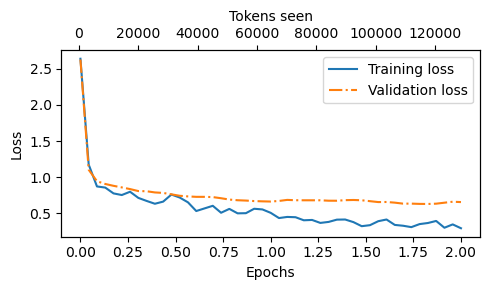

In [260]:
import matplotlib.pyplot as plt
from suporte.partes_anteriores_p6 import plot_losses


plt.figure(figsize=(12, 6))
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

- Como podemos ver, a loss cai bruscamente no início da primeira época, o que significa que o modelo começa a aprender rapidamente
- Podemos ver que um leve overfitting (sobreajuste) começa por volta de 1 época de treinamento

## 6.7 Extraindo e salvando as respostas

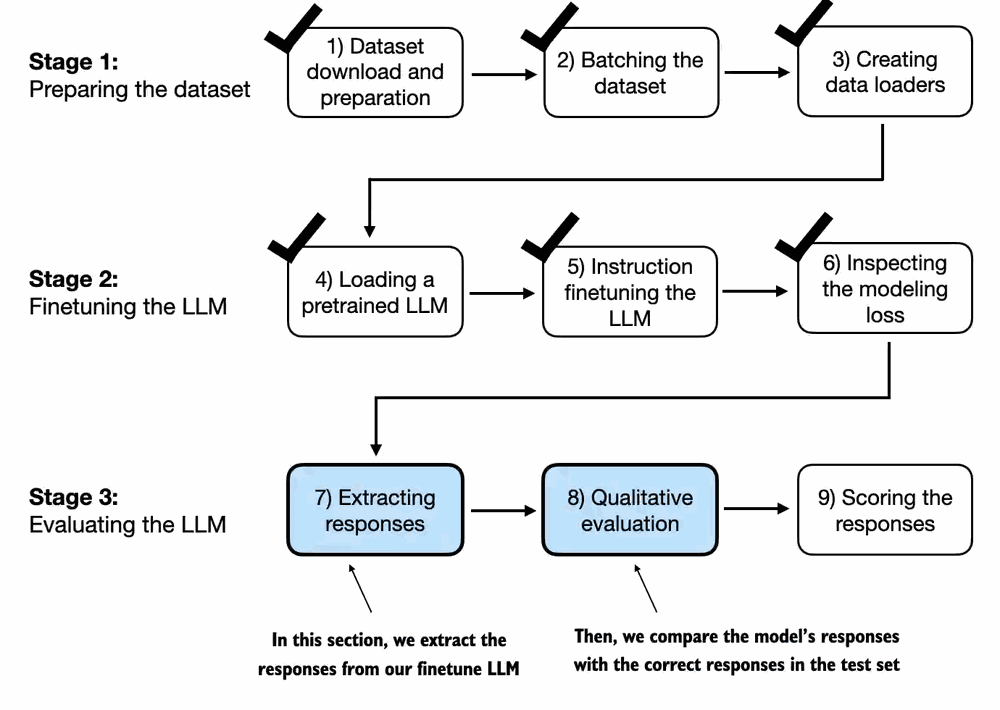

- Nesta seção, salvamos as respostas do conjunto de teste para atribuir notas a elas na próxima seção
- Também salvamos uma cópia do modelo para uso futuro
- Mas, primeiro, vamos dar uma breve olhada nas respostas geradas pelo modelo ajustado

> 🇧🇷 **O que esta célula faz:** Gera respostas para três instruções do conjunto de teste e as compara com as respostas corretas; o modelo acerta bem as tarefas.

In [261]:
torch.manual_seed(123)


for entry in test_data[:3]:

    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = generated_text[len(input_text):].replace("### Response:", "").strip()

    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text.strip()}")
    print("-------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a cheetah.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> The type of cloud associated with thunderstorms is a cumulus cloud.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

Correct response:
>> Jane Austen.

Model response:
>> The author of 'Pride and Pre

- Como podemos ver pelas instruções do conjunto de teste, pelas respostas fornecidas e pelas respostas do modelo, o modelo se sai relativamente bem
- As respostas à primeira e à última instrução estão claramente corretas
- A segunda resposta chega perto; o modelo responde "cumulus cloud" (nuvem cúmulo) em vez de "cumulonimbus" (cumulonimbo) (no entanto, observe que nuvens cúmulo podem se transformar em cumulonimbos, que são capazes de produzir tempestades)
- Mais importante, vemos que a avaliação do modelo não é tão simples quanto na parte anterior, em que bastava calcular a porcentagem de rótulos corretos de spam/não spam para obter a acurácia de classificação
- Na prática, LLMs ajustados com instruções, como os chatbots, são avaliados por meio de várias abordagens
  - benchmarks de respostas curtas e de múltipla escolha, como o MMLU ("Measuring Massive Multitask Language Understanding", [https://arxiv.org/abs/2009.03300](https://arxiv.org/abs/2009.03300)), que testam o conhecimento de um modelo
  - comparação de preferência humana com outros LLMs, como o LMSYS chatbot arena ([https://arena.lmsys.org](https://arena.lmsys.org))
  - benchmarks conversacionais automatizados, em que outro LLM, como o GPT-4, é usado para avaliar as respostas, como o AlpacaEval ([https://tatsu-lab.github.io/alpaca_eval/](https://tatsu-lab.github.io/alpaca_eval/))

- Na próxima seção, usaremos uma abordagem semelhante ao AlpacaEval e empregaremos outro LLM para avaliar as respostas do nosso modelo; no entanto, usaremos nosso próprio conjunto de teste em vez de um dataset de benchmark disponível publicamente
- Para isso, adicionamos a resposta do modelo ao dicionário `test_set` e o salvamos como um arquivo `"instruction-data-with-response.json"` para registro, de modo que possamos carregá-lo e analisá-lo em sessões Python separadas, se necessário

> 🇧🇷 **O que esta célula faz:** Gera as respostas do modelo para as 110 instruções de teste e salva tudo em um arquivo JSON.

In [262]:
from tqdm import tqdm

for i, entry in tqdm(enumerate(test_data), total=len(test_data)):

    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = generated_text[len(input_text):].replace("### Response:", "").strip()

    test_data[i]["model_response"] = response_text


with open("instruction-data-with-response.json", "w") as file:
    json.dump(test_data, file, indent=4)  # "indent" for pretty-printing

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 110/110 [00:55<00:00,  1.99it/s]


- Vamos conferir uma das entradas para ver se as respostas foram adicionadas corretamente ao dicionário `test_set`

> 🇧🇷 **O que esta célula faz:** Exibe uma das entradas do conjunto de teste para conferir o registro com a resposta do modelo.

In [263]:
print(test_data[1])

{'instruction': 'What type of cloud is typically associated with thunderstorms?', 'input': '', 'output': 'The type of cloud typically associated with thunderstorms is cumulonimbus.'}


- Por fim, também salvamos o modelo, caso queiramos reutilizá-lo no futuro

> 🇧🇷 **O que esta célula faz:** Salva os pesos do modelo ajustado em disco para reutilização futura.

In [264]:
import re

model.cpu()
file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL) }-sft.pth"
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

# Load model via
# model.load_state_dict(torch.load("gpt2-medium355M-sft.pth"))

Model saved as gpt2-medium355M-sft.pth


## 6.8 Avaliando o LLM ajustado

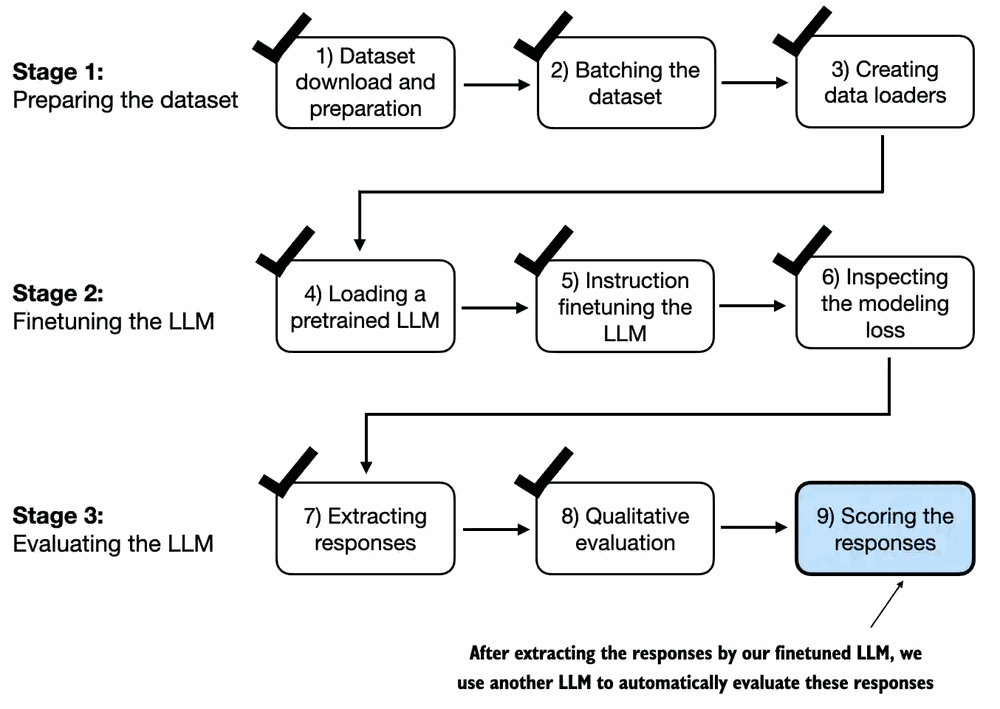

- Nesta seção, automatizamos a avaliação das respostas do LLM ajustado usando outro LLM, maior
- Em particular, usamos um modelo Llama 3 de 8 bilhões de parâmetros, da Meta AI, ajustado com instruções, que pode ser executado localmente via ollama ([https://ollama.com](https://ollama.com))
- (Como alternativa, se você preferir usar um LLM mais capaz, como o GPT-4 da OpenAI, via API do ChatGPT, veja o notebook [../03_model-evaluation/llm-instruction-eval-ollama.ipynb](../03_model-evaluation/llm-instruction-eval-ollama.ipynb))

- O Ollama é um aplicativo para executar LLMs de forma eficiente
- Ele é uma camada sobre o llama.cpp ([https://github.com/ggerganov/llama.cpp](https://github.com/ggerganov/llama.cpp)), que implementa LLMs em C/C++ puro para maximizar a eficiência
- Observe que ele é uma ferramenta para usar LLMs na geração de texto (inferência), e não para treinar ou fazer ajuste fino de LLMs
- Antes de executar o código abaixo, instale o ollama acessando [https://ollama.com](https://ollama.com) e seguindo as instruções (por exemplo, clicando no botão "Download" e baixando o aplicativo ollama para o seu sistema operacional)

- Usuários de macOS e Windows: cliquem no aplicativo ollama que baixaram; se ele perguntar sobre instalar o uso pela linha de comando, respondam "yes" (sim)
- Usuários de Linux podem usar o comando de instalação fornecido no site do ollama

- Em geral, antes de podermos usar o ollama pela linha de comando, precisamos iniciar o aplicativo ollama ou executar `ollama serve` em um terminal separado

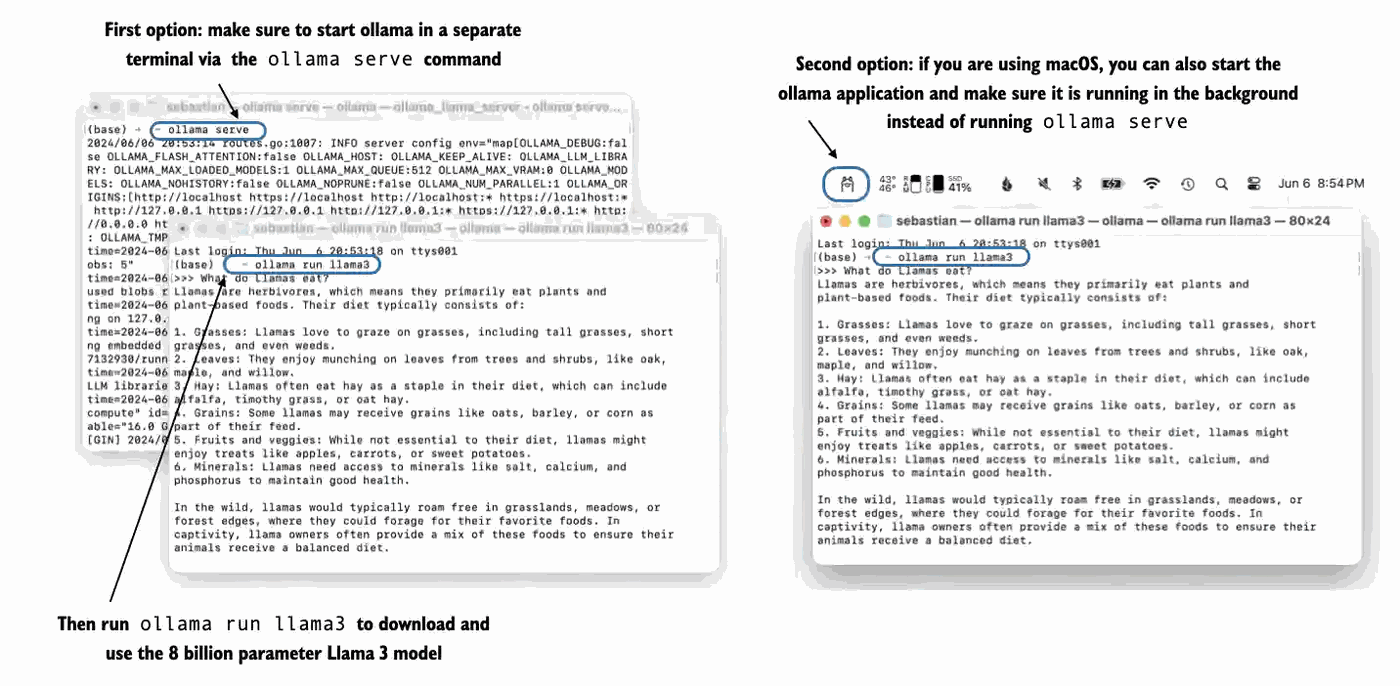


- Com o aplicativo ollama ou o `ollama serve` rodando em outro terminal, execute na linha de comando o comando a seguir para experimentar o modelo Llama 3 de 8 bilhões de parâmetros (o modelo, que ocupa 4,7 GB de espaço em disco, será baixado automaticamente na primeira vez que você executar este comando)

```bash
# 8B model
ollama run llama3
```


A saída fica assim

```
$ ollama run llama3
pulling manifest
pulling 6a0746a1ec1a... 100% ▕████████████████▏ 4.7 GB
pulling 4fa551d4f938... 100% ▕████████████████▏  12 KB
pulling 8ab4849b038c... 100% ▕████████████████▏  254 B
pulling 577073ffcc6c... 100% ▕████████████████▏  110 B
pulling 3f8eb4da87fa... 100% ▕████████████████▏  485 B
verifying sha256 digest
writing manifest
removing any unused layers
success
```

- Observe que `llama3` se refere ao modelo Llama 3 de 8 bilhões ajustado com instruções

-  Usar o ollama com o modelo `"llama3"` (um modelo de 8B parâmetros) exige 16 GB de RAM; se a sua máquina não suportar isso, você pode tentar um modelo menor, como o phi-3, de 3,8B parâmetros, definindo `model = "phi-3"`, que exige apenas 8 GB de RAM

- Como alternativa, você também pode usar o modelo Llama 3 maior, de 70 bilhões de parâmetros, se a sua máquina suportar, substituindo `llama3` por `llama3:70b`

- Depois que o download terminar, você verá um prompt de linha de comando que permite conversar com o modelo

-  Experimente um prompt como "What do llamas eat?" ("O que as lhamas comem?"), que deve retornar uma saída semelhante à seguinte

```
>>> What do llamas eat?
Llamas are ruminant animals, which means they have a four-chambered
stomach and eat plants that are high in fiber. In the wild, llamas
typically feed on:
1. Grasses: They love to graze on various types of grasses, including tall
grasses, wheat, oats, and barley.
```

- Você pode encerrar esta sessão digitando `/bye`

- O código a seguir verifica se a sessão do ollama está rodando corretamente antes de prosseguirmos com o uso do ollama para avaliar as respostas do conjunto de teste que geramos na seção anterior

> 🇧🇷 **O que esta célula faz:** Opcional: requer Ollama rodando localmente; não funciona no Colab. Verifica se o processo do Ollama está em execução antes de prosseguir.

In [265]:
import psutil

def check_if_running(process_name):
    running = False
    for proc in psutil.process_iter(["name"]):
        if process_name in proc.info["name"]:
            running = True
            break
    return running

ollama_running = check_if_running("ollama")

if not ollama_running:
    raise RuntimeError("Ollama not running. Launch ollama before proceeding.")
print("Ollama running:", check_if_running("ollama"))

Ollama running: True


> 🇧🇷 **O que esta célula faz:** Opcional: recarrega as respostas salvas e a função de formatação, permitindo rodar a avaliação sem refazer o treino.

In [266]:
# This cell is optional; it allows you to restart the notebook
# and only run section 7.7 without rerunning any of the previous code
import json
from tqdm import tqdm

file_path = "instruction-data-with-response.json"

with open(file_path, "r") as file:
    test_data = json.load(file)


def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text

- Agora, uma alternativa ao comando `ollama run` que usamos antes para interagir com o modelo é usar sua API REST em Python, por meio da função a seguir
- Antes de executar as próximas células deste notebook, certifique-se de que o ollama ainda está rodando (as células de código anteriores devem imprimir `"Ollama running: True"`)
- Em seguida, execute a célula de código abaixo para consultar o modelo

> 🇧🇷 **O que esta célula faz:** Opcional: requer Ollama rodando localmente; não funciona no Colab. Define uma função que consulta o Llama 3 pela API do Ollama e testa com a pergunta sobre o que as lhamas comem.

In [267]:
import urllib.request

def query_model(prompt, model="llama3", url="http://localhost:11434/api/chat"):
    # Create the data payload as a dictionary
    data = {
        "model": model,
        "seed": 123,        # for deterministic responses
        "temperature": 0,   # for deterministic responses
        "messages": [
            {"role": "user", "content": prompt}
        ]
    }

    # Convert the dictionary to a JSON formatted string and encode it to bytes
    payload = json.dumps(data).encode("utf-8")

    # Create a request object, setting the method to POST and adding necessary headers
    request = urllib.request.Request(url, data=payload, method="POST")
    request.add_header("Content-Type", "application/json")

    # Send the request and capture the response
    response_data = ""
    with urllib.request.urlopen(request) as response:
        # Read and decode the response
        while True:
            line = response.readline().decode("utf-8")
            if not line:
                break
            response_json = json.loads(line)
            response_data += response_json["message"]["content"]

    return response_data


model = "llama3"
result = query_model("What do Llamas eat?", model)
print(result)

Llamas are ruminant animals, which means they have a four-chambered stomach that allows them to digest plant-based foods. In the wild, llamas are browsers, which means they primarily eat plants that grow above ground, such as:

1. Grasses: Llamas will eat various types of grasses, including tallgrass, bunchgrass, and shortgrass.
2. Leaves: They enjoy leaves from trees and shrubs, including willow, cottonwood, and juniper.
3. Fruits: Llamas like to munch on fruits, such as apples, berries, and mesquite pods.
4. Bark: In the winter or when other food sources are scarce, llamas may eat the bark of trees, particularly willow and cottonwood.
5. Hay: Domesticated llamas are often fed hay, which is a mix of dried grasses and legumes.

In their natural habitat, llamas also eat:

1. Cacti: Some species of cacti are edible to llamas.
2. Mushrooms: Llamas will eat certain types of mushrooms that grow in their environment.
3. Weeds: They may consume various weeds, including those that contain toxi

- Agora, usando a função `query_model` que definimos acima, podemos avaliar as respostas do nosso modelo ajustado; vamos testá-la com as 3 primeiras respostas do conjunto de teste que vimos em uma seção anterior

> 🇧🇷 **O que esta célula faz:** Opcional: requer Ollama rodando localmente; não funciona no Colab. Pede ao Llama 3 para dar uma nota de 0 a 100 às três primeiras respostas do modelo, com justificativas detalhadas.

In [268]:
for entry in test_data[:3]:
    prompt = (
        f"Given the input `{format_input(entry)}` "
        f"and correct output `{entry['output']}`, "
        f"score the model response `{entry['model_response']}`"
        f" on a scale from 0 to 100, where 100 is the best score. "
    )
    print("\nDataset response:")
    print(">>", entry['output'])
    print("\nModel response:")
    print(">>", entry["model_response"])
    print("\nScore:")
    print(">>", query_model(prompt))
    print("\n-------------------------")


Dataset response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a cheetah.

Score:
>> To score the model response "The car is as fast as a cheetah.", I will compare it to the correct output "The car is as fast as lightning."

Here's my evaluation:

* The model response uses a simile, which is the correct technique for rewriting the sentence.
* The comparison is between two entities that are both known for their speed, making it a relevant and intuitive analogy.
* However, using a cheetah instead of lightning may not be as vivid or attention-grabbing, since lightning is often associated with extraordinary speed.

Based on these factors, I would score the model response 80 out of 100. The response is mostly correct, but could be improved by choosing a more dramatic or unexpected comparison that still conveys the same idea.

-------------------------

Dataset response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model res

- Como podemos ver, o modelo Llama 3 fornece uma avaliação razoável e também dá pontuação parcial quando uma resposta não está totalmente correta, como vemos no caso da resposta "cumulus cloud"
- Observe que o prompt anterior retorna avaliações muito prolixas; podemos ajustar o prompt para gerar respostas com números inteiros entre 0 e 100 (em que 100 é o melhor) e assim calcular uma nota média para o nosso modelo
- A avaliação das 110 entradas do conjunto de teste leva cerca de 1 minuto em um notebook M3 MacBook Air

> 🇧🇷 **O que esta célula faz:** Opcional: requer Ollama rodando localmente; não funciona no Colab. Pede ao Llama 3 apenas a nota numérica de cada uma das 110 respostas de teste; a nota média do modelo é 51,28.

In [269]:
def generate_model_scores(json_data, json_key):
    scores = []
    for entry in tqdm(json_data, desc="Scoring entries"):
        prompt = (
            f"Given the input `{format_input(entry)}` "
            f"and correct output `{entry['output']}`, "
            f"score the model response `{entry[json_key]}`"
            f" on a scale from 0 to 100, where 100 is the best score. "
            f"Respond with the integer number only."
        )
        score = query_model(prompt)
        try:
            scores.append(int(score))
        except ValueError:
            print(f"Could not convert score: {score}")
            continue

    return scores


scores = generate_model_scores(test_data, "model_response")
print(f"Number of scores: {len(scores)} of {len(test_data)}")
print(f"Average score: {sum(scores)/len(scores):.2f}\n")

Scoring entries: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 110/110 [01:14<00:00,  1.47it/s]

Number of scores: 110 of 110
Average score: 51.28



- Nosso modelo atinge uma nota média acima de 50, que podemos usar como ponto de referência para comparar o modelo com outros modelos ou para testar outras configurações de treinamento que possam melhorá-lo
- Observe que o ollama não é totalmente determinístico (no momento em que escrevo), então os números que você obtiver podem diferir ligeiramente dos mostrados acima

- Para referência, os modelos originais
  - Llama 3 8B base atinge uma nota de 58,51
  - Llama 3 8B instruct atinge uma nota de 82,65

## 6.9 Conclusões

### 6.9.1 Próximos passos

- Esta é a última parte deste notebook
- Cobrimos as principais etapas do ciclo de desenvolvimento de um LLM: implementar a arquitetura de um LLM, pré-treinar um LLM e fazer seu ajuste fino

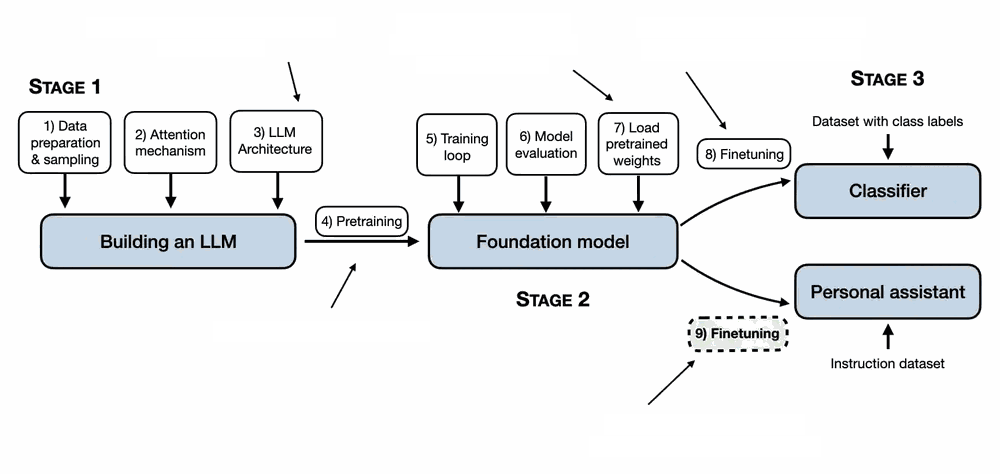

- Uma etapa opcional que às vezes é realizada depois do instruction finetuning, como descrito nesta parte, é o ajuste fino por preferências (preference finetuning)
- O processo de preference finetuning pode ser particularmente útil para personalizar um modelo de modo que ele se alinhe melhor a preferências específicas dos usuários; veja a pasta [../04_preference-tuning-with-dpo](../04_preference-tuning-with-dpo) se tiver interesse nisso

- Este repositório do GitHub também contém uma grande seleção de material bônus adicional de que você pode gostar; para mais informações, veja a seção [Bonus Material](https://github.com/rasbt/LLMs-from-scratch?tab=readme-ov-file#bonus-material) na página README deste repositório

### 6.9.2 Mantendo-se atualizado em uma área que avança rápido

- Não há código nesta seção

### 6.9.3 Palavras finais

- Espero que você tenha gostado desta jornada de implementar um LLM desde o início e de programar as funções de pré-treinamento e de ajuste fino
- Na minha opinião, implementar um LLM do zero é a melhor maneira de entender como os LLMs funcionam; espero que você tenha adquirido uma compreensão melhor por meio dessa abordagem
- Embora este notebook tenha fins educacionais, você pode se interessar em usar LLMs diferentes e mais poderosos em aplicações do mundo real
  - Para isso, você pode considerar ferramentas populares como o axolotl ([https://github.com/OpenAccess-AI-Collective/axolotl](https://github.com/OpenAccess-AI-Collective/axolotl)) ou o LitGPT ([https://github.com/Lightning-AI/litgpt](https://github.com/Lightning-AI/litgpt), que eu ajudo a desenvolver)

## Resumo

- Não há código nesta seção

# Encerramento

Ao longo deste notebook construímos um LLM completo, passo a passo:

1. transformamos texto em tokens e embeddings;
2. implementamos o mecanismo de atenção;
3. montamos a arquitetura GPT;
4. pré-treinamos o modelo e carregamos os pesos oficiais do GPT-2;
5. ajustamos o modelo para classificar spam;
6. ajustamos o modelo para seguir instruções e o avaliamos com outro LLM.

Esse é o mesmo ciclo usado, em escala muito maior, para criar modelos como o ChatGPT.

---
<small>Créditos: o código deste notebook é baseado no repositório
[LLMs-from-scratch](https://github.com/rasbt/LLMs-from-scratch), de Sebastian Raschka, distribuído sob a licença Apache 2.0.</small>